# Homework 03: Learning Curves and Training Workflow

#### Due Date: Sunday, September 20th at 11:59pm (with 2 hour plus 1 minute grace period)

#### The late policy is described in the DX 703 Syllabus. 

In this assignment, you will learn how to design, train, and evaluate neural networks by systematically exploring key design choices. Your focus will be on developing an effective **training workflow** — using learning curves and validation metrics to guide your decisions.

We'll again use the **Forest Cover Type (Covertype) dataset,** which has ~581k tabular records with 54 cartographic/topographic features (elevation, aspect, slope, soil and wilderness indicators) used to predict one of seven tree cover types in Colorado’s Roosevelt National Forest. 

We will start with a **baseline model** (two hidden layers of sizes 64 and 32), and gradually introduce and tune different hyperparameters. Each of the first five problems considers  different hyperparameter choices, and the last problem is your chance to use what you have learned to design your best model:

1. **Activation function** – Compare ReLU, sigmoid, and tanh to see which provides the best accuracy.
2. **Learning rate** – Explore a range of learning rates and identify which balances convergence speed and stability.
3. **Dropout** – Investigate how different dropout rates reduce overfitting and where they are most effective.
4. **L2 regularization** – Experiment with weight penalties to encourage simpler models and avoid memorization.
5. **Dropout + L2** – Combine both regularization techniques and study their interaction.
6. **Best model design** – Use all your insights to build and train your strongest model, with the option to try **learning rate scheduling** for further improvement.

In this homework, you will use **early stopping** to select the "best" model at the epoch of **minimum validation loss**, and you will report the **validation accuracy** of that selected model as the primary measure of performance. Test accuracy is reported for reference but is not used for model selection.

> **Note:** Throughout this homework, best always refers to the model selected by early stopping at the epoch of minimum validation loss. Do not report metrics from the final training epoch unless explicitly instructed.

By the end of this homework, you will not only understand how different hyperparameters affect training and generalization, but also gain hands-on practice in building a disciplined workflow for model development.

There are 10 graded problems, worth 8 points each, with 5 points for free if you complete the homework. 

In [1]:
# Useful imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import time
import os

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input,Dropout
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers.schedules import ExponentialDecay


from tensorflow.keras.datasets import fashion_mnist

# utility code

random_seed = 42

def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppresses INFO and WARNING messages


In [2]:
# Utility function to plot learning curves and keep track of all results

# Call `print_results()` to see listing of all results logged so far


def plot_learning_curves(hist, title, verbose=True):
    
    val_losses = hist.history['val_loss']
    min_val_loss = min(val_losses)
    min_val_epoch = val_losses.index(min_val_loss)
    val_acc_at_min_loss = hist.history['val_accuracy'][min_val_epoch]

    epochs = range(1, len(val_losses) + 1)  # epoch numbers starting at 1

    fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    # --- Loss Plot ---
    axs[0].plot(epochs, hist.history['loss'], label='train loss')
    axs[0].plot(epochs, hist.history['val_loss'], label='val loss')
    axs[0].scatter(min_val_epoch + 1, min_val_loss, color='red', marker='x', s=50, label='min val loss')
    axs[0].set_title(f'{title} - Categorical Cross-Entropy Loss')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # --- Accuracy Plot ---
    axs[1].plot(epochs, hist.history['accuracy'], label='train acc')
    axs[1].plot(epochs, hist.history['val_accuracy'], label='val acc')
    axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss, color='red', marker='x', s=50, label='acc @ min val loss')
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

    if verbose:
        print(f"Final Training Loss:            {hist.history['loss'][-1]:.4f}")
        print(f"Final Training Accuracy:        {hist.history['accuracy'][-1]:.4f}")
        print(f"Final Validation Loss:          {hist.history['val_loss'][-1]:.4f}")
        print(f"Final Validation Accuracy:      {hist.history['val_accuracy'][-1]:.4f}")
        print(f"Minimum Validation Loss:        {min_val_loss:.4f} (Epoch {min_val_epoch + 1})")
        print(f"Validation Accuracy @ Min Loss: {val_acc_at_min_loss:.4f}")

    results[title] = (val_acc_at_min_loss,min_val_epoch + 1)

results = {}

**The plotting function will record the validation accuracy for each experiment, using the plot title as key. The next function will print these out (see the last cell in the notebook).**


In order to see all results, you must give a different plot title to each experiment.

In [3]:
def print_results():
    for title, (acc, ep) in sorted(results.items(), 
                                   key=lambda kv: kv[1][0],   # kv[1] is (acc, epoch); [0] is acc
                                   reverse=True
                                  ):
        print(f"{title:<40}\t{acc:.4f}")

### Wrapper to train, display results, and run test set

We assume multi-class classification, and allow setting various parameters for training. 

In [4]:
# Uses globals X_train,y_train,X_val,y_val

def train_and_test(model, 
                   epochs        = 500,                   # Just needs to be bigger than early stop point
                   lr_schedule   = 0.001,                 # Adam default / 10 seems to work well for this dataset
                   optimizer     = "Adam",
                   title         = "Learning Curves",
                   batch_size    = 64,                     # experiments confirmed this was optimal with other parameters at default
                   use_early_stopping = True,
                   patience      = 10,                                       
                   min_delta     = 0.0001,                 
                   callbacks     = [],                     # for extra callbacks other than early stopping
                   verbose       = 0,
                   return_history = False
                  ):

    print(f"\n{title}\n")


    if optimizer == "Adam":
        opt = Adam(learning_rate=lr_schedule) 
    else:
        opt = optimizer
    
    #Compiling the model
    model.compile(optimizer=opt, 
                  loss="sparse_categorical_crossentropy", 
                  metrics=["accuracy"]
                 )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        min_delta=min_delta,
        restore_best_weights=True,               # this will mean that the model which produced the smallest validation loss will be returned
        verbose=verbose
    )
    

    if use_early_stopping:
        cbs=[early_stop] + callbacks
    else:
        cbs=callbacks

    # start timer
    start = time.time()
    
    # Fit the model with early stopping
    history = model.fit(X_train, y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(X_val, y_val),       # must use stratified validation set
                        callbacks=cbs,
                        verbose=verbose
                       )

    if use_early_stopping:
        best_epoch = early_stop.best_epoch
        best_acc   = history.history['val_accuracy'][best_epoch]
    else:
        best_epoch = np.argmax(history.history['val_accuracy'])
        best_acc   = history.history['val_accuracy'][best_epoch]
    
    # Plot training history
    plot_learning_curves(history, title=title)

    # Evaluate on test data
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    
    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")

    print(f"\nValidation-Test Gap (accuracy): {abs(best_acc - test_accuracy):.6f}")
    
    # Record end time and print execution time
    end = time.time()
    print(f"\nExecution Time: " + format_hms(end-start))

    if return_history:
        return history

### Load the dataset and extract a stratified subset

This data set is rather large (581,012 samples) and unbalanced, but for the purposes of this homework, we use a much smaller set, and select samples so that it is balanced. 

In [5]:
# complete cell: load, balance, split into X_train/y_train/x_val/y_val/X_test/y_test, and standardize
from collections import Counter
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1) load
x, y = fetch_covtype(return_X_y=True)  # y in {1..7}
print("full dataset shape:", x.shape)

# 2) build a perfectly balanced subset across 7 classes (no replacement)
classes, counts = np.unique(y, return_counts=True)
# min_count = counts.min()  # size of rarest class                         # You can modify this parameter to increase the size of the dataset, but above
min_count = 1000                                                           # counts.min() you'll produce an unbalanced set. 


rng = np.random.default_rng(42)

idx_list = []
for c in classes:
    c_idx = np.where(y == c)[0]
    chosen = rng.choice(c_idx, size=min_count, replace=False)
    idx_list.append(chosen)

idx_bal = np.concatenate(idx_list)
rng.shuffle(idx_bal)

X_sub = x[idx_bal]
y_sub = y[idx_bal] - 1  # relabel to {0..6} for keras
print("balanced subset shape:", X_sub.shape, "class counts:", dict(Counter(y_sub)))

# 3) stratified 60/20/20 split (train/val/test)
test_size = 0.20
val_size = 0.20  # of the whole dataset

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_sub, y_sub, test_size=test_size, random_state=random_seed, stratify=y_sub
)
val_size_rel = val_size / (1.0 - test_size)  # e.g., 0.20 / 0.80 = 0.25

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=val_size_rel, random_state=random_seed, stratify=y_trainval
)

# 4) standardize using train-only stats (float32 for tensorflow friendliness)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

# 5) quick sanity checks
def show_counts(name, y_arr):
    c = Counter(y_arr)
    total = sum(c.values())
    print(f"{name}: total={total}, per-class={dict(c)}")

print("shapes:", "X_train", X_train.shape, "X_val", X_val.shape, "X_test", X_test.shape)
show_counts("train", y_train)
show_counts("val  ", y_val)
show_counts("test ", y_test)

# you now have: X_train, y_train, X_val, y_val, X_test, y_test

# Looks like integer encoded multi-class, let's check and define the global n_classes

labels = np.unique(y_train)

n_classes = len(labels)

print("class labels:",labels)


full dataset shape: (581012, 54)
balanced subset shape: (7000, 54) class counts: {2: 1000, 0: 1000, 4: 1000, 5: 1000, 1: 1000, 3: 1000, 6: 1000}
shapes: X_train (4200, 54) X_val (1400, 54) X_test (1400, 54)
train: total=4200, per-class={2: 600, 1: 600, 0: 600, 3: 600, 5: 600, 4: 600, 6: 600}
val  : total=1400, per-class={1: 200, 6: 200, 5: 200, 4: 200, 3: 200, 2: 200, 0: 200}
test : total=1400, per-class={0: 200, 6: 200, 2: 200, 3: 200, 4: 200, 5: 200, 1: 200}
class labels: [0 1 2 3 4 5 6]


## Prelude: Defining a model builder

In order to facilitate our experimentation, we'll write a function which builds models according to specifications:

- How many layers
- How wide each layer is
- How much dropout in each layer
- How much L2 Regularization in each layer

This is a fairly standard practice in ML, since the structure of simple models is fairly predictable and can be specified by a few hyperparameters. 

In [6]:
# This function will build a multi-class classifier with dropout and L2 regularization.
# You must specify the number of input features, the number of classes, and a list of layer hyperparameters
# in the form  [ ...., (width, activation function, L2 lambda, dropout rate), .... ]

# Note that when adding dropout, this appears as a separate layer, but it has no parameters to be trained. 

def build_model(n_inputs,layer_list,n_classes):
    layers = [ Input(shape=(n_inputs,)) ]
    for (width,act,l2_lambda,dropout_rate) in layer_list:
        layers.append( Dense(width, activation=act, kernel_regularizer=regularizers.l2(l2_lambda)) )
        if dropout_rate > 0:
            layers.append( Dropout(dropout_rate) )
    layers.append( Dense(n_classes, activation='softmax') )
    return models.Sequential( layers )


**Example: To build the following model:**

In [7]:
model = models.Sequential(
   [
    Input(shape=(X_train.shape[1],)),                              
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.0)),              # 0.0 means no regularization applied; no dropout, so no Dropout layer necessary
    Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.3),
    Dense(n_classes, activation='softmax')
   ]
)

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                3520      
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 7)                 231       
                                                                 
Total params: 5831 (22.78 KB)
Trainable params: 5831 (22.78 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


**We call `build_model` as shown here:**

In [8]:
build_model(X_train.shape[1], [ (64,'relu',0.0,0.0), (32,'relu',0.001,0.3)], n_classes).summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 64)                3520      
                                                                 
 dense_4 (Dense)             (None, 32)                2080      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_5 (Dense)             (None, 7)                 231       
                                                                 
Total params: 5831 (22.78 KB)
Trainable params: 5831 (22.78 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


-------------------



### Baseline Model Architecture

**Problems 1–5 will use the following baseline model structure,** implemented with the provided `build_model` function and trained using `train_and_test`:

```
input → 64 → 32 → output
```

* Two hidden layers of widths 64 and 32.
* Activation function, dropout rate, and L2 regularization term (λ) will vary as specified in each problem.
* **Early stopping** is always applied to select the model at the epoch of **minimum validation loss**.
* We will report the **validation accuracy** of the selected model as the primary metric.


### Problem One: Which Activation Function?

In this problem, you will train the **baseline neural network** and investigate which activation function produces the best performance. The model you create will be the one saved by **early stopping** — that is, the epoch where validation loss is minimized.

**Steps to follow:**

* Use the provided functions `train_and_test` and `build_model` to create a model named **`model_baseline`**.
* Train and evaluate this model using each of the following activation functions in the hidden layers:

  * `relu`
  * `sigmoid`
  * `tanh`
* Identify which activation function produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.



Relu Baseline





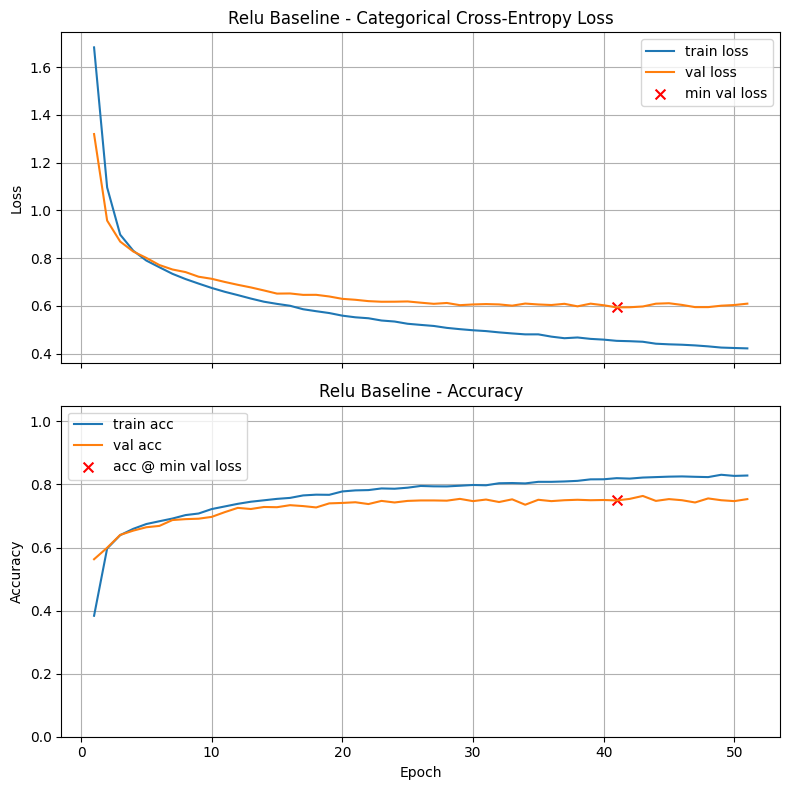

Final Training Loss:            0.4226
Final Training Accuracy:        0.8283
Final Validation Loss:          0.6098
Final Validation Accuracy:      0.7536
Minimum Validation Loss:        0.5942 (Epoch 41)
Validation Accuracy @ Min Loss: 0.7493

Test Loss: 0.6138
Test Accuracy: 0.7471

Validation-Test Gap (accuracy): 0.002143

Execution Time: 00:00:06

Sigmoid Baseline



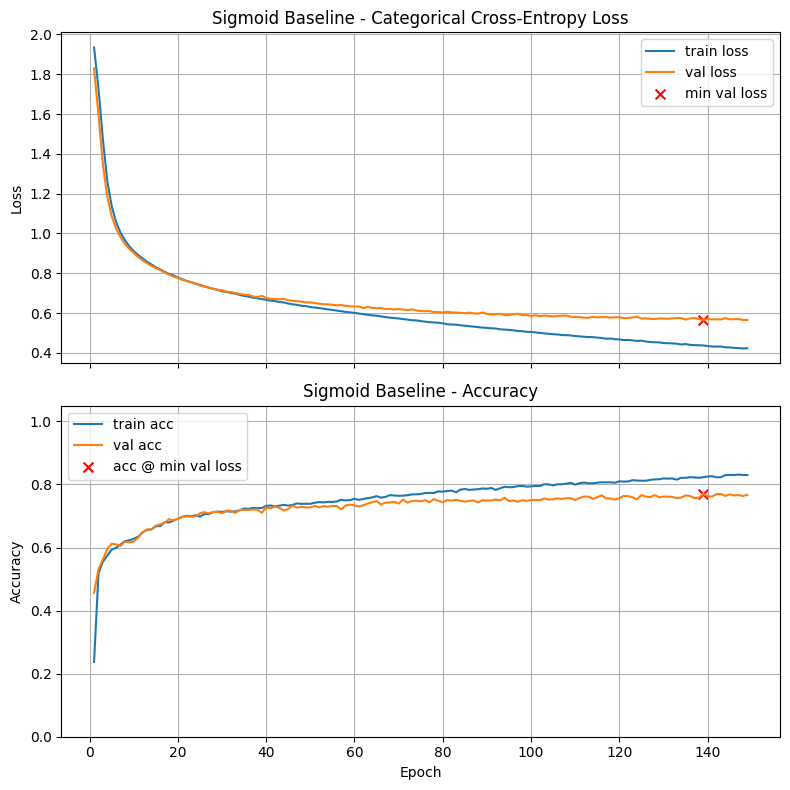

Final Training Loss:            0.4232
Final Training Accuracy:        0.8298
Final Validation Loss:          0.5655
Final Validation Accuracy:      0.7671
Minimum Validation Loss:        0.5642 (Epoch 139)
Validation Accuracy @ Min Loss: 0.7700

Test Loss: 0.5805
Test Accuracy: 0.7614

Validation-Test Gap (accuracy): 0.008571

Execution Time: 00:00:17

Tanh Baseline



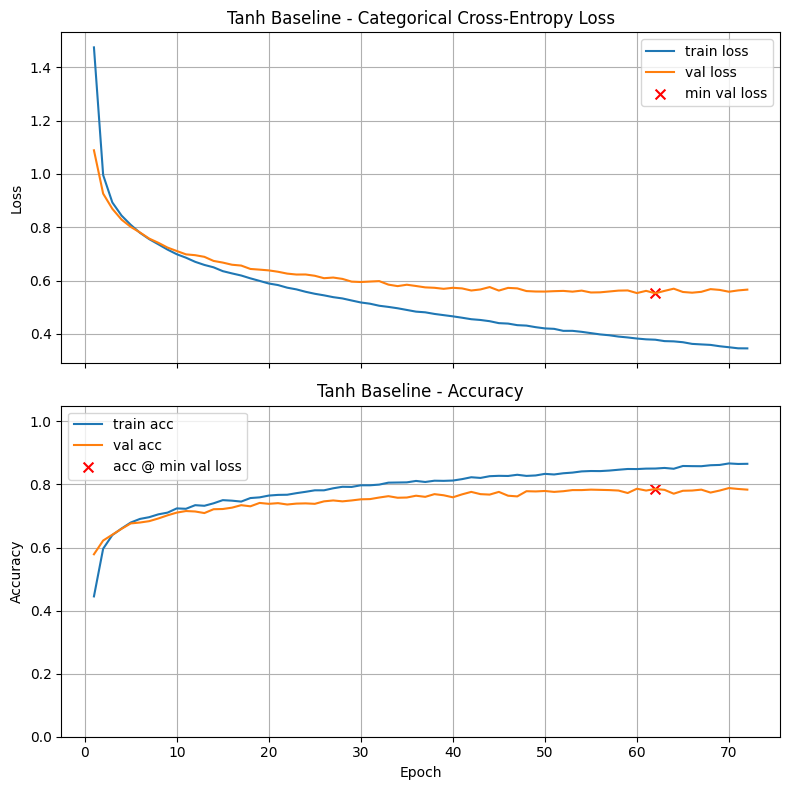

Final Training Loss:            0.3456
Final Training Accuracy:        0.8655
Final Validation Loss:          0.5660
Final Validation Accuracy:      0.7836
Minimum Validation Loss:        0.5522 (Epoch 62)
Validation Accuracy @ Min Loss: 0.7857

Test Loss: 0.5701
Test Accuracy: 0.7629

Validation-Test Gap (accuracy): 0.022857

Execution Time: 00:00:08


In [9]:
relu_model_baseline = train_and_test(model=build_model(X_train.shape[1], [ (64, 'relu', 0, 0), (32, 'relu', 0, 0)], n_classes),
               epochs=500,
               lr_schedule=0.001,
               optimizer='Adam',
               batch_size=64,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title='Relu Baseline')

sigmoid_model_baseline = train_and_test(model=build_model(X_train.shape[1], [ (64, 'sigmoid', 0, 0), (32, 'sigmoid', 0, 0)], n_classes),
               epochs=500,
               lr_schedule=0.001,
               optimizer='Adam',
               batch_size=64,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title='Sigmoid Baseline')

tanh_model_baseline = train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 0, 0), (32, 'tanh', 0, 0)], n_classes),
               epochs=500,
               lr_schedule=0.001,
               optimizer='Adam',
               batch_size=64,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title='Tanh Baseline')

In [10]:
results

{'Relu Baseline': (0.7492856979370117, 41),
 'Sigmoid Baseline': (0.7699999809265137, 139),
 'Tanh Baseline': (0.7857142686843872, 62)}

### Graded Questions

In [11]:
# Set a1a to the activation function which provided the best validation accuracy at the epoch of minimum validation loss

a1a = 2             # Replace with integer 0 (relu), 1 (sigmoid), or 2 (tanh)

In [12]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1a = {a1a}') 


a1a = 2


In [13]:
# Set a1b to the validation accuracy found by this best activation function

a1b = results['Tanh Baseline'][0]             # Replace 0.0 with your answer

In [14]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1b = {a1b:.4f}') 

a1b = 0.7857


### Problem Two: Finding the Right Learning Rate

In this problem, you will continue working with the **baseline model** and determine which learning rate produces the best performance. As before, the model you evaluate should be the one saved by **early stopping** — the epoch where validation loss is minimized.

**Steps to follow:**

* Build and train the **baseline model** using the **activation function identified in Problem One**.

* Train and evaluate this model using each of the following learning rates:

  ```
      [1e-3, 5e-4, 1e-4, 5e-5, 1e-5]
  ```

* Identify which learning rate produces the **best validation accuracy** at the epoch of **minimum validation loss**, within a maximum of **500 epochs**.

* Answer the graded questions.


**Note: Smaller learning rates will generally take more epochs to reach the optimal point, so some of these will not engage early stopping, but run the full 500 epochs.**



Tanh LR = 1e-3



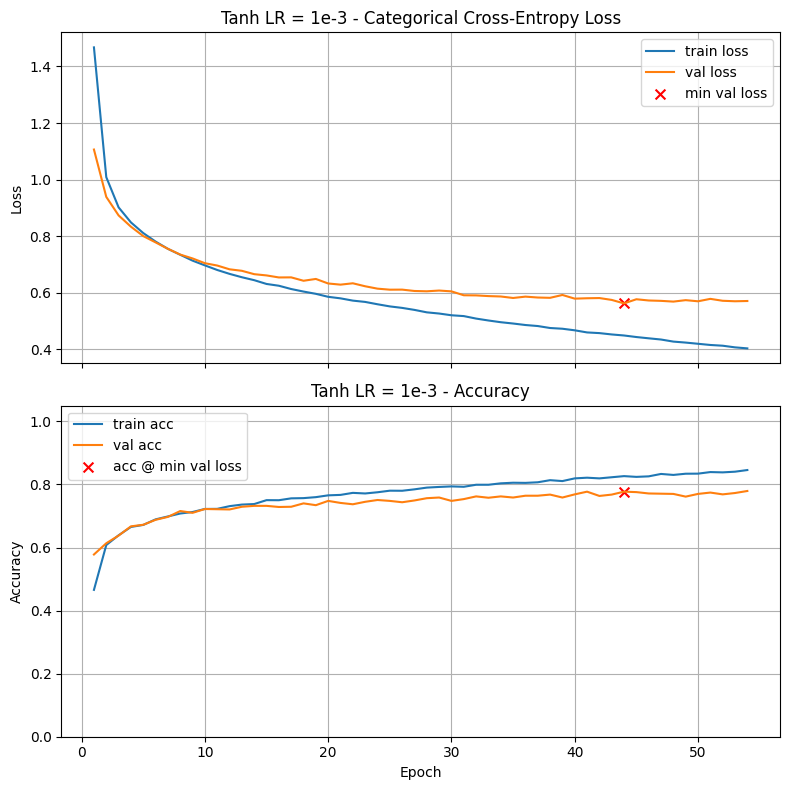

Final Training Loss:            0.4038
Final Training Accuracy:        0.8457
Final Validation Loss:          0.5712
Final Validation Accuracy:      0.7793
Minimum Validation Loss:        0.5627 (Epoch 44)
Validation Accuracy @ Min Loss: 0.7771

Test Loss: 0.5785
Test Accuracy: 0.7629

Validation-Test Gap (accuracy): 0.014286

Execution Time: 00:00:06

Tanh LR = 5e-4



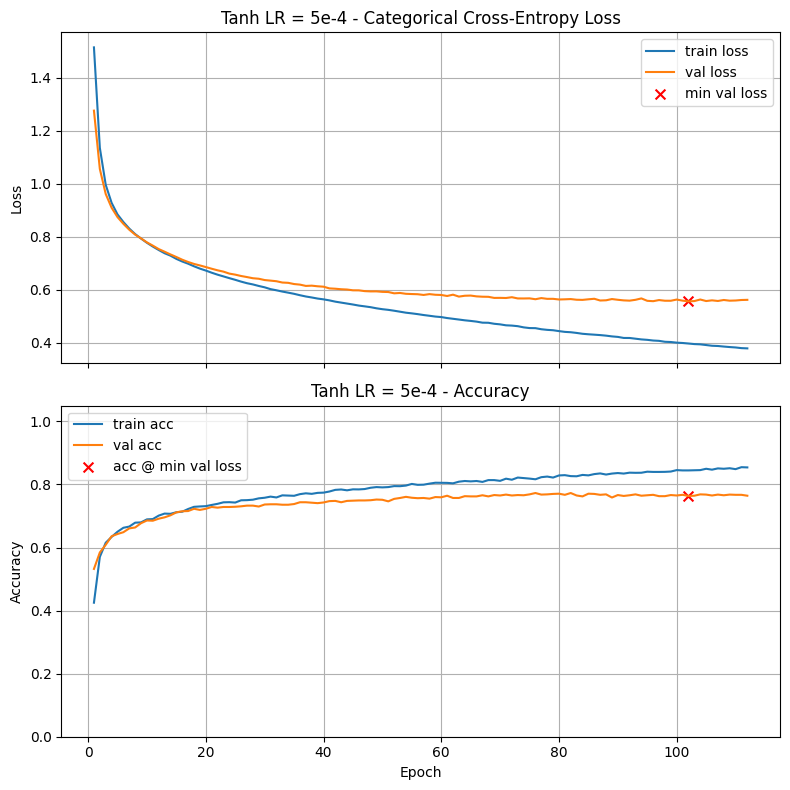

Final Training Loss:            0.3787
Final Training Accuracy:        0.8540
Final Validation Loss:          0.5617
Final Validation Accuracy:      0.7643
Minimum Validation Loss:        0.5560 (Epoch 102)
Validation Accuracy @ Min Loss: 0.7636

Test Loss: 0.5755
Test Accuracy: 0.7757

Validation-Test Gap (accuracy): 0.012143

Execution Time: 00:00:12

Tanh LR = 1e-4



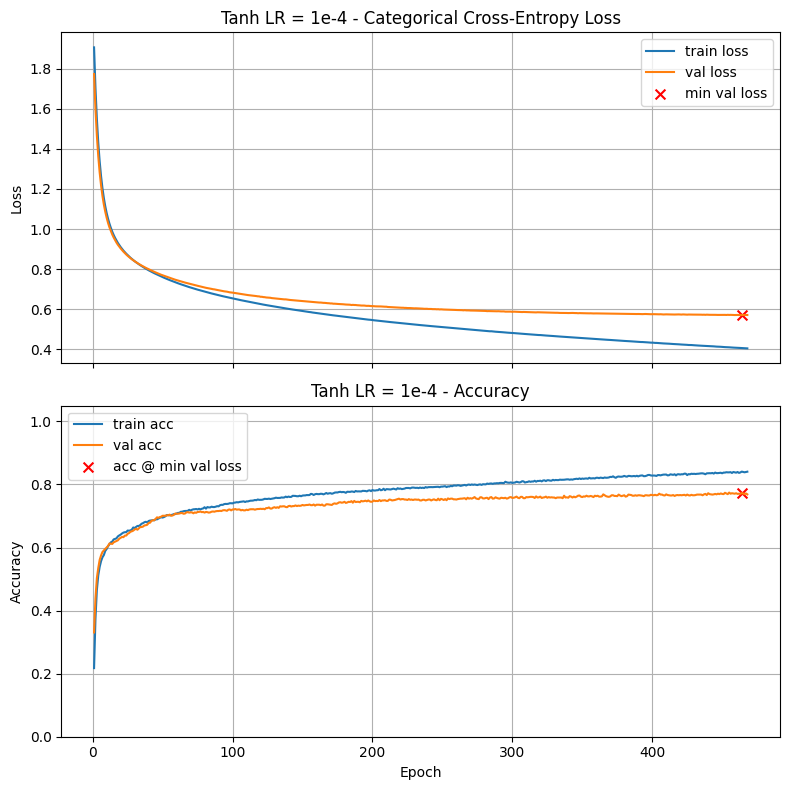

Final Training Loss:            0.4041
Final Training Accuracy:        0.8405
Final Validation Loss:          0.5707
Final Validation Accuracy:      0.7686
Minimum Validation Loss:        0.5704 (Epoch 464)
Validation Accuracy @ Min Loss: 0.7729

Test Loss: 0.5813
Test Accuracy: 0.7643

Validation-Test Gap (accuracy): 0.007143

Execution Time: 00:00:49

Tanh LR = 5e-5



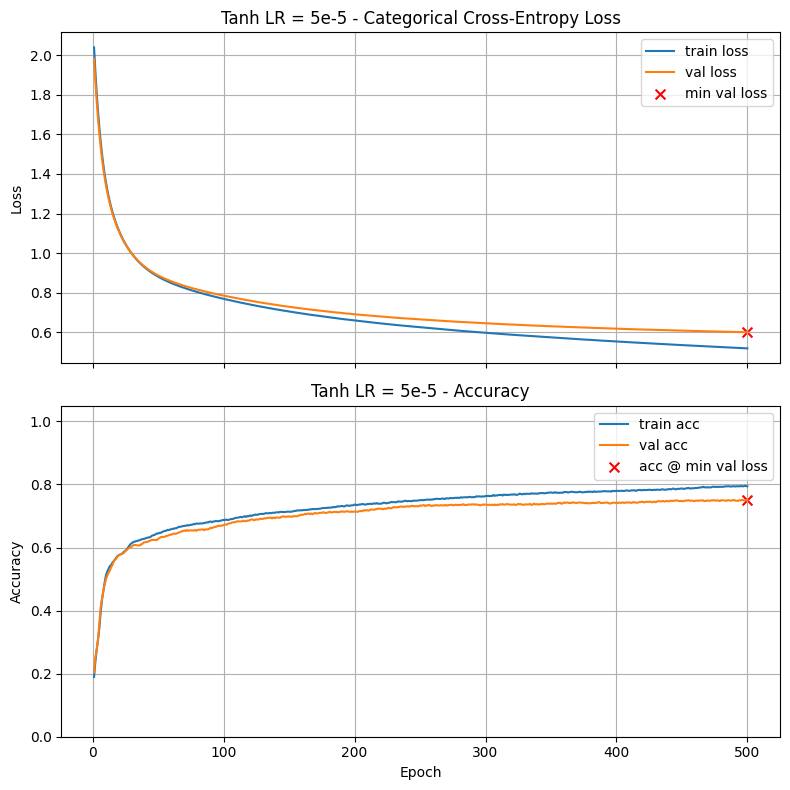

Final Training Loss:            0.5182
Final Training Accuracy:        0.7943
Final Validation Loss:          0.5998
Final Validation Accuracy:      0.7500
Minimum Validation Loss:        0.5998 (Epoch 500)
Validation Accuracy @ Min Loss: 0.7500

Test Loss: 0.6220
Test Accuracy: 0.7393

Validation-Test Gap (accuracy): 0.010714

Execution Time: 00:00:53

Tanh LR = 1e-5



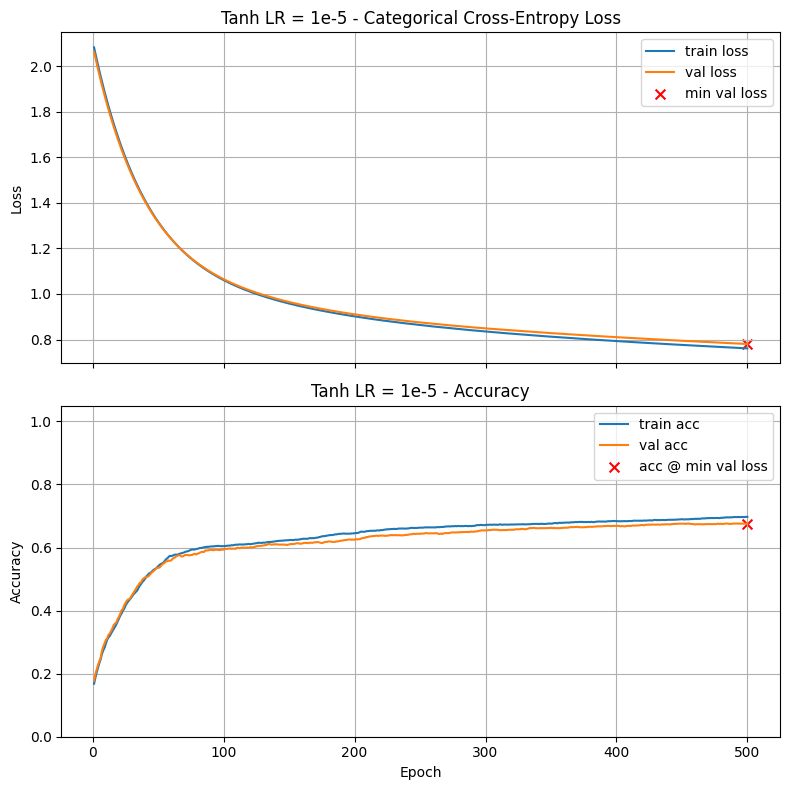

Final Training Loss:            0.7610
Final Training Accuracy:        0.6971
Final Validation Loss:          0.7803
Final Validation Accuracy:      0.6757
Minimum Validation Loss:        0.7803 (Epoch 500)
Validation Accuracy @ Min Loss: 0.6757

Test Loss: 0.7923
Test Accuracy: 0.6900

Validation-Test Gap (accuracy): 0.014286

Execution Time: 00:00:53


In [15]:
train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 0, 0), (32, 'tanh', 0, 0)], n_classes),
               epochs=500,
               lr_schedule=1e-3,
               optimizer='Adam',
               batch_size=64,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title='Tanh LR = 1e-3')

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 0, 0), (32, 'tanh', 0, 0)], n_classes),
               epochs=500,
               lr_schedule=5e-4,
               optimizer='Adam',
               batch_size=64,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title='Tanh LR = 5e-4')

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 0, 0), (32, 'tanh', 0, 0)], n_classes),
               epochs=500,
               lr_schedule=1e-4,
               optimizer='Adam',
               batch_size=64,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title='Tanh LR = 1e-4')

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 0, 0), (32, 'tanh', 0, 0)], n_classes),
               epochs=500,
               lr_schedule=5e-5,
               optimizer='Adam',
               batch_size=64,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title='Tanh LR = 5e-5')

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 0, 0), (32, 'tanh', 0, 0)], n_classes),
               epochs=500,
               lr_schedule=1e-5,
               optimizer='Adam',
               batch_size=64,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title='Tanh LR = 1e-5')

#### Graded Questions

In [16]:
# Set a2a to the learning rate which provided the best validation accuracy at the epoch of minimum validation loss

a2a = 1e-3           # Replace 0.0 with your answer

In [17]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2a = {a2a:.6f}') 

a2a = 0.001000


In [18]:
# Set a2b to the validation accuracy found by this best learning rate

a2b = results['Tanh LR = 1e-3'][0]             # Replace 0.0 with your answer

In [19]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2b = {a2b:.4f}') 

a2b = 0.7771


### Problem Three: Dropout

In this problem, you will explore how **dropout** can help prevent overfitting in neural networks. There are no absolute rules, but some useful heuristics are:

* Dropout typically works best in **later dense layers** (e.g., the second hidden layer of width 32) in the range **0.3–0.5**.
* If applied to **earlier layers** (e.g., the first hidden layer), dropout should be smaller, typically **0.0–0.2** (where 0.0 means no dropout).

**Steps to follow:**

* Build and train the **baseline model** using the **activation function from Problem One** and the **learning rate from Problem Two**.
* Investigate dropout in the ranges suggested, using increments of **0.1**.
* Identify which dropout configuration produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.



Tanh LR = 1e-3 Dropout (64: 0, 32: 0.3)



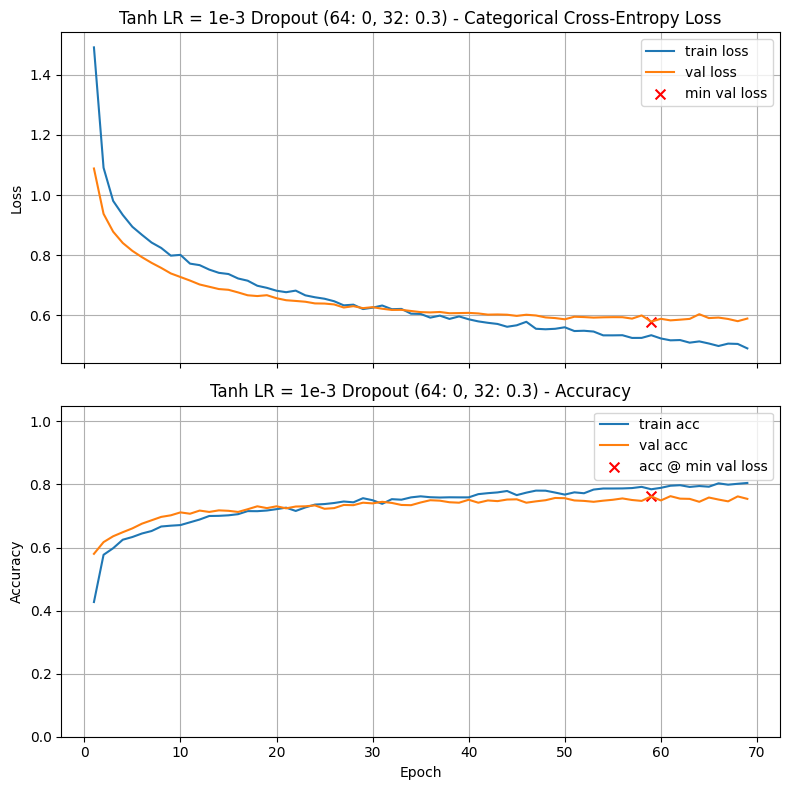

Final Training Loss:            0.4897
Final Training Accuracy:        0.8048
Final Validation Loss:          0.5890
Final Validation Accuracy:      0.7543
Minimum Validation Loss:        0.5788 (Epoch 59)
Validation Accuracy @ Min Loss: 0.7621

Test Loss: 0.6092
Test Accuracy: 0.7593

Validation-Test Gap (accuracy): 0.002857

Execution Time: 00:00:08

Tanh LR = 1e-3 Dropout (64: 0, 32: 0.4)



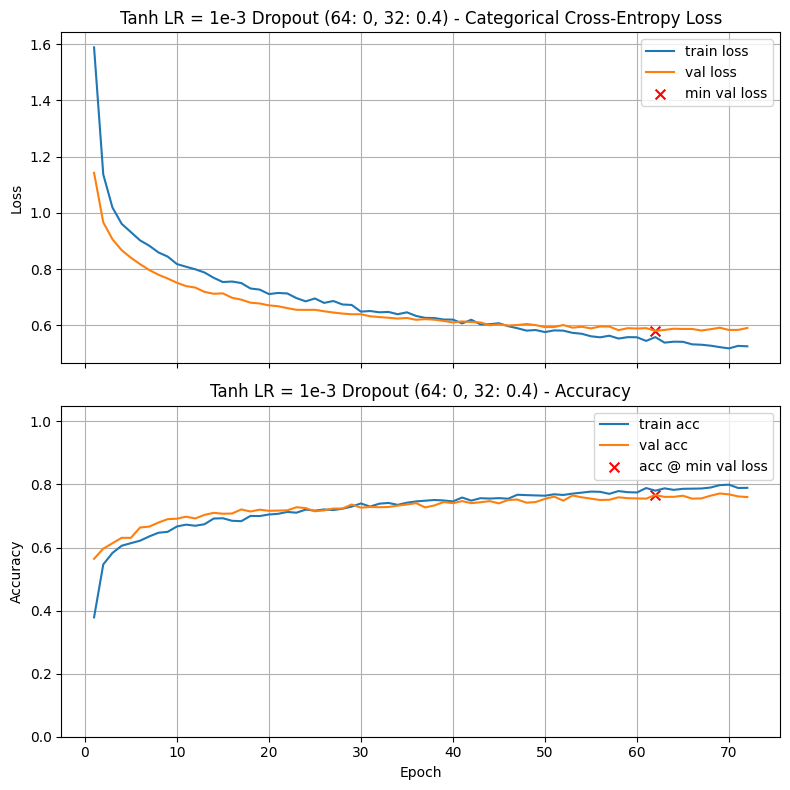

Final Training Loss:            0.5252
Final Training Accuracy:        0.7893
Final Validation Loss:          0.5903
Final Validation Accuracy:      0.7600
Minimum Validation Loss:        0.5802 (Epoch 62)
Validation Accuracy @ Min Loss: 0.7664

Test Loss: 0.6166
Test Accuracy: 0.7507

Validation-Test Gap (accuracy): 0.015714

Execution Time: 00:00:09

Tanh LR = 1e-3 Dropout (64: 0, 32: 0.5)



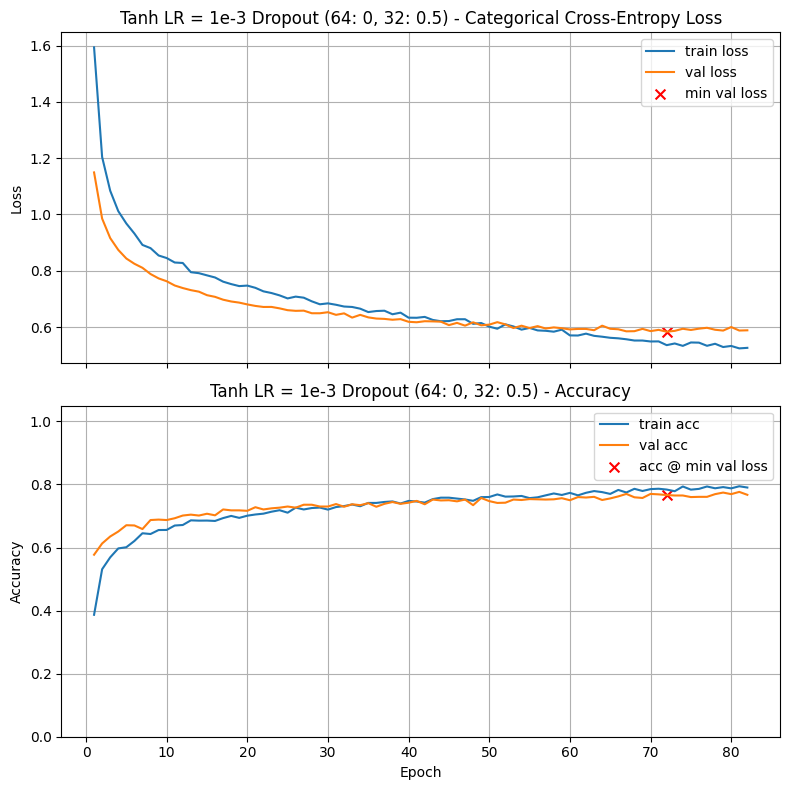

Final Training Loss:            0.5261
Final Training Accuracy:        0.7902
Final Validation Loss:          0.5885
Final Validation Accuracy:      0.7671
Minimum Validation Loss:        0.5835 (Epoch 72)
Validation Accuracy @ Min Loss: 0.7664

Test Loss: 0.6127
Test Accuracy: 0.7486

Validation-Test Gap (accuracy): 0.017857

Execution Time: 00:00:10

Tanh LR = 1e-3 Dropout (64: 0.1, 32: 0.3)



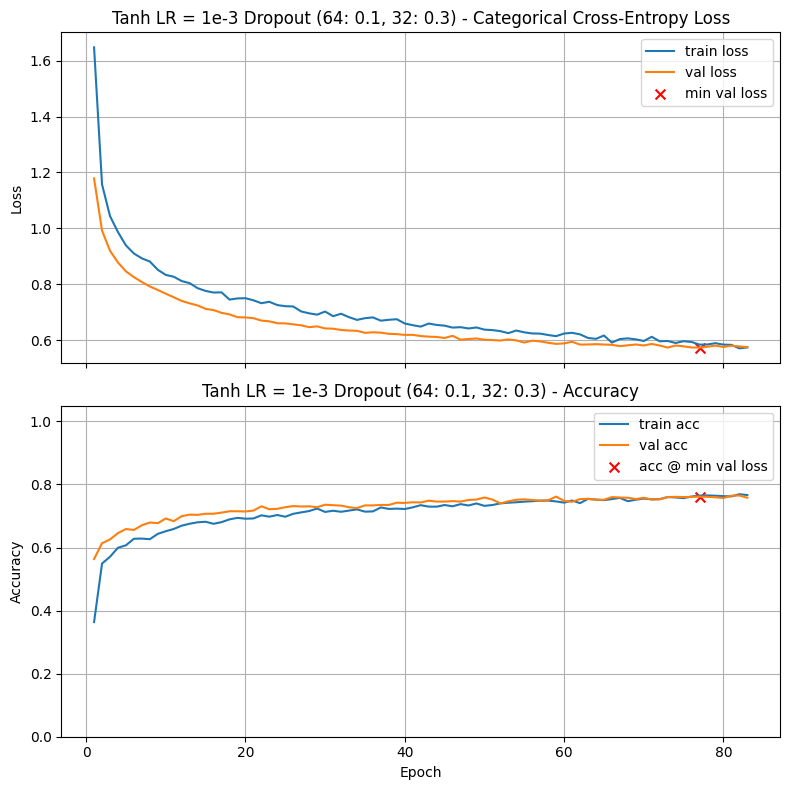

Final Training Loss:            0.5740
Final Training Accuracy:        0.7664
Final Validation Loss:          0.5750
Final Validation Accuracy:      0.7579
Minimum Validation Loss:        0.5733 (Epoch 77)
Validation Accuracy @ Min Loss: 0.7614

Test Loss: 0.6069
Test Accuracy: 0.7514

Validation-Test Gap (accuracy): 0.008571

Execution Time: 00:00:12

Tanh LR = 1e-3 Dropout (64: 0.1, 32: 0.4)



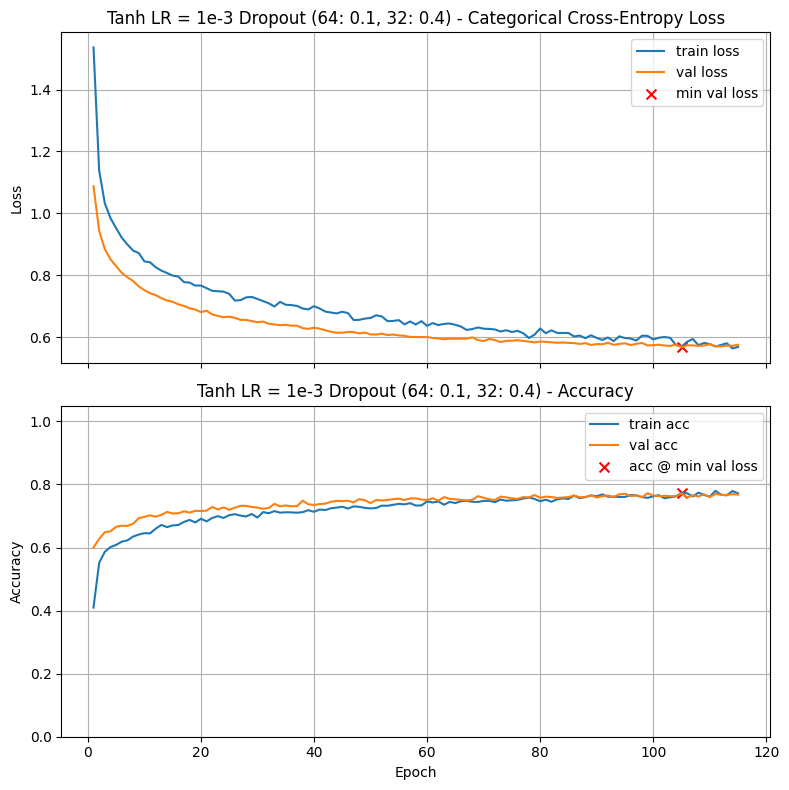

Final Training Loss:            0.5678
Final Training Accuracy:        0.7719
Final Validation Loss:          0.5749
Final Validation Accuracy:      0.7679
Minimum Validation Loss:        0.5669 (Epoch 105)
Validation Accuracy @ Min Loss: 0.7714

Test Loss: 0.5975
Test Accuracy: 0.7686

Validation-Test Gap (accuracy): 0.002857

Execution Time: 00:00:20

Tanh LR = 1e-3 Dropout (64: 0.1, 32: 0.5)



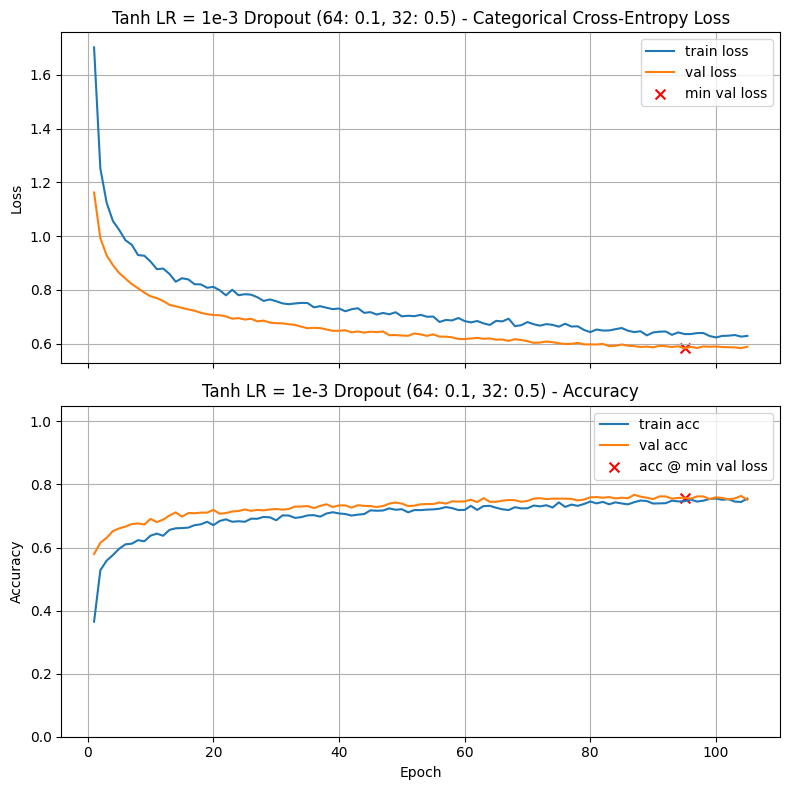

Final Training Loss:            0.6285
Final Training Accuracy:        0.7552
Final Validation Loss:          0.5879
Final Validation Accuracy:      0.7514
Minimum Validation Loss:        0.5819 (Epoch 95)
Validation Accuracy @ Min Loss: 0.7579

Test Loss: 0.6102
Test Accuracy: 0.7450

Validation-Test Gap (accuracy): 0.012857

Execution Time: 00:00:18

Tanh LR = 1e-3 Dropout (64: 0.2, 32: 0.3)



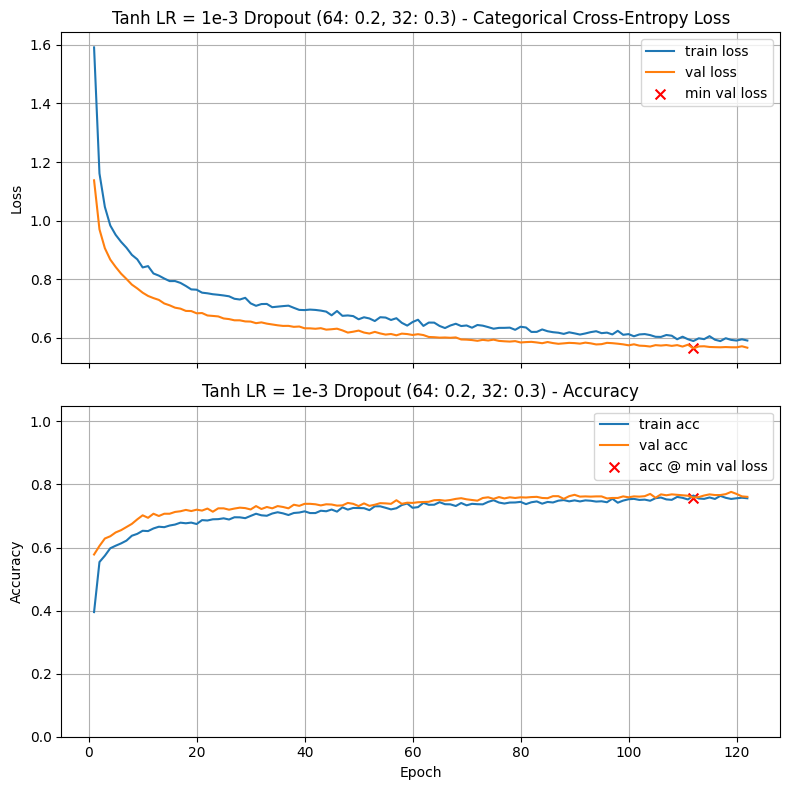

Final Training Loss:            0.5911
Final Training Accuracy:        0.7562
Final Validation Loss:          0.5666
Final Validation Accuracy:      0.7607
Minimum Validation Loss:        0.5643 (Epoch 112)
Validation Accuracy @ Min Loss: 0.7586

Test Loss: 0.5962
Test Accuracy: 0.7493

Validation-Test Gap (accuracy): 0.009286

Execution Time: 00:00:20

Tanh LR = 1e-3 Dropout (64: 0.2, 32: 0.4)



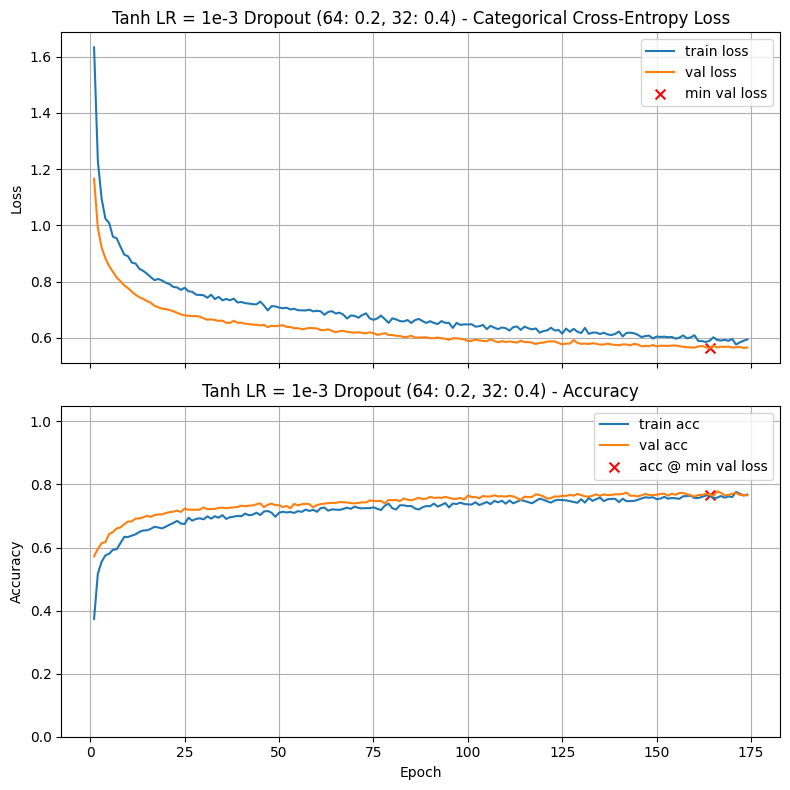

Final Training Loss:            0.5942
Final Training Accuracy:        0.7679
Final Validation Loss:          0.5656
Final Validation Accuracy:      0.7657
Minimum Validation Loss:        0.5624 (Epoch 164)
Validation Accuracy @ Min Loss: 0.7679

Test Loss: 0.6059
Test Accuracy: 0.7586

Validation-Test Gap (accuracy): 0.009286

Execution Time: 00:00:28

Tanh LR = 1e-3 Dropout (64: 0.2, 32: 0.5)



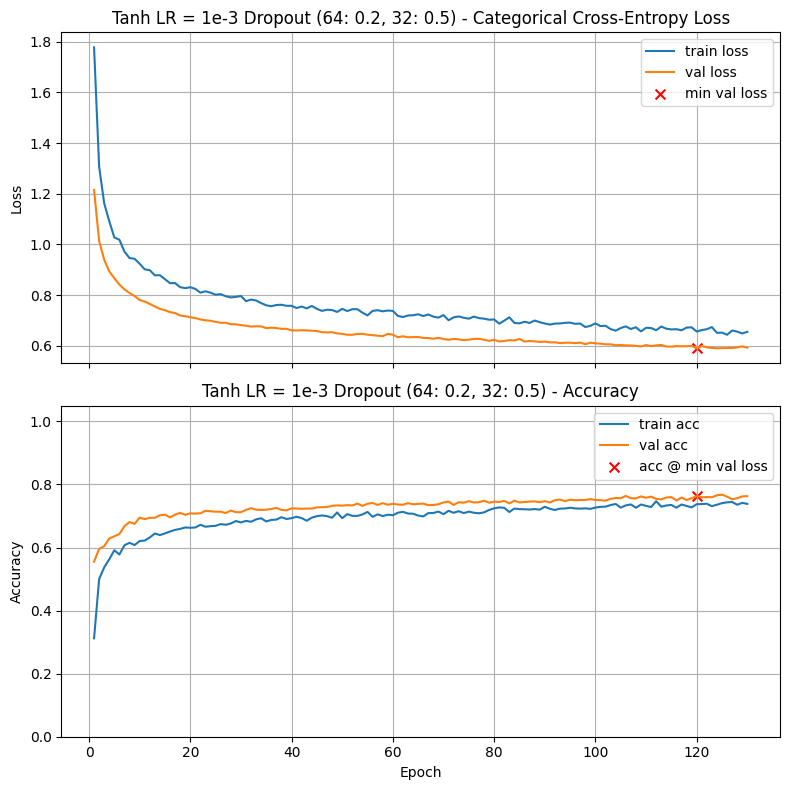

Final Training Loss:            0.6550
Final Training Accuracy:        0.7383
Final Validation Loss:          0.5923
Final Validation Accuracy:      0.7629
Minimum Validation Loss:        0.5895 (Epoch 120)
Validation Accuracy @ Min Loss: 0.7629

Test Loss: 0.6324
Test Accuracy: 0.7414

Validation-Test Gap (accuracy): 0.021429

Execution Time: 00:00:21

Tanh LR = 1e-3 Dropout (64: 0.1, 32: 0)



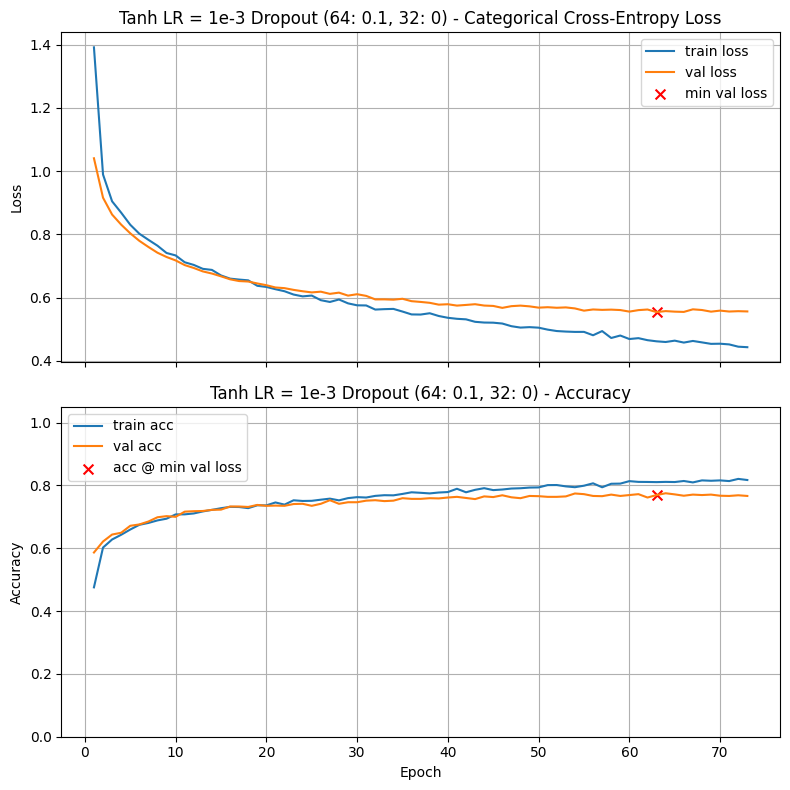

Final Training Loss:            0.4431
Final Training Accuracy:        0.8171
Final Validation Loss:          0.5563
Final Validation Accuracy:      0.7664
Minimum Validation Loss:        0.5542 (Epoch 63)
Validation Accuracy @ Min Loss: 0.7693

Test Loss: 0.5765
Test Accuracy: 0.7550

Validation-Test Gap (accuracy): 0.014286

Execution Time: 00:00:14

Tanh LR = 1e-3 Dropout (64: 0.2, 32: 0)



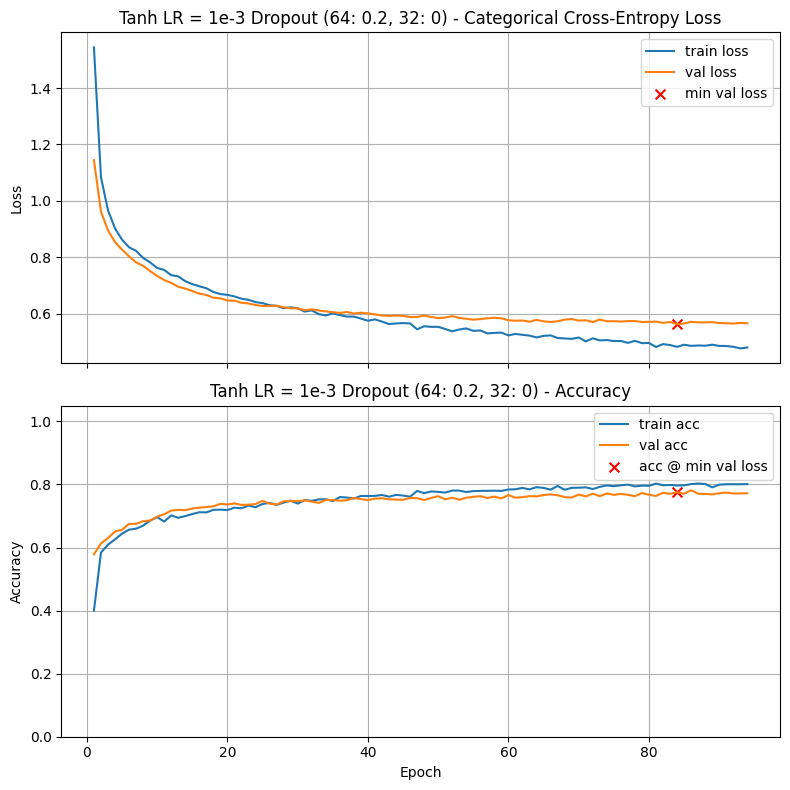

Final Training Loss:            0.4801
Final Training Accuracy:        0.8012
Final Validation Loss:          0.5658
Final Validation Accuracy:      0.7721
Minimum Validation Loss:        0.5628 (Epoch 84)
Validation Accuracy @ Min Loss: 0.7750

Test Loss: 0.5832
Test Accuracy: 0.7550

Validation-Test Gap (accuracy): 0.020000

Execution Time: 00:00:16


In [20]:
# Dropout combinations 
# ONLY 2L Dropouts: (0, 0.3) (0, 0.4) (0, 0.5)                    DONE
# 1L and 2L Dropouts: (0.1, 0.3) (0.1, 0.4) (0.1, 0.5)            DONE
# 1L and 2L Dropouts: (0.2, 0.3) (0.2, 0.4) (0.2, 0.5)            DONE
# ONLY 1L Dropouts: (0.1, 0) (0.2, 0)                             DONE

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 0, 0), (32, 'tanh', 0, 0.3)], n_classes),
               epochs=500,
               lr_schedule=1e-3,
               optimizer='Adam',
               batch_size=64,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title='Tanh LR = 1e-3 Dropout (64: 0, 32: 0.3)')

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 0, 0), (32, 'tanh', 0, 0.4)], n_classes),
               epochs=500,
               lr_schedule=1e-3,
               optimizer='Adam',
               batch_size=64,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title='Tanh LR = 1e-3 Dropout (64: 0, 32: 0.4)')

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 0, 0), (32, 'tanh', 0, 0.5)], n_classes),
               epochs=500,
               lr_schedule=1e-3,
               optimizer='Adam',
               batch_size=64,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title='Tanh LR = 1e-3 Dropout (64: 0, 32: 0.5)')

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 0, 0.1), (32, 'tanh', 0, 0.3)], n_classes),
               epochs=500,
               lr_schedule=1e-3,
               optimizer='Adam',
               batch_size=64,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title='Tanh LR = 1e-3 Dropout (64: 0.1, 32: 0.3)')

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 0, 0.1), (32, 'tanh', 0, 0.4)], n_classes),
               epochs=500,
               lr_schedule=1e-3,
               optimizer='Adam',
               batch_size=64,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title='Tanh LR = 1e-3 Dropout (64: 0.1, 32: 0.4)')

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 0, 0.1), (32, 'tanh', 0, 0.5)], n_classes),
               epochs=500,
               lr_schedule=1e-3,
               optimizer='Adam',
               batch_size=64,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title='Tanh LR = 1e-3 Dropout (64: 0.1, 32: 0.5)')

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 0, 0.2), (32, 'tanh', 0, 0.3)], n_classes),
               epochs=500,
               lr_schedule=1e-3,
               optimizer='Adam',
               batch_size=64,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title='Tanh LR = 1e-3 Dropout (64: 0.2, 32: 0.3)')

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 0, 0.2), (32, 'tanh', 0, 0.4)], n_classes),
               epochs=500,
               lr_schedule=1e-3,
               optimizer='Adam',
               batch_size=64,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title='Tanh LR = 1e-3 Dropout (64: 0.2, 32: 0.4)')

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 0, 0.2), (32, 'tanh', 0, 0.5)], n_classes),
               epochs=500,
               lr_schedule=1e-3,
               optimizer='Adam',
               batch_size=64,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title='Tanh LR = 1e-3 Dropout (64: 0.2, 32: 0.5)')

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 0, 0.1), (32, 'tanh', 0, 0)], n_classes),
               epochs=500,
               lr_schedule=1e-3,
               optimizer='Adam',
               batch_size=64,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title='Tanh LR = 1e-3 Dropout (64: 0.1, 32: 0)')

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 0, 0.2), (32, 'tanh', 0, 0)], n_classes),
               epochs=500,
               lr_schedule=1e-3,
               optimizer='Adam',
               batch_size=64,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title='Tanh LR = 1e-3 Dropout (64: 0.2, 32: 0)')

In [21]:
# Set a3a to the pair (dropout_rate_64,dropout_rate_32) of dropout rates for the two hidden layers which provided the best 
# validation accuracy at the epoch of minimum validation loss

a3a = (0.0,0.5)             # Replace (0.0,0.0) with your answer

In [22]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3a = {a3a}') 

a3a = (0.0, 0.5)


In [23]:
# Set a3b to the validation accuracy found by this best pair of dropout rates

a3b = results['Tanh LR = 1e-3 Dropout (64: 0, 32: 0.5)'][0]             # Replace 0.0 with your answer

In [24]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3b = {a3b:.4f}') 

a3b = 0.7664


### Problem Four: L2 Regularization

In this problem, you will explore how **L2 regularization** (also called *weight decay*) can help prevent overfitting in neural networks. There are no absolute rules, but some useful heuristics are:

* Start simply by using the **same λ in both hidden layers**, with values:

  ```
      1e-4, 1e-3, 1e-2
  ```

* If validation results suggest underfitting in the first layer or persistent overfitting in the later one, then try adjusting per layer, for example:

  * First hidden layer: λ = 1e-4
  * Second hidden layer: λ = 1e-3

**Steps to follow:**

* Build and train the **baseline model** using the **activation function from Problem One** and the **learning rate from Problem Two**, but **without dropout**.
* Investigate at least the four cases suggested (three with the same λ and one with different λ values). You may also consider additional combinations.
* Identify which configuration produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.



Tanh LR = 1e-3 L2 = 1e-4



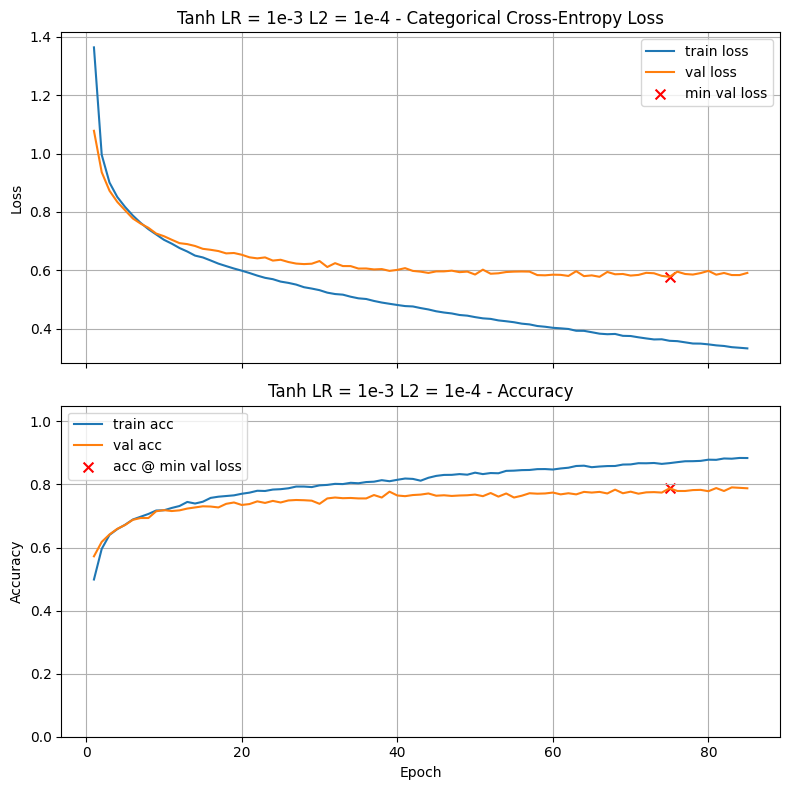

Final Training Loss:            0.3321
Final Training Accuracy:        0.8838
Final Validation Loss:          0.5907
Final Validation Accuracy:      0.7879
Minimum Validation Loss:        0.5774 (Epoch 75)
Validation Accuracy @ Min Loss: 0.7879

Test Loss: 0.5670
Test Accuracy: 0.7771

Validation-Test Gap (accuracy): 0.010714

Execution Time: 00:00:14

Tanh LR = 1e-3 L2 = 1e-3



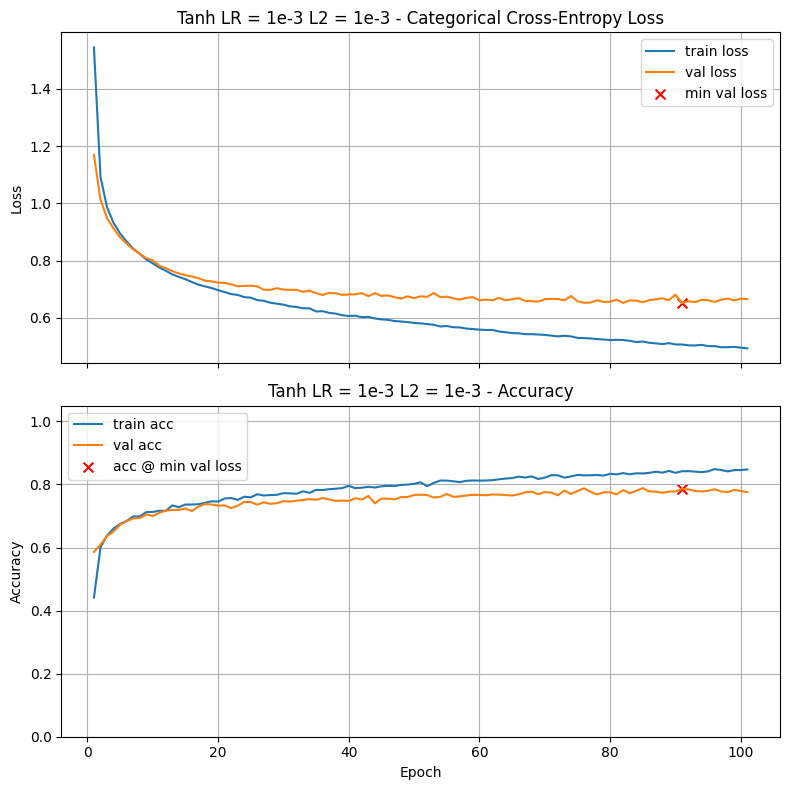

Final Training Loss:            0.4934
Final Training Accuracy:        0.8476
Final Validation Loss:          0.6655
Final Validation Accuracy:      0.7757
Minimum Validation Loss:        0.6518 (Epoch 91)
Validation Accuracy @ Min Loss: 0.7857

Test Loss: 0.6603
Test Accuracy: 0.7771

Validation-Test Gap (accuracy): 0.008571

Execution Time: 00:00:15

Tanh LR = 1e-3 L2 = 1e-2



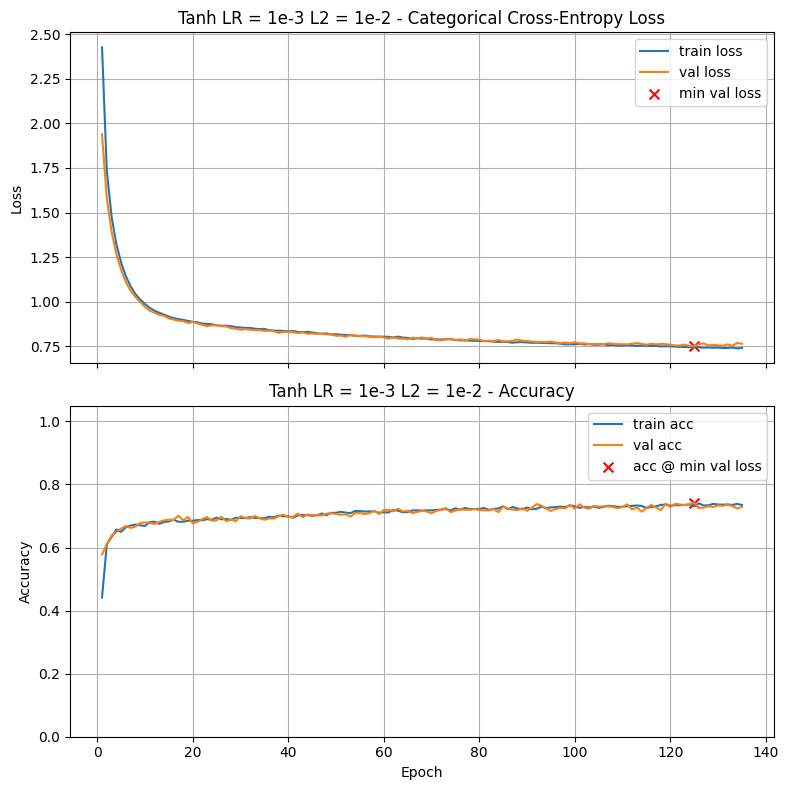

Final Training Loss:            0.7398
Final Training Accuracy:        0.7348
Final Validation Loss:          0.7636
Final Validation Accuracy:      0.7286
Minimum Validation Loss:        0.7501 (Epoch 125)
Validation Accuracy @ Min Loss: 0.7414

Test Loss: 0.7782
Test Accuracy: 0.7300

Validation-Test Gap (accuracy): 0.011429

Execution Time: 00:00:17


In [25]:
train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 1e-4, 0), (32, 'tanh', 1e-4, 0)], n_classes),
               epochs=500,
               lr_schedule=1e-3,
               optimizer='Adam',
               batch_size=64,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title='Tanh LR = 1e-3 L2 = 1e-4')

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 1e-3, 0), (32, 'tanh', 1e-3, 0)], n_classes),
               epochs=500,
               lr_schedule=1e-3,
               optimizer='Adam',
               batch_size=64,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title='Tanh LR = 1e-3 L2 = 1e-3')

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 1e-2, 0), (32, 'tanh', 1e-2, 0)], n_classes),
               epochs=500,
               lr_schedule=1e-3,
               optimizer='Adam',
               batch_size=64,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title='Tanh LR = 1e-3 L2 = 1e-2')

In [26]:
# Set a4a to the pair (L2_lambda_64,L2_lambda_32) of the L2 lambdas for the two hidden layers which provided the best 
# validation accuracy at the epoch of minimum validation loss

a4a = (1e-3,1e-3)             # Replace (0.0,0.0) with your answer

In [27]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4a = {a4a}') 

a4a = (0.001, 0.001)


In [28]:
# Set a4b to the validation accuracy found by this best pair of lambdas

a4b = results['Tanh LR = 1e-3 L2 = 1e-3'][0]             # Replace 0.0 with your answer

In [29]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4b = {a4b:.4f}') 

a4b = 0.7857


### Problem Five: Combining Dropout with L2 Regularization

In this problem, you will explore how **dropout** and **L2 regularization** can work together to prevent overfitting. These two methods complement each other, but must be balanced carefully. A useful rule of thumb is:

* If dropout is **high**, use a **smaller λ**.
* If dropout is **low**, you can afford a **larger λ**.

**Steps to follow:**

* Build and train the **baseline model** using the **activation function from Problem One** and the **learning rate from Problem Two**.
* Investigate combinations of dropout and L2:

  * First, use the **dropout rate you identified in Problem Three** as a baseline.
  * Then, add L2 to both hidden layers with values:

    ```
        1e-4, 1e-3, 1e-2
    ```

    while keeping dropout fixed.
  * Finally, try **reducing dropout slightly** when L2 is added to see if performance improves.
  * [Optional] You may wish to investigate other combinations not covered here; for example, promising but not optimal choices of dropout rates may provide overall better performance when combines with L2 Regulari 
* Identify which combination produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.



In [30]:
# BASELINE
results['Tanh LR = 1e-3 Dropout (64: 0, 32: 0.5)'][0]

0.7664285898208618


Tanh LR = 1e-3 L2 = 1e-4 Dropout (64: 0, 32: 0.5)



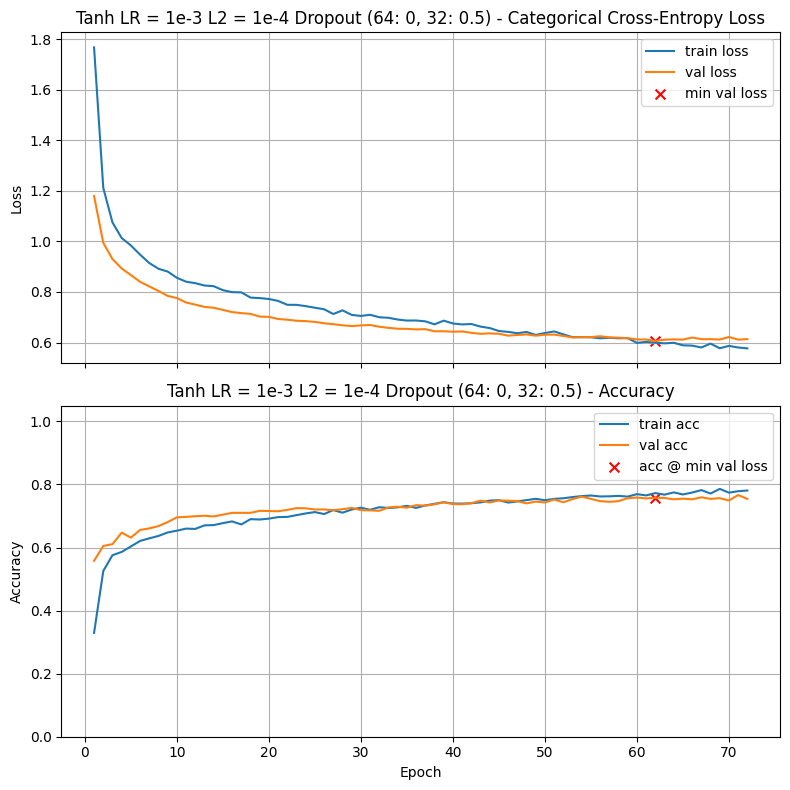

Final Training Loss:            0.5769
Final Training Accuracy:        0.7807
Final Validation Loss:          0.6135
Final Validation Accuracy:      0.7543
Minimum Validation Loss:        0.6063 (Epoch 62)
Validation Accuracy @ Min Loss: 0.7579

Test Loss: 0.6322
Test Accuracy: 0.7493

Validation-Test Gap (accuracy): 0.008571

Execution Time: 00:00:10

Tanh LR = 1e-3 L2 = 1e-3 Dropout (64: 0, 32: 0.5)



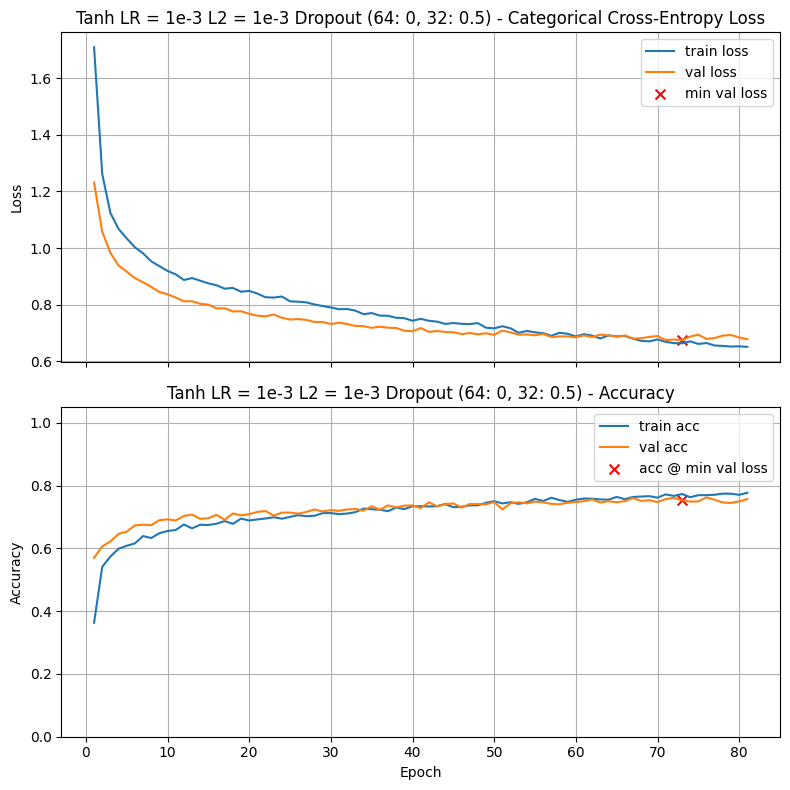

Final Training Loss:            0.6512
Final Training Accuracy:        0.7774
Final Validation Loss:          0.6782
Final Validation Accuracy:      0.7571
Minimum Validation Loss:        0.6748 (Epoch 73)
Validation Accuracy @ Min Loss: 0.7536

Test Loss: 0.7130
Test Accuracy: 0.7414

Validation-Test Gap (accuracy): 0.015714

Execution Time: 00:00:12

Tanh LR = 1e-3 L2 = 1e-2 Dropout (64: 0, 32: 0.5)



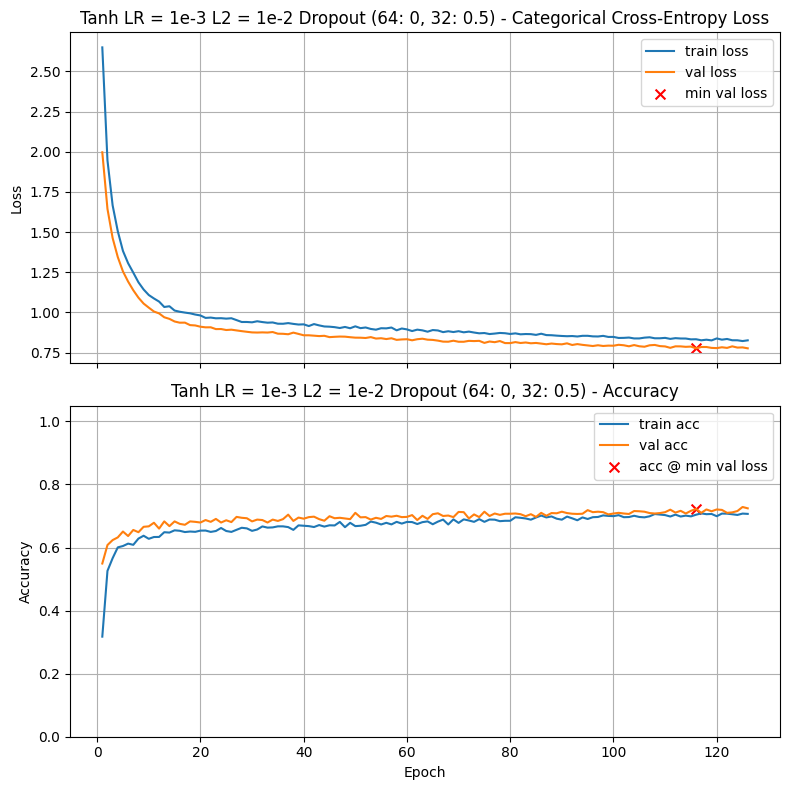

Final Training Loss:            0.8258
Final Training Accuracy:        0.7067
Final Validation Loss:          0.7760
Final Validation Accuracy:      0.7243
Minimum Validation Loss:        0.7757 (Epoch 116)
Validation Accuracy @ Min Loss: 0.7221

Test Loss: 0.8085
Test Accuracy: 0.7129

Validation-Test Gap (accuracy): 0.009286

Execution Time: 00:00:19

Tanh LR = 1e-3 L2 = 1e-4 Dropout (64: 0, 32: 0.4)



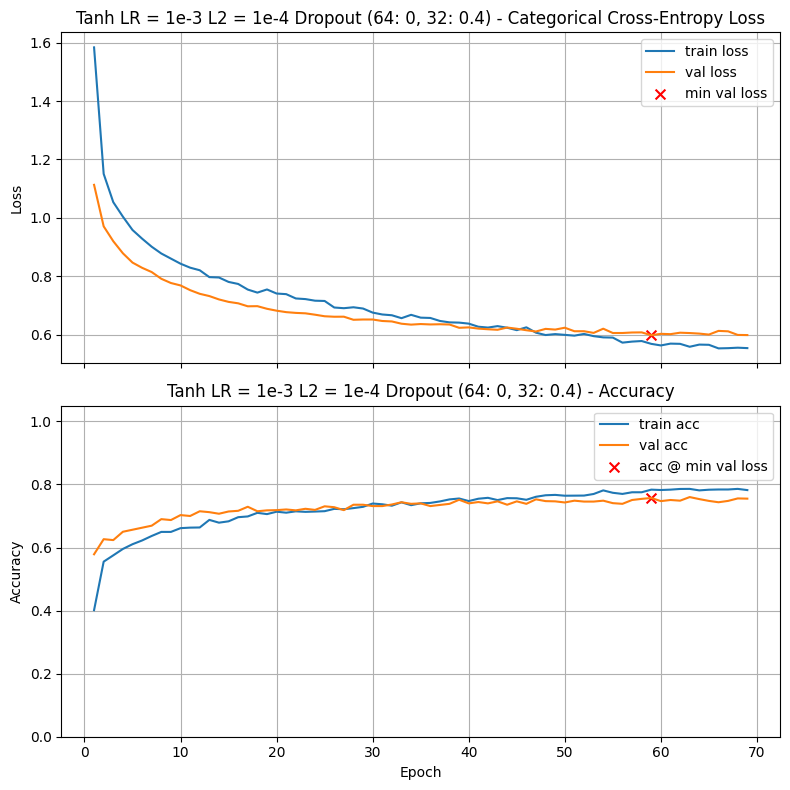

Final Training Loss:            0.5538
Final Training Accuracy:        0.7821
Final Validation Loss:          0.5984
Final Validation Accuracy:      0.7550
Minimum Validation Loss:        0.5979 (Epoch 59)
Validation Accuracy @ Min Loss: 0.7571

Test Loss: 0.6228
Test Accuracy: 0.7464

Validation-Test Gap (accuracy): 0.010714

Execution Time: 00:00:10

Tanh LR = 1e-3 L2 = 1e-3 Dropout (64: 0, 32: 0.4)



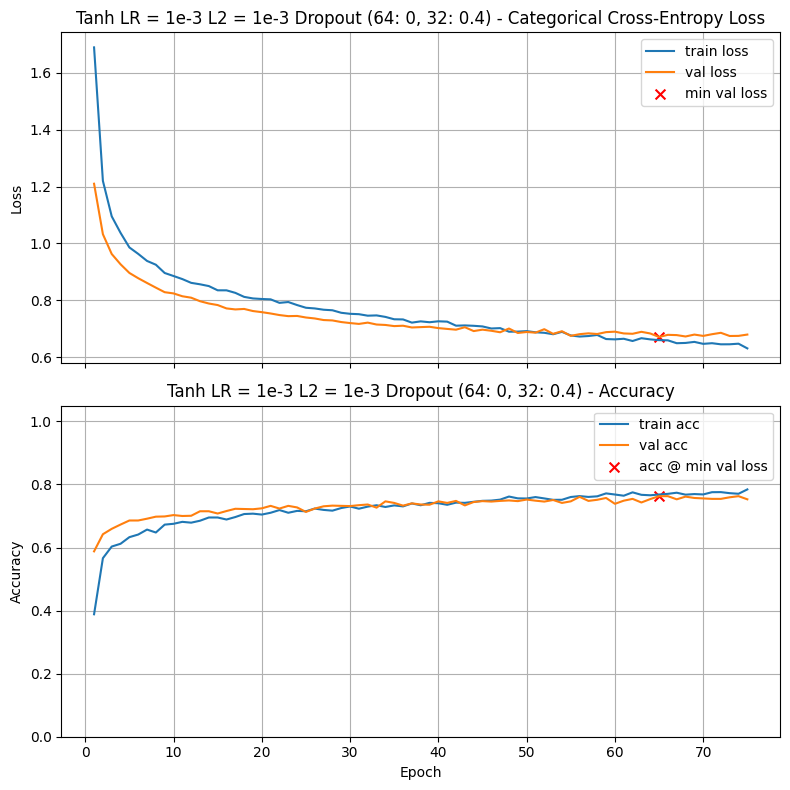

Final Training Loss:            0.6307
Final Training Accuracy:        0.7843
Final Validation Loss:          0.6793
Final Validation Accuracy:      0.7529
Minimum Validation Loss:        0.6708 (Epoch 65)
Validation Accuracy @ Min Loss: 0.7629

Test Loss: 0.6998
Test Accuracy: 0.7457

Validation-Test Gap (accuracy): 0.017143

Execution Time: 00:00:10

Tanh LR = 1e-3 L2 = 1e-2 Dropout (64: 0, 32: 0.4)



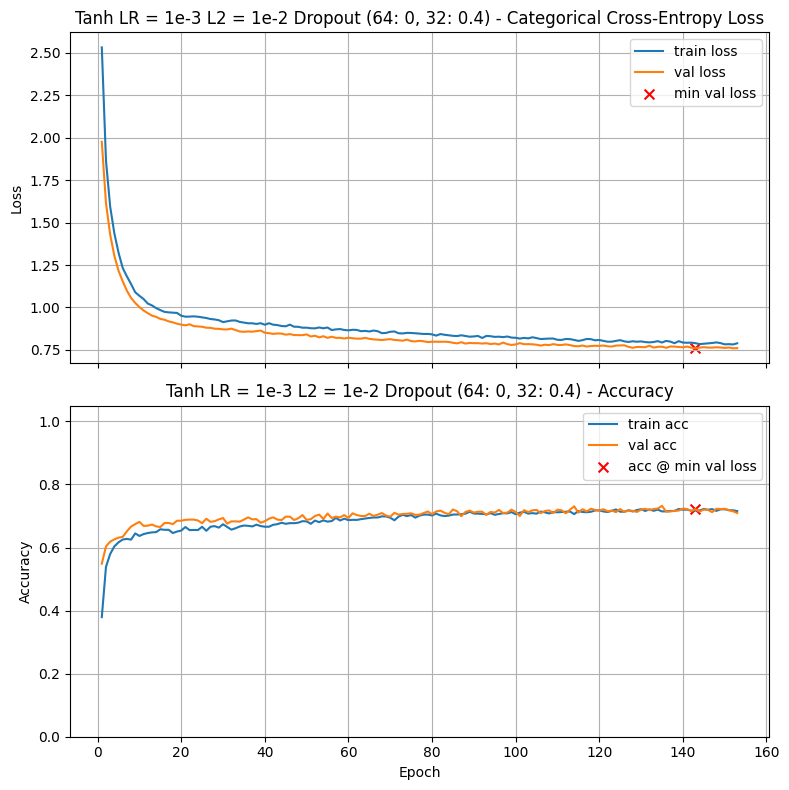

Final Training Loss:            0.7887
Final Training Accuracy:        0.7155
Final Validation Loss:          0.7602
Final Validation Accuracy:      0.7093
Minimum Validation Loss:        0.7589 (Epoch 143)
Validation Accuracy @ Min Loss: 0.7214

Test Loss: 0.7902
Test Accuracy: 0.7079

Validation-Test Gap (accuracy): 0.013571

Execution Time: 00:00:20


In [31]:
train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 1e-4, 0), (32, 'tanh', 1e-4, 0.5)], n_classes),
               epochs=500,
               lr_schedule=1e-3,
               optimizer='Adam',
               batch_size=64,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title='Tanh LR = 1e-3 L2 = 1e-4 Dropout (64: 0, 32: 0.5)')

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 1e-3, 0), (32, 'tanh', 1e-3, 0.5)], n_classes),
               epochs=500,
               lr_schedule=1e-3,
               optimizer='Adam',
               batch_size=64,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title='Tanh LR = 1e-3 L2 = 1e-3 Dropout (64: 0, 32: 0.5)')

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 1e-2, 0), (32, 'tanh', 1e-2, 0.5)], n_classes),
               epochs=500,
               lr_schedule=1e-3,
               optimizer='Adam',
               batch_size=64,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title='Tanh LR = 1e-3 L2 = 1e-2 Dropout (64: 0, 32: 0.5)')

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 1e-4, 0), (32, 'tanh', 1e-4, 0.4)], n_classes),
               epochs=500,
               lr_schedule=1e-3,
               optimizer='Adam',
               batch_size=64,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title='Tanh LR = 1e-3 L2 = 1e-4 Dropout (64: 0, 32: 0.4)')

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 1e-3, 0), (32, 'tanh', 1e-3, 0.4)], n_classes),
               epochs=500,
               lr_schedule=1e-3,
               optimizer='Adam',
               batch_size=64,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title='Tanh LR = 1e-3 L2 = 1e-3 Dropout (64: 0, 32: 0.4)')

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 1e-2, 0), (32, 'tanh', 1e-2, 0.4)], n_classes),
               epochs=500,
               lr_schedule=1e-3,
               optimizer='Adam',
               batch_size=64,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title='Tanh LR = 1e-3 L2 = 1e-2 Dropout (64: 0, 32: 0.4)')

no improvement when introducing L2 and dropout compared to just the dropout baseline.

In [32]:
# Set a5 to the validation accuracy found by this best combination of dropout and L2 regularization

a5 = results['Tanh LR = 1e-3 Dropout (64: 0, 32: 0.5)'][0]             # Replace 0.0 with your answer

In [33]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5 = {a5:.4f}') 

a5 = 0.7664


### Problem Six: Build and Train Your Best Model

In this final problem, you will design and train your **best-performing model** using the techniques explored in the previous problems. You may make your own choices for:

* **Model architecture** (number of layers, widths, etc.)
* **Learning rate**
* **Batch size** (a new hyperparameter not varied in earlier problems)
* **Dropout rates** in both layers
* **L2 λ values** in both layers
* **[Optional but strongly suggested]:** Learning rate scheduling, using either **Exponential Decay** or **Cosine Decay**.

  * For Exponential Decay, typical decay rates are **0.90–0.999**, with **0.95** often a good starting point.

**Steps to follow:**

* Build and train the model according to your design choices.
* Use early stopping as before to evaluate performance at the epoch of **minimum validation loss**.
* Answer the graded question.


In [34]:
from tensorflow.keras.optimizers.schedules import CosineDecay


Tanh Dropout (72: 0, 64: 0, 32: 0.5) Exp. Decay (0.001, decay=0.99) Batch = 72



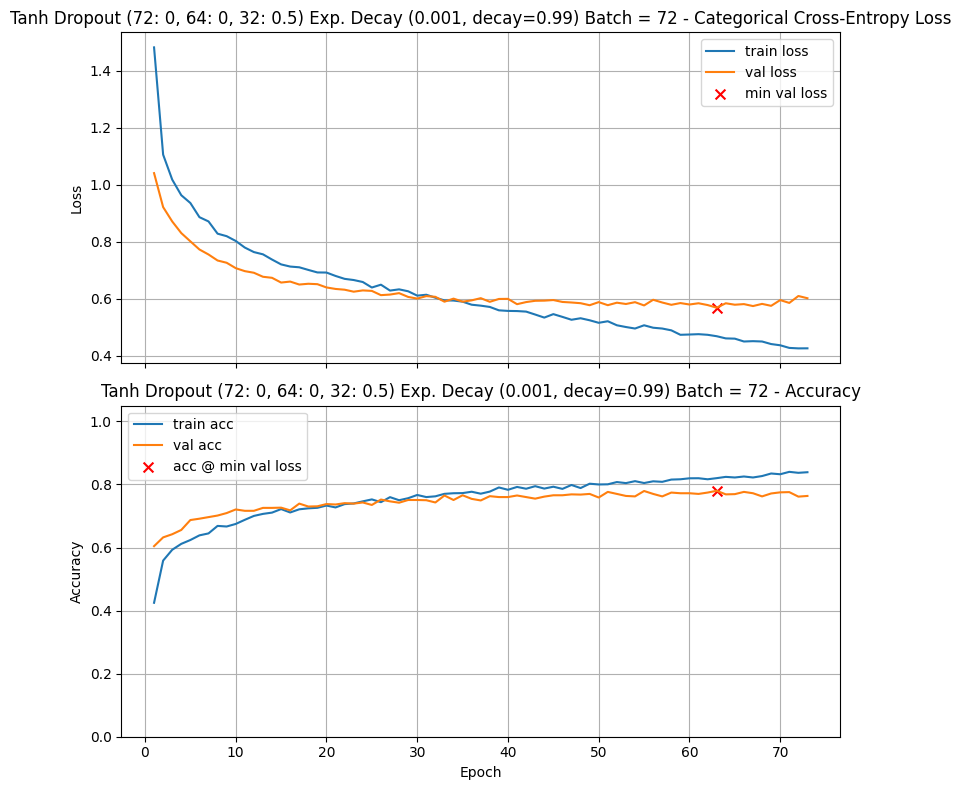

Final Training Loss:            0.4256
Final Training Accuracy:        0.8388
Final Validation Loss:          0.6014
Final Validation Accuracy:      0.7636
Minimum Validation Loss:        0.5683 (Epoch 63)
Validation Accuracy @ Min Loss: 0.7800

Test Loss: 0.5943
Test Accuracy: 0.7764

Validation-Test Gap (accuracy): 0.003571

Execution Time: 00:00:09


In [70]:
epochs = 500
batch_size = 72
steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
total_steps = epochs * steps_per_epoch
decay_rate = 0.99
initial_learning_rate = 1e-3

exp_decay = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=total_steps,
    decay_rate=decay_rate
)

train_and_test(model=build_model(X_train.shape[1], [ (72, 'tanh', 0, 0), (64, 'tanh', 0, 0), (32, 'tanh', 0, 0.5)], n_classes),
               epochs=epochs,
               lr_schedule=exp_decay,
               optimizer='Adam',
               batch_size=batch_size,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title=f'Tanh Dropout (72: 0, 64: 0, 32: 0.5) Exp. Decay ({initial_learning_rate}, decay={decay_rate}) Batch = {batch_size}')


Tanh Dropout (72: 0.1, 64: 0, 32: 0.5) Exp. Decay (0.001, decay=0.99) Batch = 72



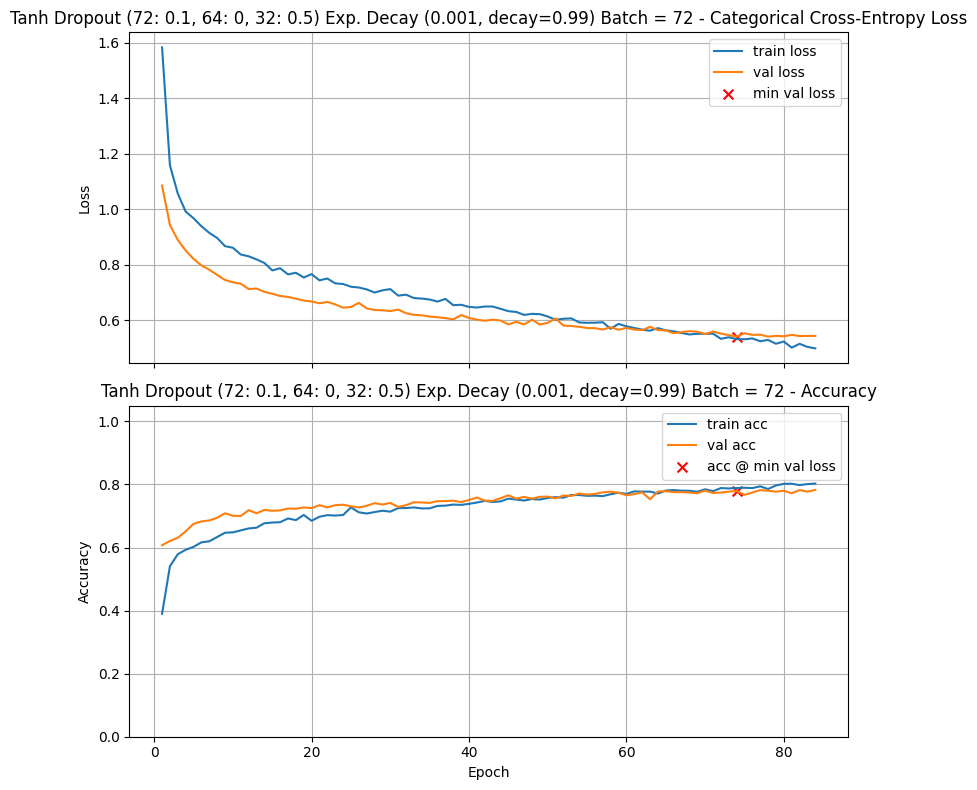

Final Training Loss:            0.4993
Final Training Accuracy:        0.8029
Final Validation Loss:          0.5442
Final Validation Accuracy:      0.7829
Minimum Validation Loss:        0.5416 (Epoch 74)
Validation Accuracy @ Min Loss: 0.7793

Test Loss: 0.5811
Test Accuracy: 0.7700

Validation-Test Gap (accuracy): 0.009286

Execution Time: 00:00:11


In [72]:
epochs = 500
batch_size = 72
steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
total_steps = epochs * steps_per_epoch
decay_rate = 0.99
initial_learning_rate = 1e-3

exp_decay = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=total_steps,
    decay_rate=decay_rate
)

train_and_test(model=build_model(X_train.shape[1], [ (72, 'tanh', 0, 0.1), (64, 'tanh', 0, 0), (32, 'tanh', 0, 0.5)], n_classes),
               epochs=epochs,
               lr_schedule=exp_decay,
               optimizer='Adam',
               batch_size=batch_size,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title=f'Tanh Dropout (72: 0.1, 64: 0, 32: 0.5) Exp. Decay ({initial_learning_rate}, decay={decay_rate}) Batch = {batch_size}')


Tanh Dropout (72: 0.1, 64: 0.1, 32: 0.5) Exp. Decay (0.001, decay=0.99) Batch = 72



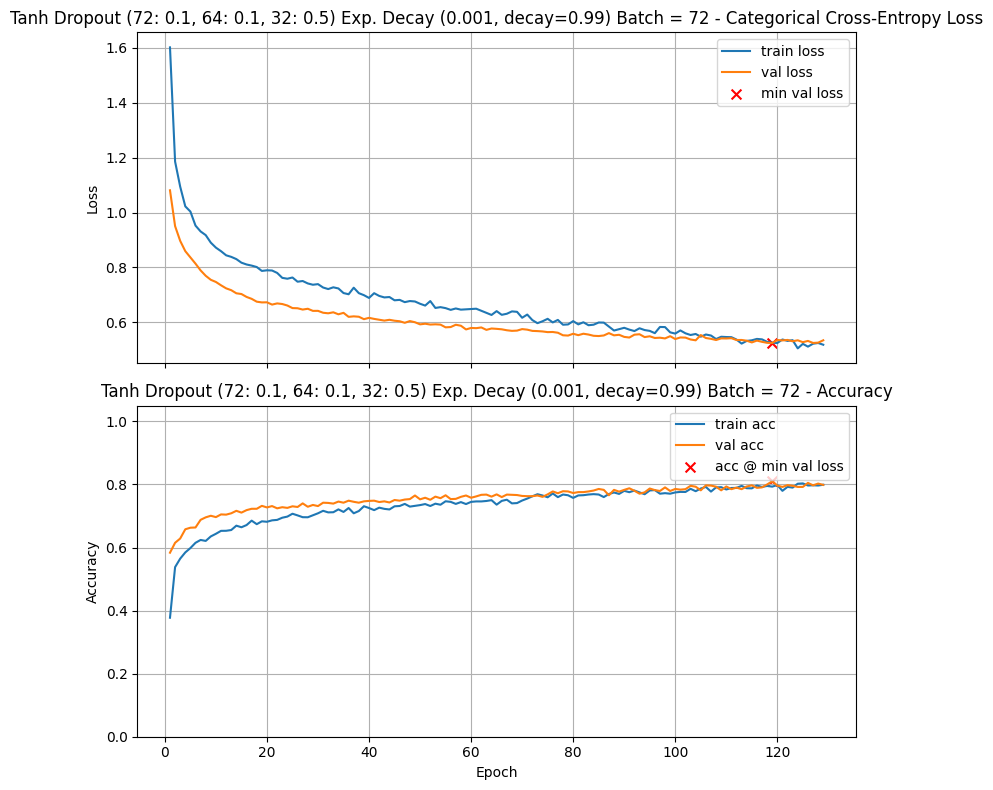

Final Training Loss:            0.5179
Final Training Accuracy:        0.7990
Final Validation Loss:          0.5341
Final Validation Accuracy:      0.7986
Minimum Validation Loss:        0.5244 (Epoch 119)
Validation Accuracy @ Min Loss: 0.8100

Test Loss: 0.5823
Test Accuracy: 0.7800

Validation-Test Gap (accuracy): 0.030000

Execution Time: 00:00:17


In [73]:
epochs = 500
batch_size = 72
steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
total_steps = epochs * steps_per_epoch
decay_rate = 0.99
initial_learning_rate = 1e-3

exp_decay = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=total_steps,
    decay_rate=decay_rate
)

train_and_test(model=build_model(X_train.shape[1], [ (72, 'tanh', 0, 0.1), (64, 'tanh', 0, 0.1), (32, 'tanh', 0, 0.5)], n_classes),
               epochs=epochs,
               lr_schedule=exp_decay,
               optimizer='Adam',
               batch_size=batch_size,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title=f'Tanh Dropout (72: 0.1, 64: 0.1, 32: 0.5) Exp. Decay ({initial_learning_rate}, decay={decay_rate}) Batch = {batch_size}')


Tanh Dropout (72: 0.1, 64: 0.1, 32: 0.5) Exp. Decay (0.001, decay=0.99) Batch = 64



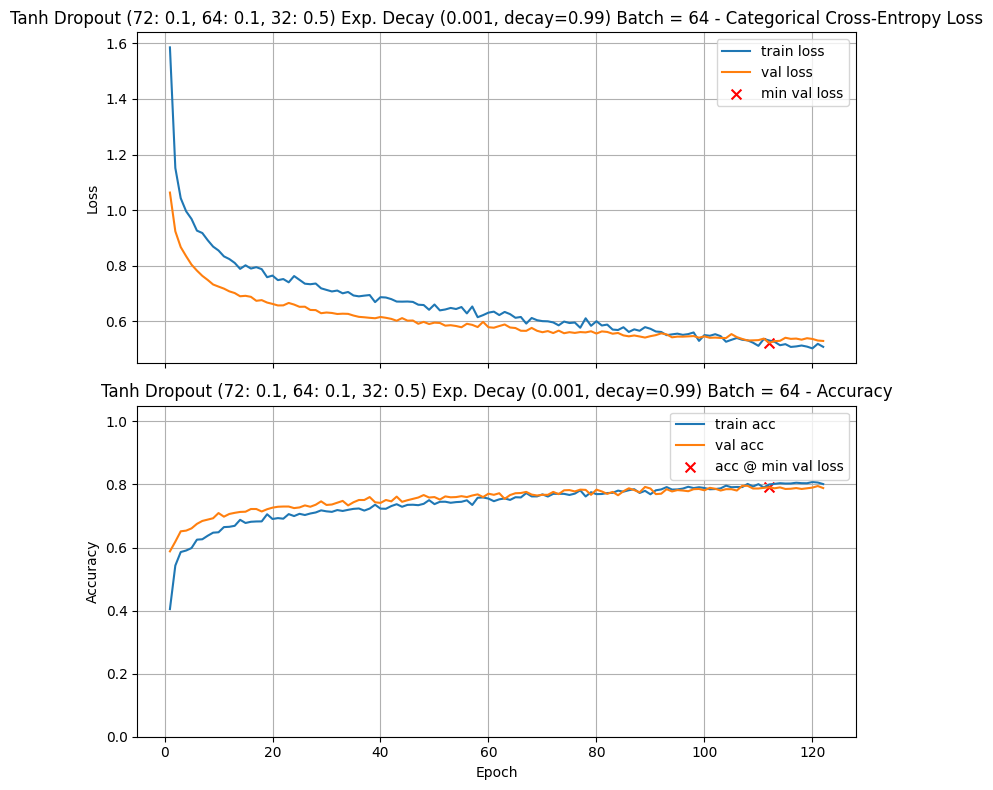

Final Training Loss:            0.5085
Final Training Accuracy:        0.8012
Final Validation Loss:          0.5296
Final Validation Accuracy:      0.7886
Minimum Validation Loss:        0.5230 (Epoch 112)
Validation Accuracy @ Min Loss: 0.7907

Test Loss: 0.5821
Test Accuracy: 0.7743

Validation-Test Gap (accuracy): 0.016429

Execution Time: 00:00:18


In [75]:
epochs = 500
batch_size = 64
steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
total_steps = epochs * steps_per_epoch
decay_rate = 0.99
initial_learning_rate = 1e-3

exp_decay = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=total_steps,
    decay_rate=decay_rate
)

train_and_test(model=build_model(X_train.shape[1], [ (72, 'tanh', 0, 0.1), (64, 'tanh', 0, 0.1), (32, 'tanh', 0, 0.5)], n_classes),
               epochs=epochs,
               lr_schedule=exp_decay,
               optimizer='Adam',
               batch_size=batch_size,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title=f'Tanh Dropout (72: 0.1, 64: 0.1, 32: 0.5) Exp. Decay ({initial_learning_rate}, decay={decay_rate}) Batch = {batch_size}')


Tanh Dropout (72: 0, 64: 0.1, 32: 0.5) Exp. Decay (0.001, decay=0.99) Batch = 64



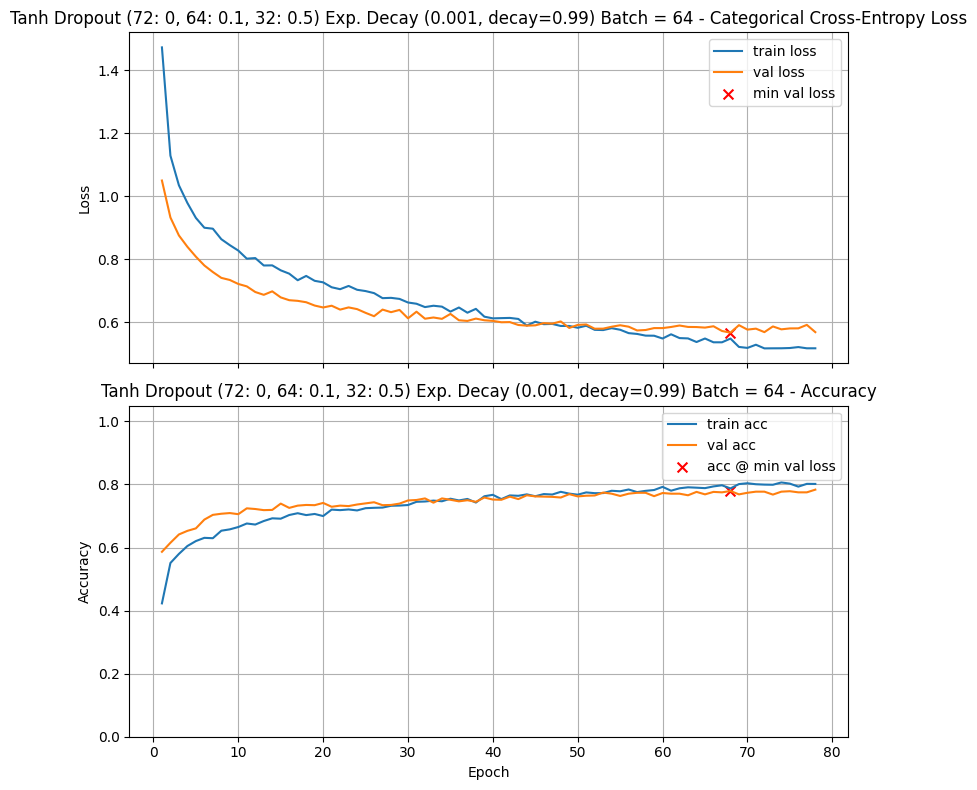

Final Training Loss:            0.5165
Final Training Accuracy:        0.8017
Final Validation Loss:          0.5679
Final Validation Accuracy:      0.7836
Minimum Validation Loss:        0.5661 (Epoch 68)
Validation Accuracy @ Min Loss: 0.7793

Test Loss: 0.6153
Test Accuracy: 0.7579

Validation-Test Gap (accuracy): 0.021429

Execution Time: 00:00:12


In [76]:
epochs = 500
batch_size = 64
steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
total_steps = epochs * steps_per_epoch
decay_rate = 0.99
initial_learning_rate = 1e-3

exp_decay = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=total_steps,
    decay_rate=decay_rate
)

train_and_test(model=build_model(X_train.shape[1], [ (72, 'tanh', 0, 0), (64, 'tanh', 0, 0.1), (32, 'tanh', 0, 0.5)], n_classes),
               epochs=epochs,
               lr_schedule=exp_decay,
               optimizer='Adam',
               batch_size=batch_size,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title=f'Tanh Dropout (72: 0, 64: 0.1, 32: 0.5) Exp. Decay ({initial_learning_rate}, decay={decay_rate}) Batch = {batch_size}')


Tanh Dropout (72: 0.1, 64: 0.1, 32: 0.4) Exp. Decay (0.001, decay=0.99) Batch = 72



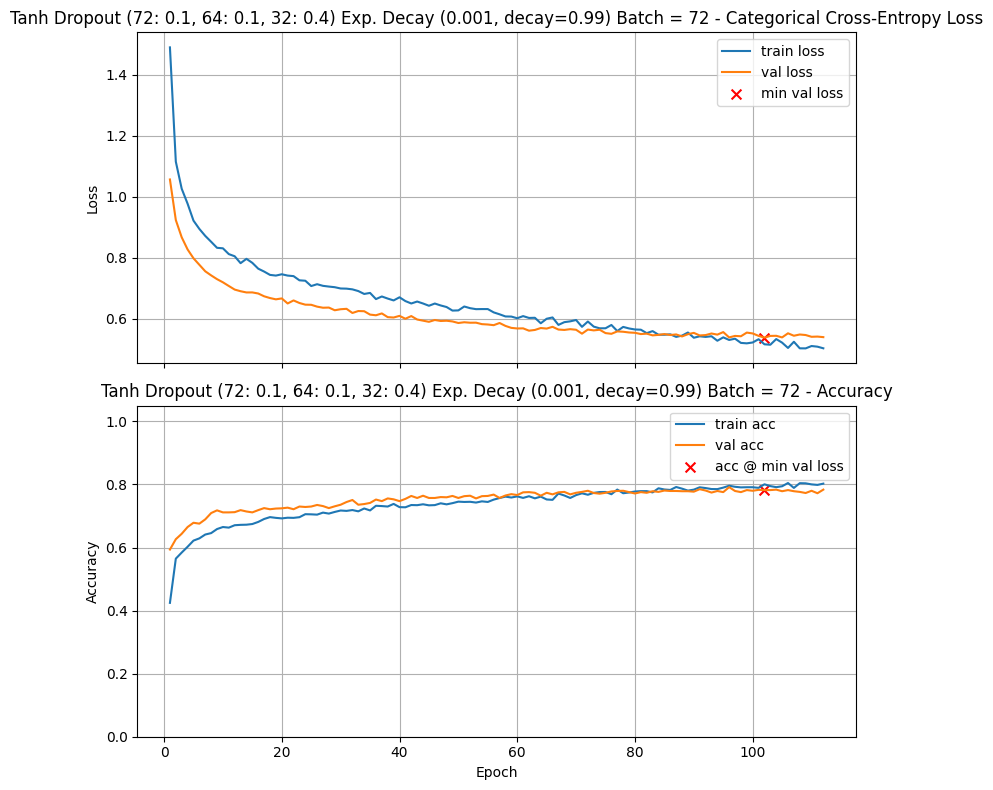

Final Training Loss:            0.5038
Final Training Accuracy:        0.8026
Final Validation Loss:          0.5403
Final Validation Accuracy:      0.7836
Minimum Validation Loss:        0.5388 (Epoch 102)
Validation Accuracy @ Min Loss: 0.7821

Test Loss: 0.5851
Test Accuracy: 0.7686

Validation-Test Gap (accuracy): 0.013571

Execution Time: 00:00:15


In [74]:
epochs = 500
batch_size = 72
steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
total_steps = epochs * steps_per_epoch
decay_rate = 0.99
initial_learning_rate = 1e-3

exp_decay = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=total_steps,
    decay_rate=decay_rate
)

train_and_test(model=build_model(X_train.shape[1], [ (72, 'tanh', 0, 0.1), (64, 'tanh', 0, 0.1), (32, 'tanh', 0, 0.4)], n_classes),
               epochs=epochs,
               lr_schedule=exp_decay,
               optimizer='Adam',
               batch_size=batch_size,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title=f'Tanh Dropout (72: 0.1, 64: 0.1, 32: 0.4) Exp. Decay ({initial_learning_rate}, decay={decay_rate}) Batch = {batch_size}')


Tanh Dropout (128: 0, 72: 0, 64: 0, 32: 0.5) Exp. Decay (0.001, decay=0.99) Batch = 72



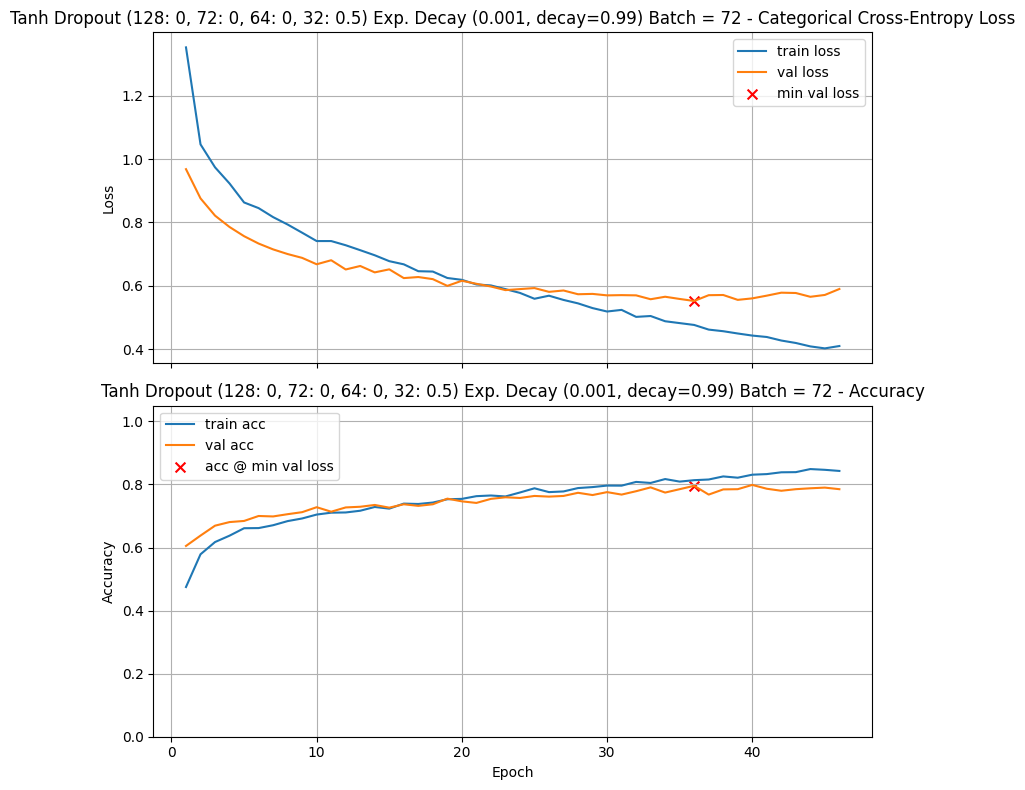

Final Training Loss:            0.4101
Final Training Accuracy:        0.8429
Final Validation Loss:          0.5900
Final Validation Accuracy:      0.7850
Minimum Validation Loss:        0.5522 (Epoch 36)
Validation Accuracy @ Min Loss: 0.7957

Test Loss: 0.5730
Test Accuracy: 0.7721

Validation-Test Gap (accuracy): 0.023571

Execution Time: 00:00:07


In [68]:
epochs = 500
batch_size = 72
steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
total_steps = epochs * steps_per_epoch
decay_rate = 0.99
initial_learning_rate = 1e-3

exp_decay = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=total_steps,
    decay_rate=decay_rate
)

train_and_test(model=build_model(X_train.shape[1], [ (128, 'tanh', 0, 0), (72, 'tanh', 0, 0), (64, 'tanh', 0, 0), (32, 'tanh', 0, 0.5)], n_classes),
               epochs=epochs,
               lr_schedule=exp_decay,
               optimizer='Adam',
               batch_size=batch_size,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title=f'Tanh Dropout (128: 0, 72: 0, 64: 0, 32: 0.5) Exp. Decay ({initial_learning_rate}, decay={decay_rate}) Batch = {batch_size}')


Tanh Dropout (128: 0, 72: 0, 64: 0.1, 32: 0.5) Exp. Decay (0.001, decay=0.99) Batch = 72



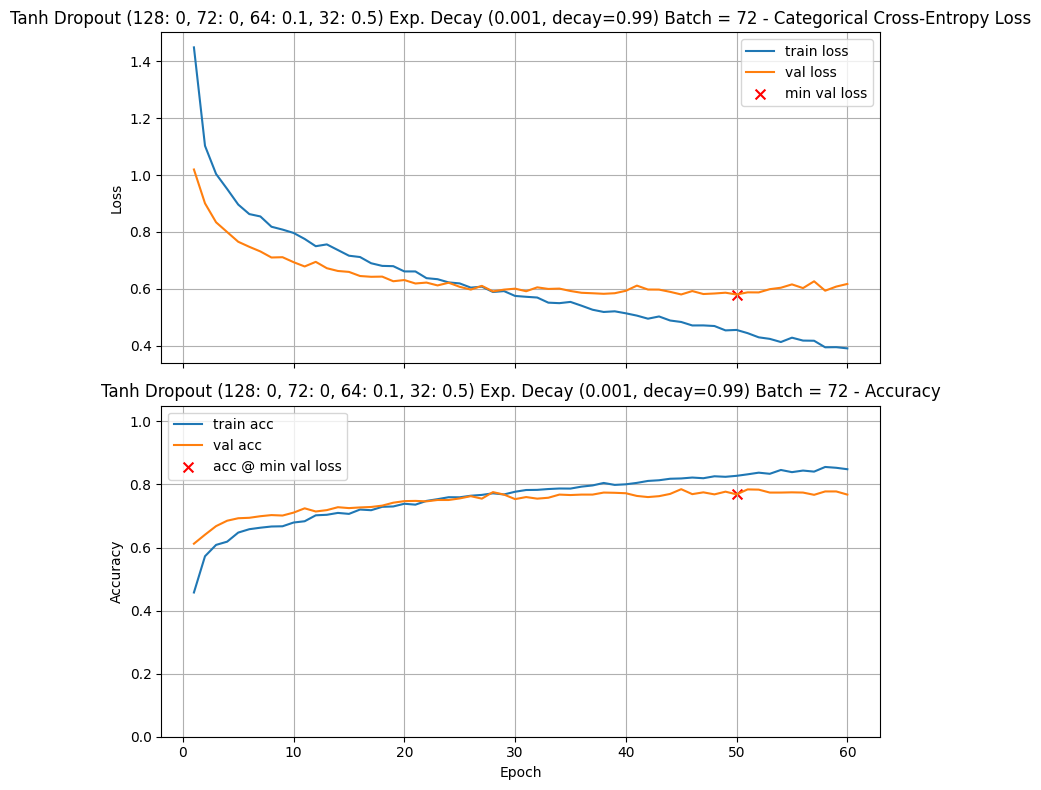

Final Training Loss:            0.3912
Final Training Accuracy:        0.8483
Final Validation Loss:          0.6174
Final Validation Accuracy:      0.7679
Minimum Validation Loss:        0.5803 (Epoch 50)
Validation Accuracy @ Min Loss: 0.7686

Test Loss: 0.5895
Test Accuracy: 0.7664

Validation-Test Gap (accuracy): 0.002143

Execution Time: 00:00:09


In [71]:
epochs = 500
batch_size = 72
steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
total_steps = epochs * steps_per_epoch
decay_rate = 0.99
initial_learning_rate = 1e-3

exp_decay = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=total_steps,
    decay_rate=decay_rate
)

train_and_test(model=build_model(X_train.shape[1], [ (128, 'tanh', 0, 0), (72, 'tanh', 0, 0), (64, 'tanh', 0, 0.1), (32, 'tanh', 0, 0.5)], n_classes),
               epochs=epochs,
               lr_schedule=exp_decay,
               optimizer='Adam',
               batch_size=batch_size,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title=f'Tanh Dropout (128: 0, 72: 0, 64: 0.1, 32: 0.5) Exp. Decay ({initial_learning_rate}, decay={decay_rate}) Batch = {batch_size}')


Tanh Dropout (128: 0, 64: 0, 32: 0.5) Exp. Decay (0.001, decay=0.99) Batch = 72



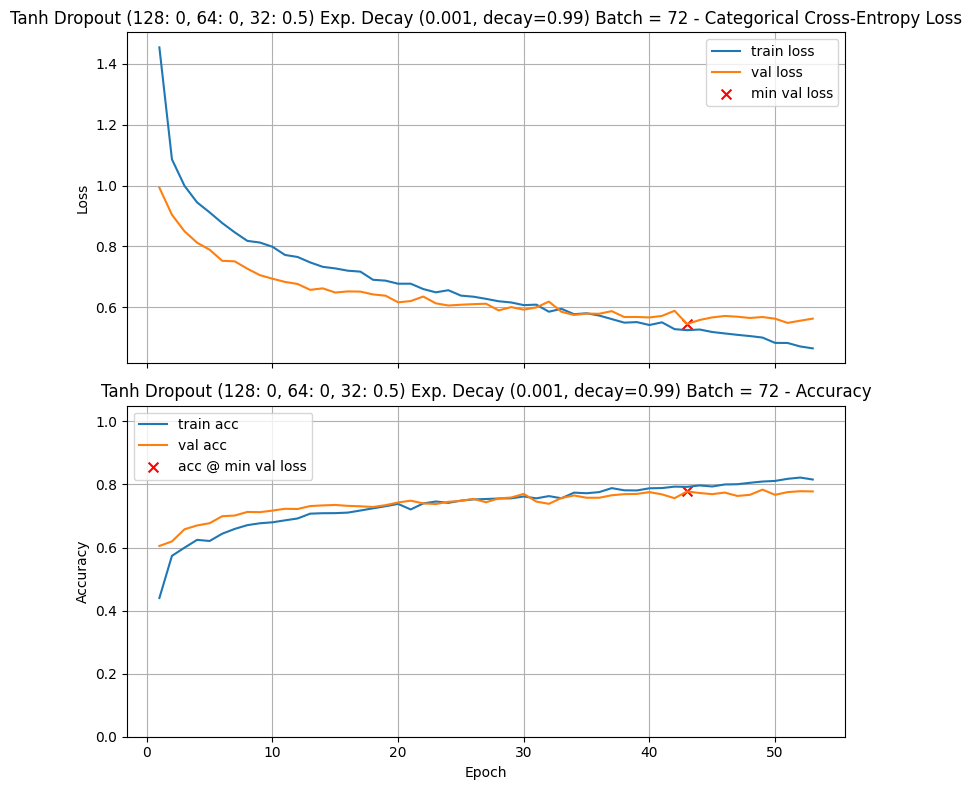

Final Training Loss:            0.4655
Final Training Accuracy:        0.8157
Final Validation Loss:          0.5631
Final Validation Accuracy:      0.7779
Minimum Validation Loss:        0.5452 (Epoch 43)
Validation Accuracy @ Min Loss: 0.7779

Test Loss: 0.5752
Test Accuracy: 0.7686

Validation-Test Gap (accuracy): 0.009286

Execution Time: 00:00:07


In [69]:
epochs = 500
batch_size = 72
steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
total_steps = epochs * steps_per_epoch
decay_rate = 0.99
initial_learning_rate = 1e-3

exp_decay = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=total_steps,
    decay_rate=decay_rate
)

train_and_test(model=build_model(X_train.shape[1], [ (128, 'tanh', 0, 0), (64, 'tanh', 0, 0), (32, 'tanh', 0, 0.5)], n_classes),
               epochs=epochs,
               lr_schedule=exp_decay,
               optimizer='Adam',
               batch_size=batch_size,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title=f'Tanh Dropout (128: 0, 64: 0, 32: 0.5) Exp. Decay ({initial_learning_rate}, decay={decay_rate}) Batch = {batch_size}')


Tanh Dropout (128: 0, 72: 0, 64: 0, 32: 0.5) Exp. Decay (0.001, decay=0.98) Batch = 64



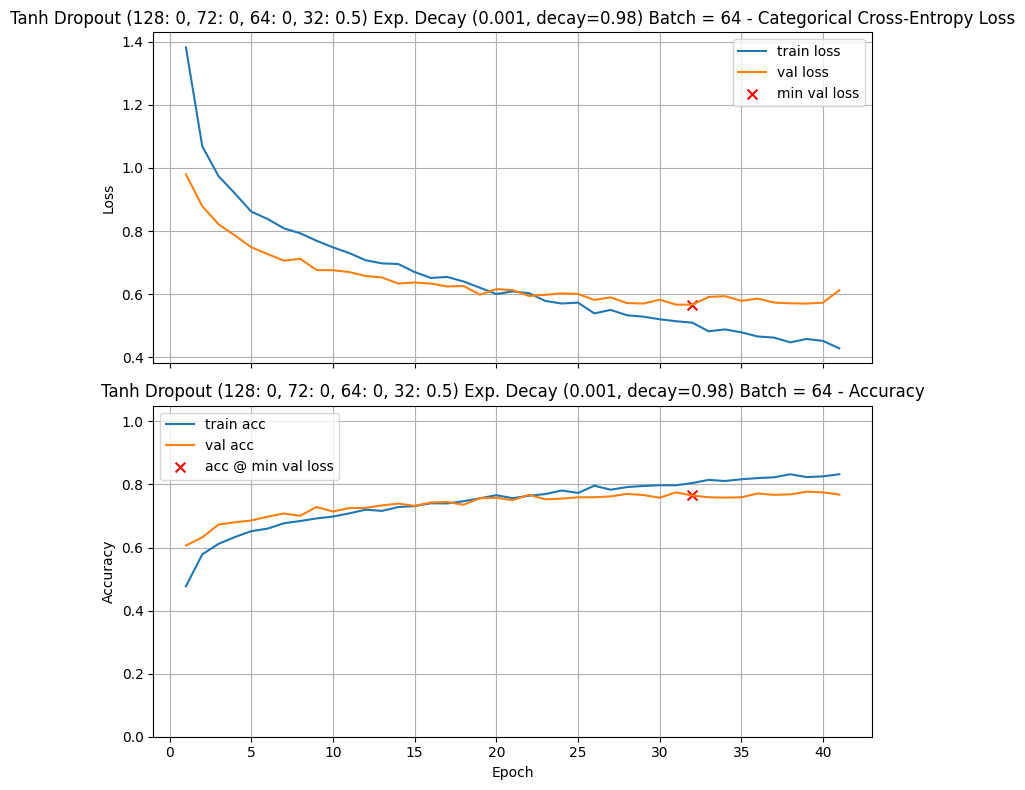

Final Training Loss:            0.4280
Final Training Accuracy:        0.8324
Final Validation Loss:          0.6125
Final Validation Accuracy:      0.7679
Minimum Validation Loss:        0.5667 (Epoch 32)
Validation Accuracy @ Min Loss: 0.7650

Test Loss: 0.5816
Test Accuracy: 0.7679

Validation-Test Gap (accuracy): 0.007143

Execution Time: 00:00:06


In [67]:
epochs = 500
batch_size = 64
steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
total_steps = epochs * steps_per_epoch
decay_rate = 0.98
initial_learning_rate = 1e-3

exp_decay = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=total_steps,
    decay_rate=decay_rate
)

train_and_test(model=build_model(X_train.shape[1], [ (128, 'tanh', 0, 0), (72, 'tanh', 0, 0), (64, 'tanh', 0, 0), (32, 'tanh', 0, 0.5)], n_classes),
               epochs=epochs,
               lr_schedule=exp_decay,
               optimizer='Adam',
               batch_size=batch_size,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title=f'Tanh Dropout (128: 0, 72: 0, 64: 0, 32: 0.5) Exp. Decay ({initial_learning_rate}, decay={decay_rate}) Batch = {batch_size}')


Tanh Dropout (128: 0, 72: 0, 64: 0, 32: 0.5) Exp. Decay (0.001, decay=0.99) Batch = 64



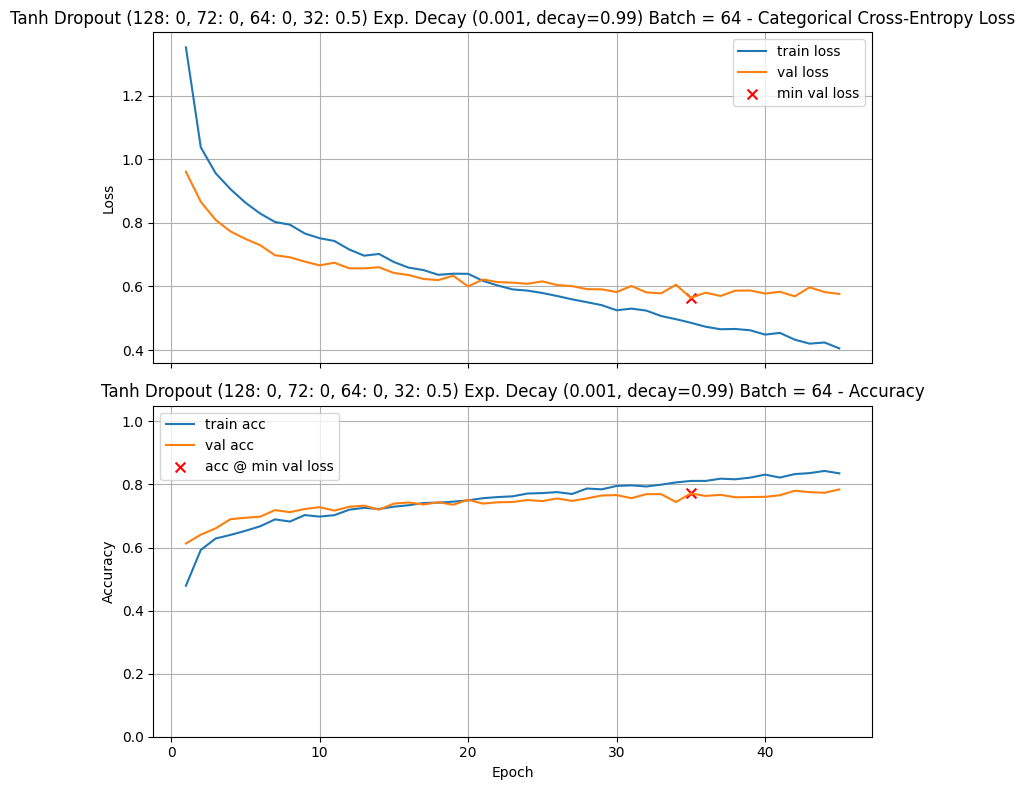

Final Training Loss:            0.4052
Final Training Accuracy:        0.8352
Final Validation Loss:          0.5764
Final Validation Accuracy:      0.7843
Minimum Validation Loss:        0.5639 (Epoch 35)
Validation Accuracy @ Min Loss: 0.7714

Test Loss: 0.5768
Test Accuracy: 0.7693

Validation-Test Gap (accuracy): 0.002143

Execution Time: 00:00:07


In [66]:
epochs = 500
batch_size = 64
steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
total_steps = epochs * steps_per_epoch
decay_rate = 0.99
initial_learning_rate = 1e-3

exp_decay = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=total_steps,
    decay_rate=decay_rate
)

train_and_test(model=build_model(X_train.shape[1], [ (128, 'tanh', 0, 0), (72, 'tanh', 0, 0), (64, 'tanh', 0, 0), (32, 'tanh', 0, 0.5)], n_classes),
               epochs=epochs,
               lr_schedule=exp_decay,
               optimizer='Adam',
               batch_size=batch_size,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title=f'Tanh Dropout (128: 0, 72: 0, 64: 0, 32: 0.5) Exp. Decay ({initial_learning_rate}, decay={decay_rate}) Batch = {batch_size}')


Tanh Dropout (128: 0, 72: 0, 64: 0, 32: 0.5) Exp. Decay (0.001, decay=0.999) Batch = 64



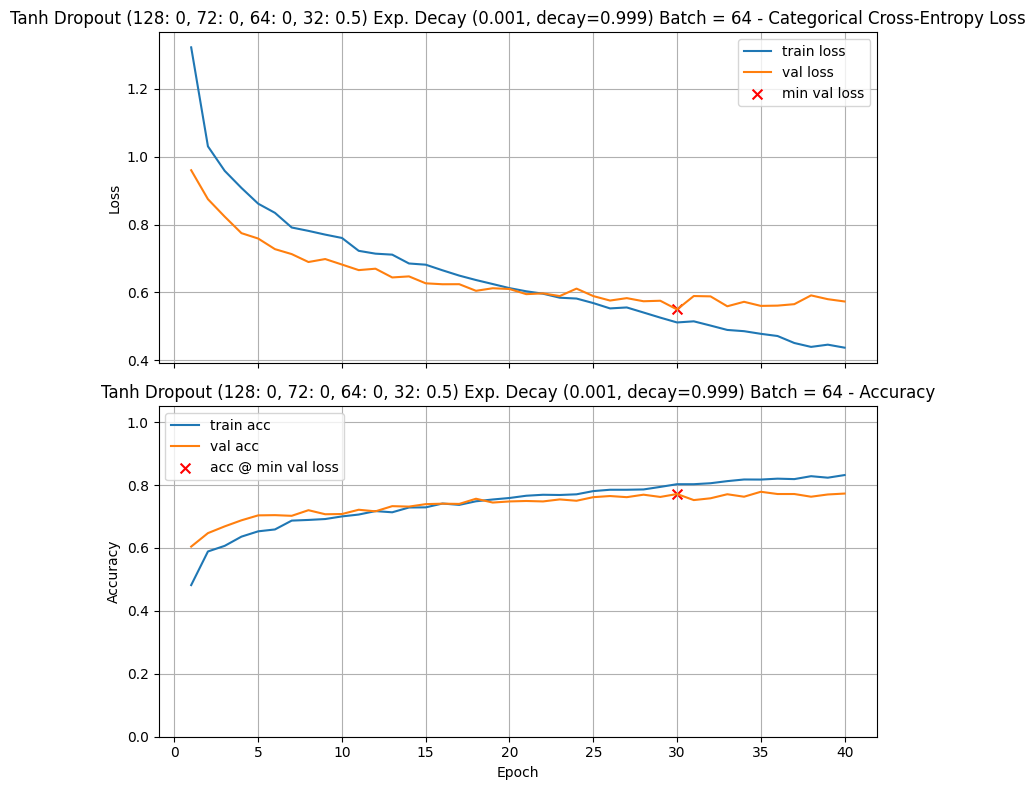

Final Training Loss:            0.4369
Final Training Accuracy:        0.8317
Final Validation Loss:          0.5731
Final Validation Accuracy:      0.7729
Minimum Validation Loss:        0.5496 (Epoch 30)
Validation Accuracy @ Min Loss: 0.7714

Test Loss: 0.6004
Test Accuracy: 0.7507

Validation-Test Gap (accuracy): 0.020714

Execution Time: 00:00:06


In [65]:
epochs = 500
batch_size = 64
steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
total_steps = epochs * steps_per_epoch
decay_rate = 0.999
initial_learning_rate = 1e-3

exp_decay = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=total_steps,
    decay_rate=decay_rate
)

train_and_test(model=build_model(X_train.shape[1], [ (128, 'tanh', 0, 0), (72, 'tanh', 0, 0), (64, 'tanh', 0, 0), (32, 'tanh', 0, 0.5)], n_classes),
               epochs=epochs,
               lr_schedule=exp_decay,
               optimizer='Adam',
               batch_size=batch_size,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title=f'Tanh Dropout (128: 0, 72: 0, 64: 0, 32: 0.5) Exp. Decay ({initial_learning_rate}, decay={decay_rate}) Batch = {batch_size}')


Tanh Dropout (72: 0, 64: 0, 32: 0.5) Exp. Decay (0.001, decay=0.999) Batch = 32



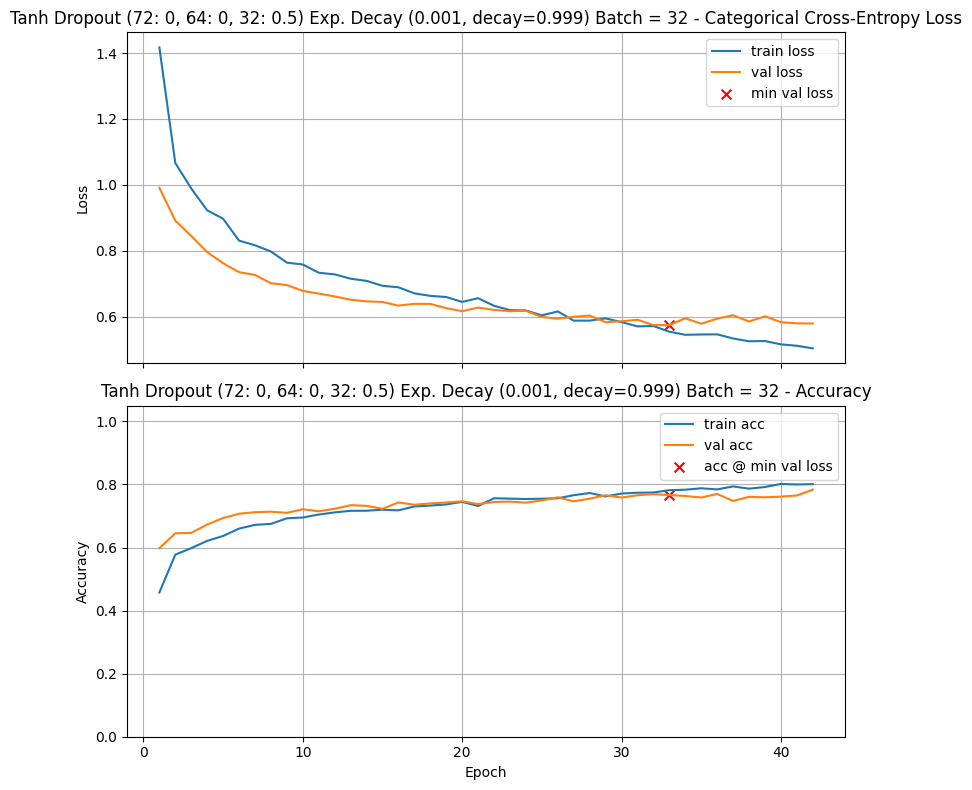

Final Training Loss:            0.5034
Final Training Accuracy:        0.8010
Final Validation Loss:          0.5788
Final Validation Accuracy:      0.7836
Minimum Validation Loss:        0.5740 (Epoch 33)
Validation Accuracy @ Min Loss: 0.7664

Test Loss: 0.6187
Test Accuracy: 0.7421

Validation-Test Gap (accuracy): 0.027143

Execution Time: 00:00:09


In [64]:
epochs = 500
batch_size = 32
steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
total_steps = epochs * steps_per_epoch
decay_rate = 0.999
initial_learning_rate = 1e-3

exp_decay = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=total_steps,
    decay_rate=decay_rate
)

train_and_test(model=build_model(X_train.shape[1], [ (72, 'tanh', 0, 0), (64, 'tanh', 0, 0), (32, 'tanh', 0, 0.5)], n_classes),
               epochs=epochs,
               lr_schedule=exp_decay,
               optimizer='Adam',
               batch_size=batch_size,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title=f'Tanh Dropout (72: 0, 64: 0, 32: 0.5) Exp. Decay ({initial_learning_rate}, decay={decay_rate}) Batch = {batch_size}')


Tanh Dropout (72: 0, 64: 0, 32: 0.5) Exp. Decay (0.001, decay=0.999) Batch = 64



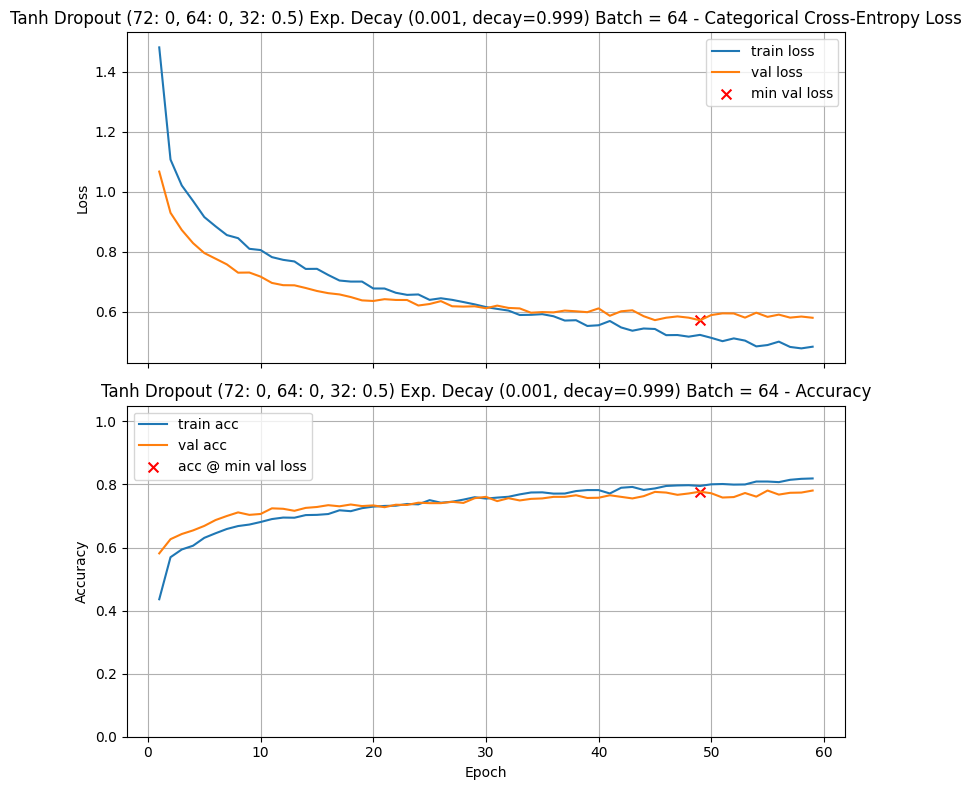

Final Training Loss:            0.4843
Final Training Accuracy:        0.8190
Final Validation Loss:          0.5805
Final Validation Accuracy:      0.7807
Minimum Validation Loss:        0.5722 (Epoch 49)
Validation Accuracy @ Min Loss: 0.7771

Test Loss: 0.6034
Test Accuracy: 0.7579

Validation-Test Gap (accuracy): 0.019286

Execution Time: 00:00:08


In [63]:
epochs = 500
batch_size = 64
steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
total_steps = epochs * steps_per_epoch
decay_rate = 0.999
initial_learning_rate = 1e-3

exp_decay = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=total_steps,
    decay_rate=decay_rate
)

train_and_test(model=build_model(X_train.shape[1], [ (72, 'tanh', 0, 0), (64, 'tanh', 0, 0), (32, 'tanh', 0, 0.5)], n_classes),
               epochs=epochs,
               lr_schedule=exp_decay,
               optimizer='Adam',
               batch_size=batch_size,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title=f'Tanh Dropout (72: 0, 64: 0, 32: 0.5) Exp. Decay ({initial_learning_rate}, decay={decay_rate}) Batch = {batch_size}')


Tanh Dropout (64: 0, 32: 0.5) L2: (1e-4, 1e-3) Exp. Decay (0.001, decay=0.999) Batch = 64



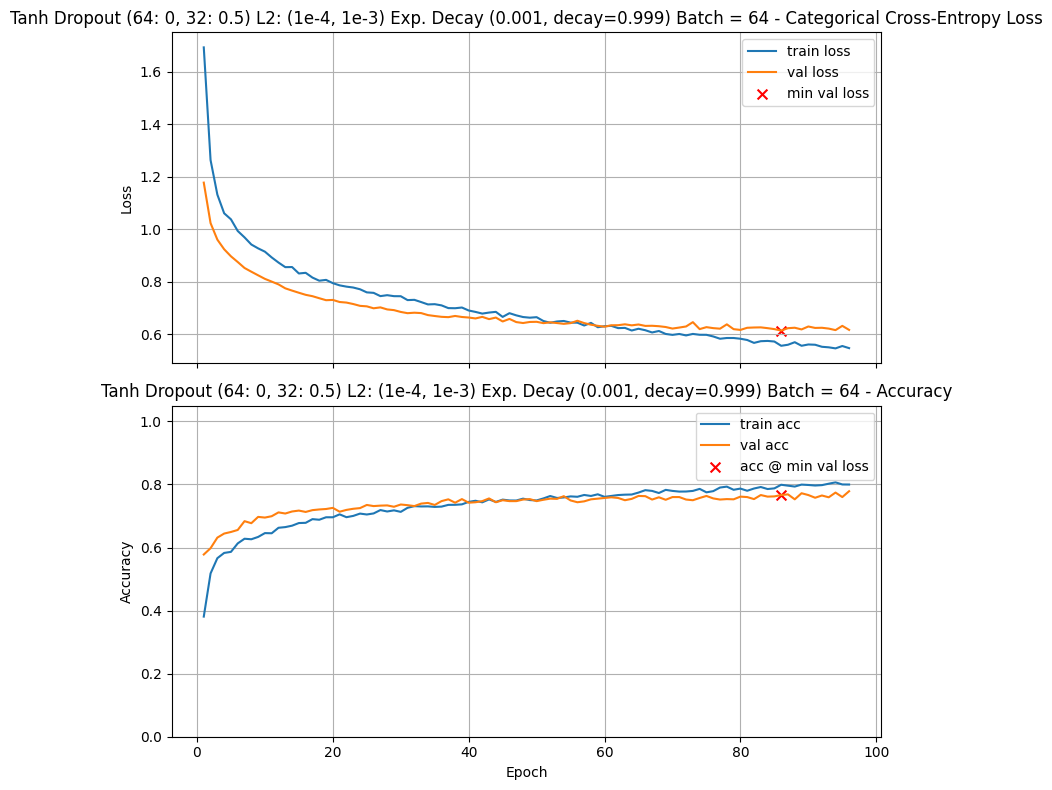

Final Training Loss:            0.5475
Final Training Accuracy:        0.7998
Final Validation Loss:          0.6170
Final Validation Accuracy:      0.7786
Minimum Validation Loss:        0.6144 (Epoch 86)
Validation Accuracy @ Min Loss: 0.7664

Test Loss: 0.6630
Test Accuracy: 0.7536

Validation-Test Gap (accuracy): 0.012857

Execution Time: 00:00:11


In [62]:
epochs = 500
batch_size = 64
steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
total_steps = epochs * steps_per_epoch
decay_rate = 0.999
initial_learning_rate = 1e-3

exp_decay = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=total_steps,
    decay_rate=decay_rate
)

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 1e-4, 0), (32, 'tanh', 1e-3, 0.5)], n_classes),
               epochs=epochs,
               lr_schedule=exp_decay,
               optimizer='Adam',
               batch_size=batch_size,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title=f'Tanh Dropout (64: 0, 32: 0.5) L2: (1e-4, 1e-3) Exp. Decay ({initial_learning_rate}, decay={decay_rate}) Batch = {batch_size}')


Tanh Dropout (64: 0, 32: 0.5) L2: 1e-3 Exp. Decay (0.01, decay=0.999) Batch = 64



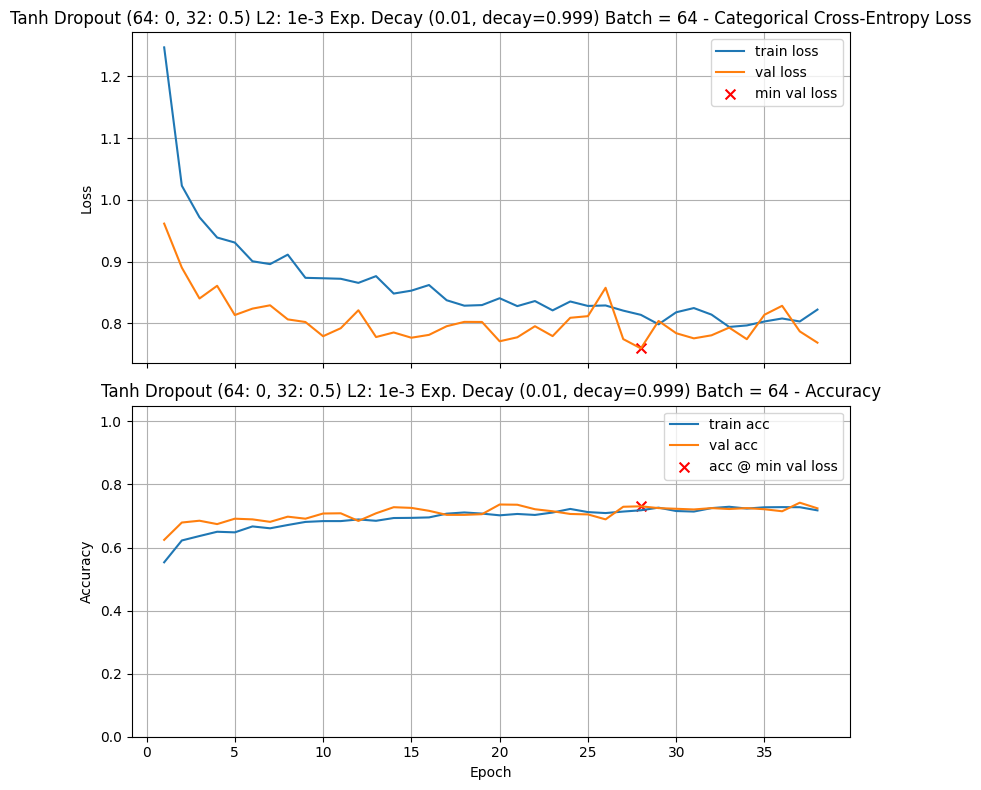

Final Training Loss:            0.8224
Final Training Accuracy:        0.7179
Final Validation Loss:          0.7689
Final Validation Accuracy:      0.7243
Minimum Validation Loss:        0.7596 (Epoch 28)
Validation Accuracy @ Min Loss: 0.7307

Test Loss: 0.7832
Test Accuracy: 0.7257

Validation-Test Gap (accuracy): 0.005000

Execution Time: 00:00:05


In [61]:
epochs = 500
batch_size = 64
steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
total_steps = epochs * steps_per_epoch
decay_rate = 0.999
initial_learning_rate = 1e-2

exp_decay = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=total_steps,
    decay_rate=decay_rate
)

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 1e-3, 0), (32, 'tanh', 1e-3, 0.5)], n_classes),
               epochs=epochs,
               lr_schedule=exp_decay,
               optimizer='Adam',
               batch_size=batch_size,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title=f'Tanh Dropout (64: 0, 32: 0.5) L2: 1e-3 Exp. Decay ({initial_learning_rate}, decay={decay_rate}) Batch = {batch_size}')


Tanh Dropout (64: 0, 32: 0.5) L2: 1e-3 Exp. Decay (0.001, decay=0.999) Batch = 64



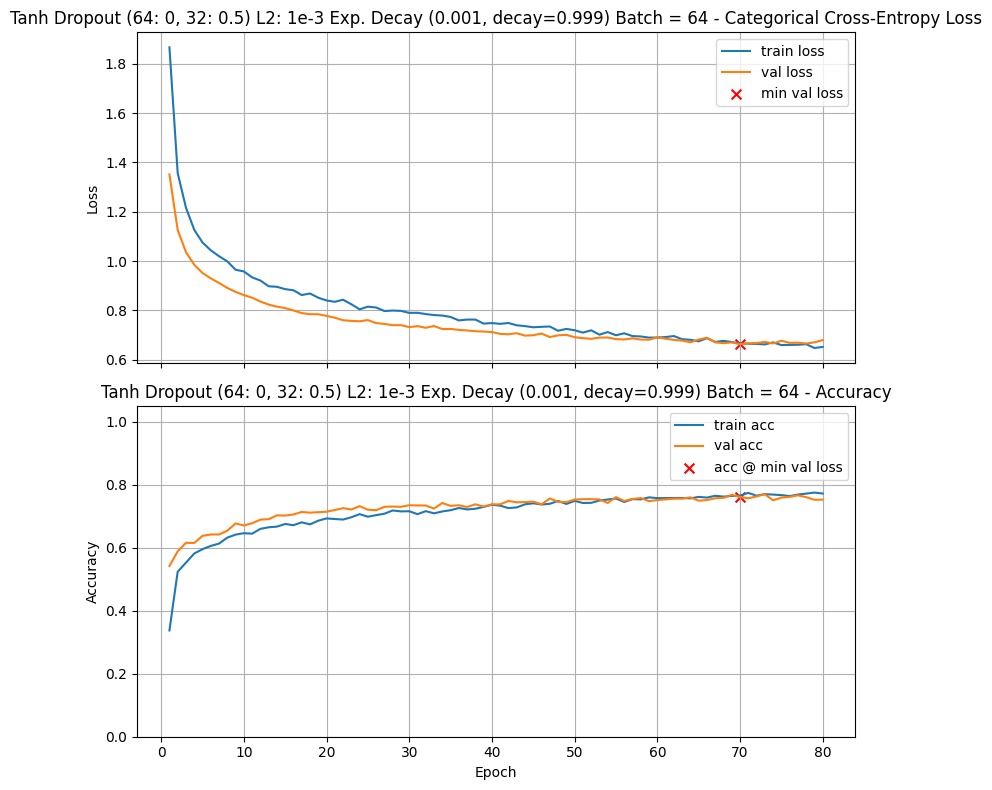

Final Training Loss:            0.6518
Final Training Accuracy:        0.7721
Final Validation Loss:          0.6793
Final Validation Accuracy:      0.7529
Minimum Validation Loss:        0.6626 (Epoch 70)
Validation Accuracy @ Min Loss: 0.7614

Test Loss: 0.7000
Test Accuracy: 0.7571

Validation-Test Gap (accuracy): 0.004286

Execution Time: 00:00:10


In [60]:
epochs = 500
batch_size = 64
steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
total_steps = epochs * steps_per_epoch
decay_rate = 0.999
initial_learning_rate = 1e-3

exp_decay = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=total_steps,
    decay_rate=decay_rate
)

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 1e-3, 0), (32, 'tanh', 1e-3, 0.5)], n_classes),
               epochs=epochs,
               lr_schedule=exp_decay,
               optimizer='Adam',
               batch_size=batch_size,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title=f'Tanh Dropout (64: 0, 32: 0.5) L2: 1e-3 Exp. Decay ({initial_learning_rate}, decay={decay_rate}) Batch = {batch_size}')


Tanh Dropout (64: 0, 32: 0.5) L2: 1e-3 Exp. Decay (0.001, decay=0.999) Batch = 32



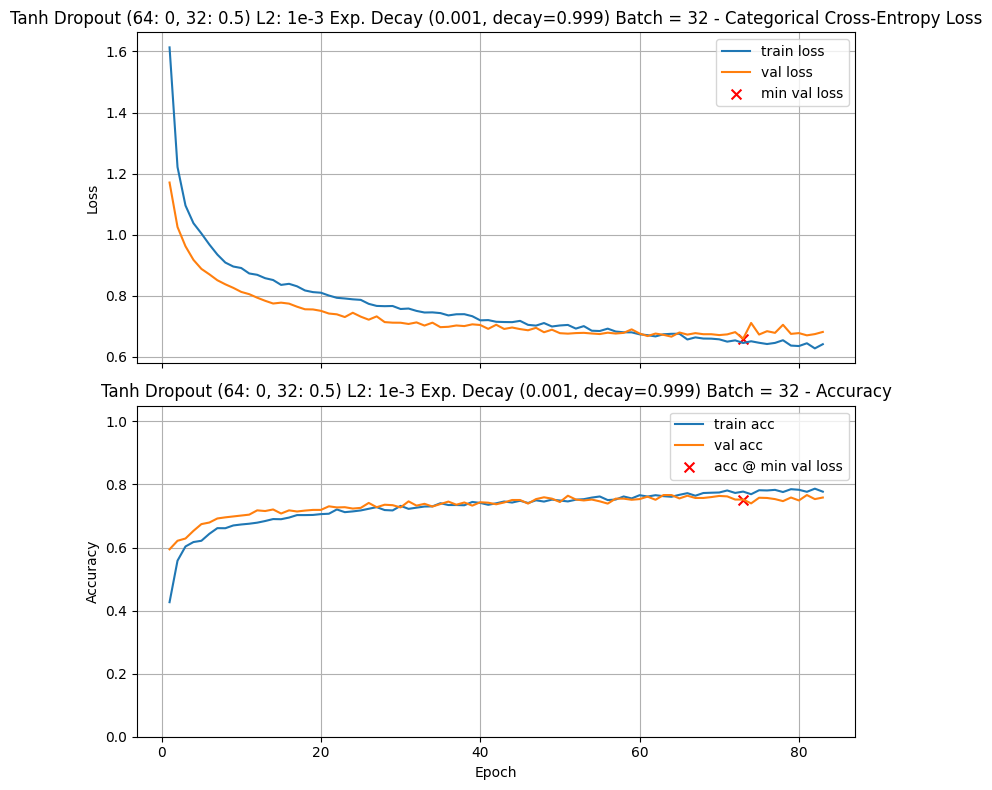

Final Training Loss:            0.6408
Final Training Accuracy:        0.7771
Final Validation Loss:          0.6809
Final Validation Accuracy:      0.7586
Minimum Validation Loss:        0.6588 (Epoch 73)
Validation Accuracy @ Min Loss: 0.7521

Test Loss: 0.7093
Test Accuracy: 0.7543

Validation-Test Gap (accuracy): 0.002143

Execution Time: 00:00:16


In [59]:
epochs = 500
batch_size = 32
steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
total_steps = epochs * steps_per_epoch
decay_rate = 0.999
initial_learning_rate = 1e-3

exp_decay = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=total_steps,
    decay_rate=decay_rate
)

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 1e-3, 0), (32, 'tanh', 1e-3, 0.5)], n_classes),
               epochs=epochs,
               lr_schedule=exp_decay,
               optimizer='Adam',
               batch_size=batch_size,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title=f'Tanh Dropout (64: 0, 32: 0.5) L2: 1e-3 Exp. Decay ({initial_learning_rate}, decay={decay_rate}) Batch = {batch_size}')


Tanh Dropout (64: 0, 32: 0.5) Exp. Decay (0.01, decay=0.999) Batch = 16



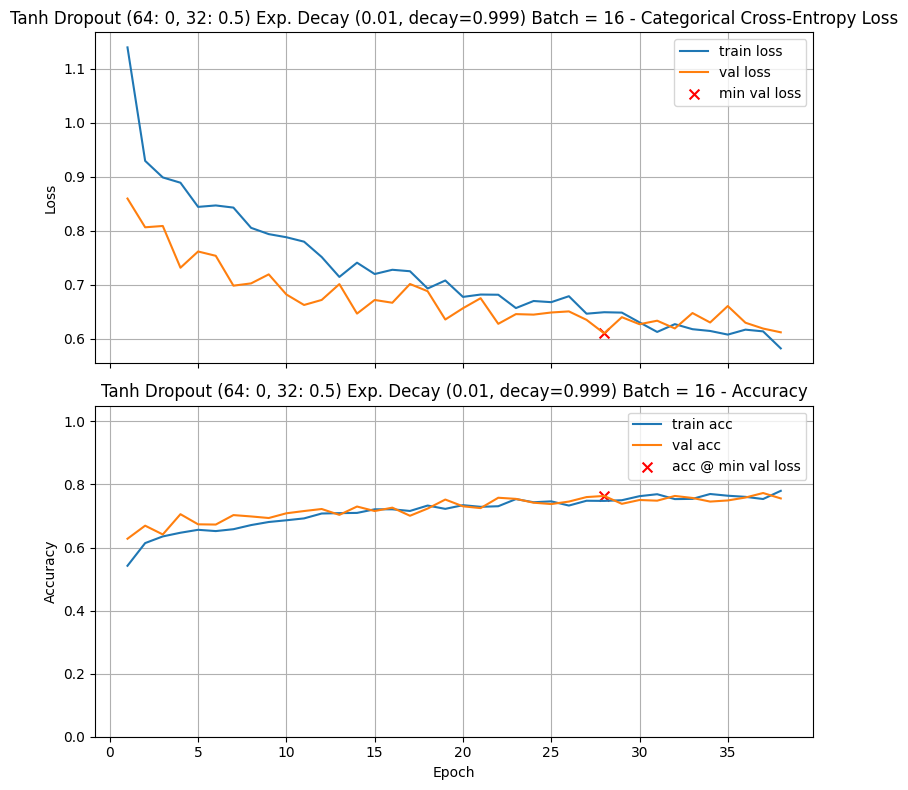

Final Training Loss:            0.5824
Final Training Accuracy:        0.7798
Final Validation Loss:          0.6122
Final Validation Accuracy:      0.7557
Minimum Validation Loss:        0.6103 (Epoch 28)
Validation Accuracy @ Min Loss: 0.7636

Test Loss: 0.6448
Test Accuracy: 0.7450

Validation-Test Gap (accuracy): 0.018571

Execution Time: 00:00:14


In [58]:
epochs = 500
batch_size = 16
steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
total_steps = epochs * steps_per_epoch
decay_rate = 0.999
initial_learning_rate = 1e-2

exp_decay = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=total_steps,
    decay_rate=decay_rate
)

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 0, 0), (32, 'tanh', 0, 0.5)], n_classes),
               epochs=epochs,
               lr_schedule=exp_decay,
               optimizer='Adam',
               batch_size=batch_size,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title=f'Tanh Dropout (64: 0, 32: 0.5) Exp. Decay ({initial_learning_rate}, decay={decay_rate}) Batch = {batch_size}')


Tanh Dropout (64: 0, 32: 0.5) Exp. Decay (0.001, decay=0.999) Batch = 16



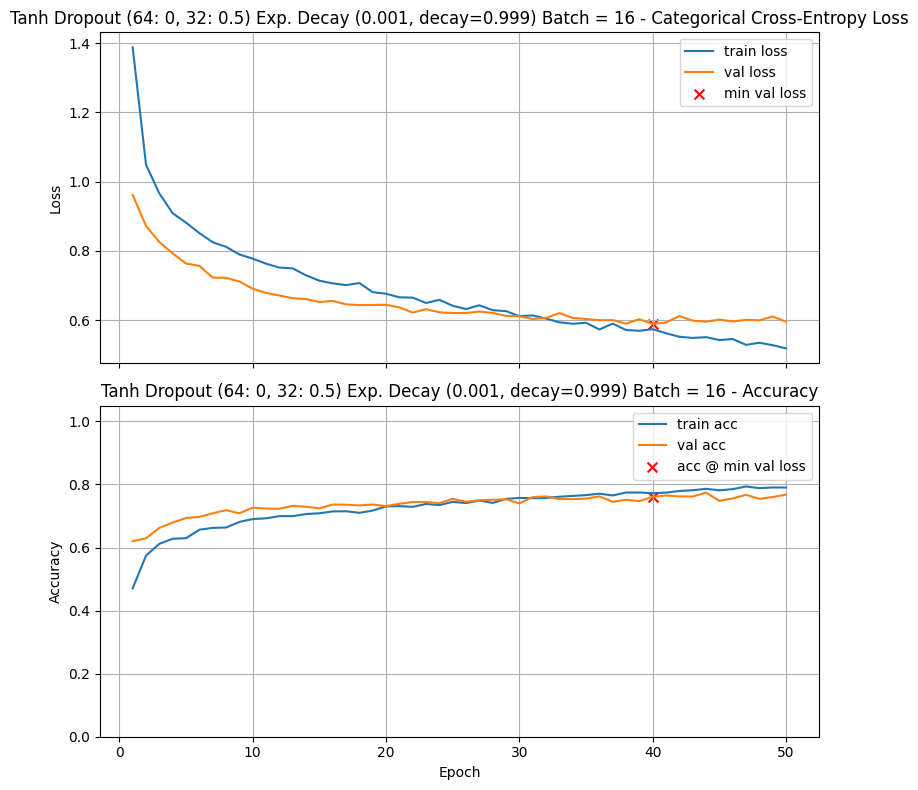

Final Training Loss:            0.5184
Final Training Accuracy:        0.7902
Final Validation Loss:          0.5955
Final Validation Accuracy:      0.7679
Minimum Validation Loss:        0.5889 (Epoch 40)
Validation Accuracy @ Min Loss: 0.7607

Test Loss: 0.6156
Test Accuracy: 0.7543

Validation-Test Gap (accuracy): 0.006429

Execution Time: 00:00:17


In [57]:
epochs = 500
batch_size = 16
steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
total_steps = epochs * steps_per_epoch
decay_rate = 0.999
initial_learning_rate = 1e-3

exp_decay = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=total_steps,
    decay_rate=decay_rate
)

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 0, 0), (32, 'tanh', 0, 0.5)], n_classes),
               epochs=epochs,
               lr_schedule=exp_decay,
               optimizer='Adam',
               batch_size=batch_size,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title=f'Tanh Dropout (64: 0, 32: 0.5) Exp. Decay ({initial_learning_rate}, decay={decay_rate}) Batch = {batch_size}')


Tanh Dropout (64: 0, 32: 0.5) Exp. Decay (0.001, decay=0.9999) Batch = 32



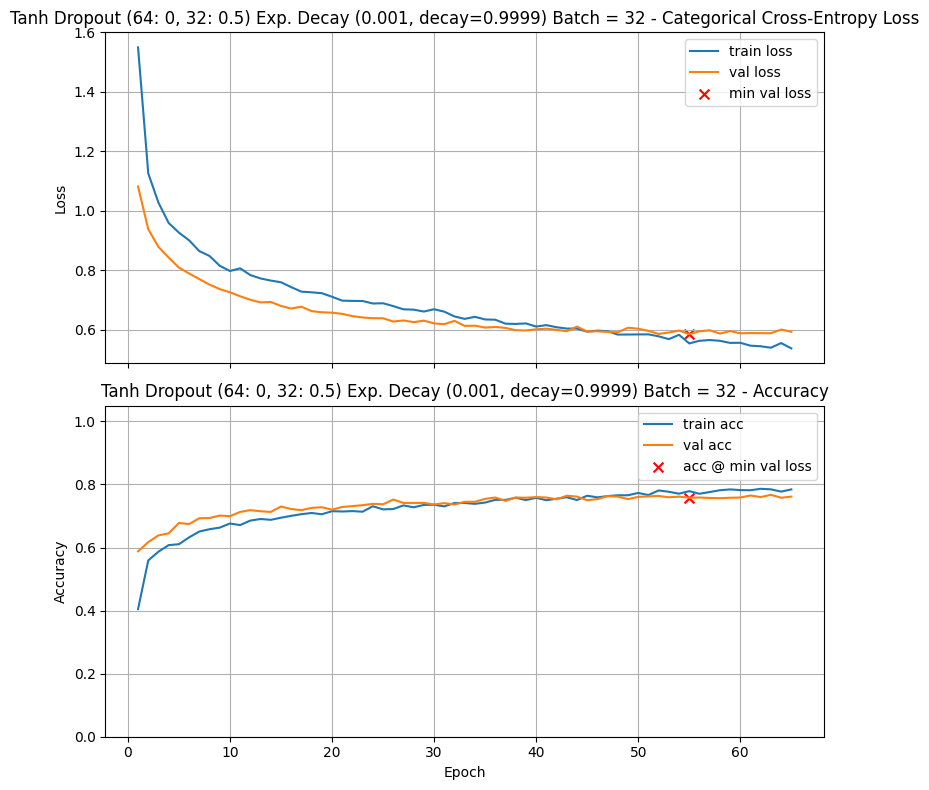

Final Training Loss:            0.5366
Final Training Accuracy:        0.7843
Final Validation Loss:          0.5926
Final Validation Accuracy:      0.7614
Minimum Validation Loss:        0.5841 (Epoch 55)
Validation Accuracy @ Min Loss: 0.7579

Test Loss: 0.6199
Test Accuracy: 0.7493

Validation-Test Gap (accuracy): 0.008571

Execution Time: 00:00:13


In [56]:
epochs = 500
batch_size = 32
steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
total_steps = epochs * steps_per_epoch
decay_rate = 0.9999
initial_learning_rate = 1e-3

exp_decay = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=total_steps,
    decay_rate=decay_rate
)

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 0, 0), (32, 'tanh', 0, 0.5)], n_classes),
               epochs=epochs,
               lr_schedule=exp_decay,
               optimizer='Adam',
               batch_size=batch_size,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title=f'Tanh Dropout (64: 0, 32: 0.5) Exp. Decay ({initial_learning_rate}, decay={decay_rate}) Batch = {batch_size}')


Tanh Dropout (64: 0, 32: 0.5) Exp. Decay (0.001, decay=0.999) Batch = 32



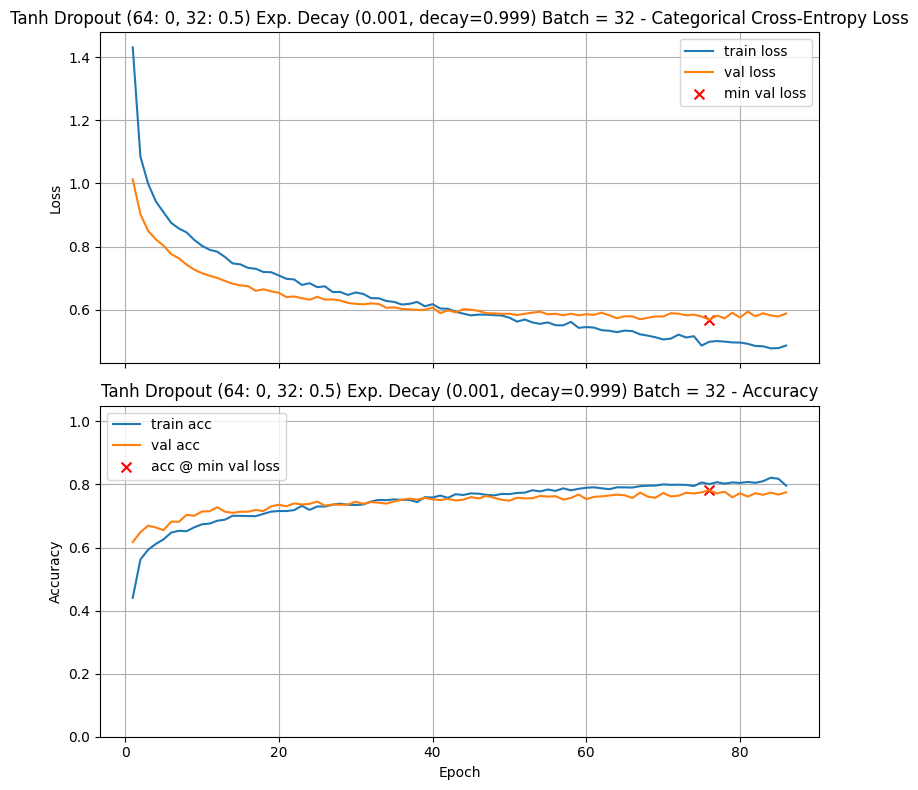

Final Training Loss:            0.4869
Final Training Accuracy:        0.7962
Final Validation Loss:          0.5884
Final Validation Accuracy:      0.7750
Minimum Validation Loss:        0.5688 (Epoch 76)
Validation Accuracy @ Min Loss: 0.7821

Test Loss: 0.6156
Test Accuracy: 0.7629

Validation-Test Gap (accuracy): 0.019286

Execution Time: 00:00:16


In [55]:
epochs = 500
batch_size = 32
steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
total_steps = epochs * steps_per_epoch
decay_rate = 0.999
initial_learning_rate = 1e-3

exp_decay = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=total_steps,
    decay_rate=decay_rate
)

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 0, 0), (32, 'tanh', 0, 0.5)], n_classes),
               epochs=epochs,
               lr_schedule=exp_decay,
               optimizer='Adam',
               batch_size=batch_size,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title=f'Tanh Dropout (64: 0, 32: 0.5) Exp. Decay ({initial_learning_rate}, decay={decay_rate}) Batch = {batch_size}')


Tanh Dropout (64: 0, 32: 0.5) Exp. Decay (0.001, decay=0.98) Batch = 32



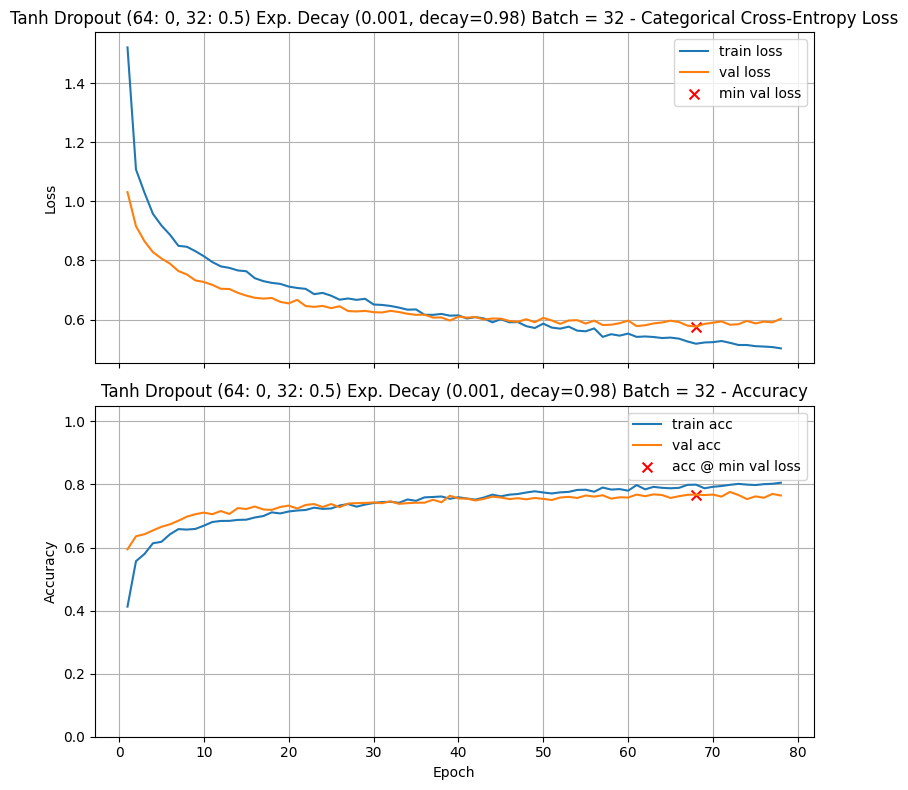

Final Training Loss:            0.5024
Final Training Accuracy:        0.8055
Final Validation Loss:          0.6026
Final Validation Accuracy:      0.7650
Minimum Validation Loss:        0.5762 (Epoch 68)
Validation Accuracy @ Min Loss: 0.7679

Test Loss: 0.6195
Test Accuracy: 0.7507

Validation-Test Gap (accuracy): 0.017143

Execution Time: 00:00:15


In [54]:
epochs = 500
batch_size = 32
steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
total_steps = epochs * steps_per_epoch
decay_rate = 0.98
initial_learning_rate = 1e-3

exp_decay = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=total_steps,
    decay_rate=decay_rate
)

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 0, 0), (32, 'tanh', 0, 0.5)], n_classes),
               epochs=epochs,
               lr_schedule=exp_decay,
               optimizer='Adam',
               batch_size=batch_size,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title=f'Tanh Dropout (64: 0, 32: 0.5) Exp. Decay ({initial_learning_rate}, decay={decay_rate}) Batch = {batch_size}')


Tanh Dropout (64: 0, 32: 0.5) Exp. Decay (0.001, decay=0.99) Batch = 32



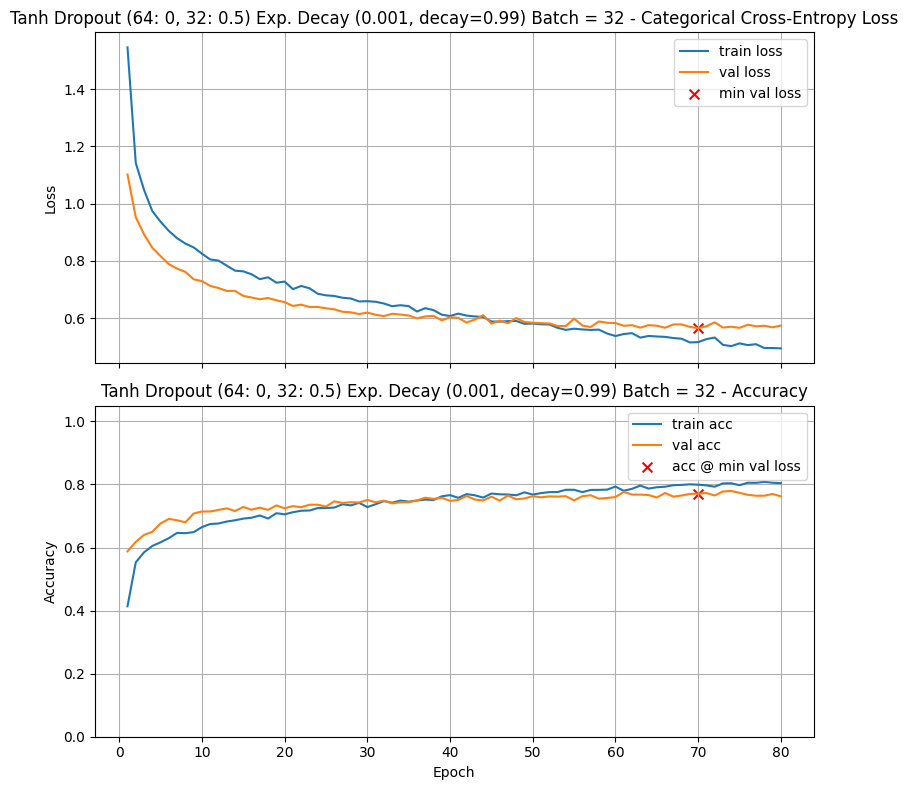

Final Training Loss:            0.4942
Final Training Accuracy:        0.8040
Final Validation Loss:          0.5739
Final Validation Accuracy:      0.7621
Minimum Validation Loss:        0.5649 (Epoch 70)
Validation Accuracy @ Min Loss: 0.7707

Test Loss: 0.5942
Test Accuracy: 0.7721

Validation-Test Gap (accuracy): 0.001429

Execution Time: 00:00:15


In [53]:
epochs = 500
batch_size = 32
steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
total_steps = epochs * steps_per_epoch
decay_rate = 0.99
initial_learning_rate = 1e-3

exp_decay = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=total_steps,
    decay_rate=decay_rate
)

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 0, 0), (32, 'tanh', 0, 0.5)], n_classes),
               epochs=epochs,
               lr_schedule=exp_decay,
               optimizer='Adam',
               batch_size=batch_size,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title=f'Tanh Dropout (64: 0, 32: 0.5) Exp. Decay ({initial_learning_rate}, decay={decay_rate}) Batch = {batch_size}')


Tanh Dropout (64: 0, 32: 0.5) Exp. Decay (0.01, decay=0.99) Batch = 32



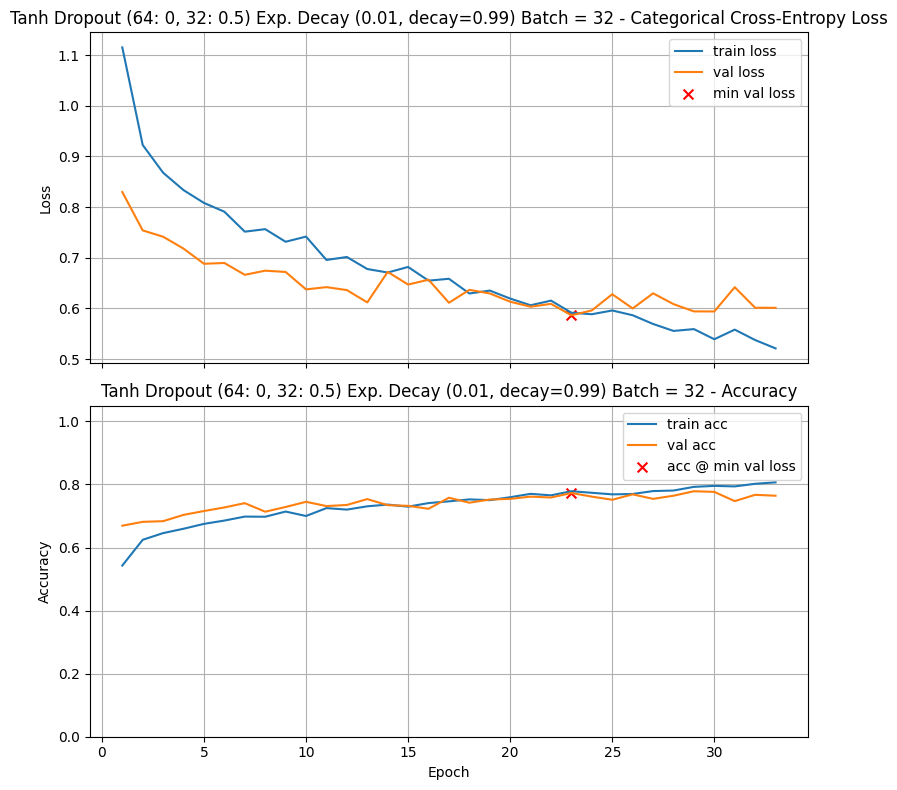

Final Training Loss:            0.5211
Final Training Accuracy:        0.8067
Final Validation Loss:          0.6012
Final Validation Accuracy:      0.7643
Minimum Validation Loss:        0.5864 (Epoch 23)
Validation Accuracy @ Min Loss: 0.7729

Test Loss: 0.6368
Test Accuracy: 0.7600

Validation-Test Gap (accuracy): 0.012857

Execution Time: 00:00:07


In [52]:
epochs = 500
batch_size = 32
steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
total_steps = epochs * steps_per_epoch
decay_rate = 0.99
initial_learning_rate = 1e-2

exp_decay = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=total_steps,
    decay_rate=decay_rate
)

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 0, 0), (32, 'tanh', 0, 0.5)], n_classes),
               epochs=epochs,
               lr_schedule=exp_decay,
               optimizer='Adam',
               batch_size=batch_size,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title=f'Tanh Dropout (64: 0, 32: 0.5) Exp. Decay ({initial_learning_rate}, decay={decay_rate}) Batch = {batch_size}')


Tanh Dropout (64: 0, 32: 0.5) Exp. Decay (0.01, decay=0.98)



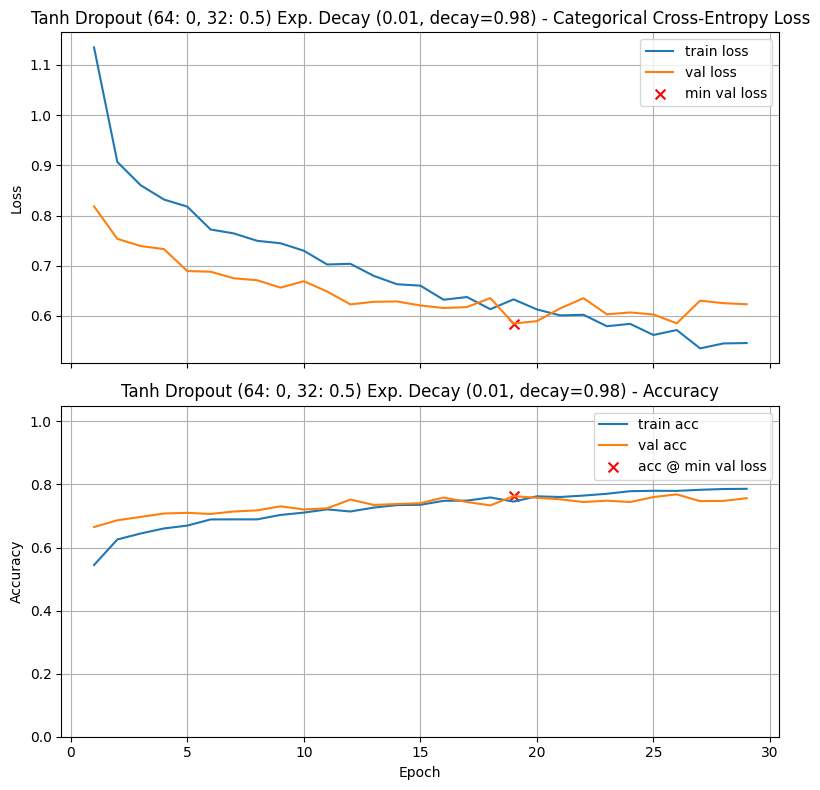

Final Training Loss:            0.5460
Final Training Accuracy:        0.7862
Final Validation Loss:          0.6232
Final Validation Accuracy:      0.7564
Minimum Validation Loss:        0.5848 (Epoch 19)
Validation Accuracy @ Min Loss: 0.7629

Test Loss: 0.6343
Test Accuracy: 0.7493

Validation-Test Gap (accuracy): 0.013571

Execution Time: 00:00:04


In [51]:
batch_size = 64
steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
total_steps = 500 * steps_per_epoch
decay_rate = 0.98
initial_learning_rate = 1e-2

exp_decay = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=total_steps,
    decay_rate=decay_rate
)

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 0, 0), (32, 'tanh', 0, 0.5)], n_classes),
               epochs=500,
               lr_schedule=exp_decay,
               optimizer='Adam',
               batch_size=64,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title=f'Tanh Dropout (64: 0, 32: 0.5) Exp. Decay ({initial_learning_rate}, decay={decay_rate})')


Tanh Dropout (64: 0, 32: 0.5) Exp. Decay (0.01, decay=0.99)



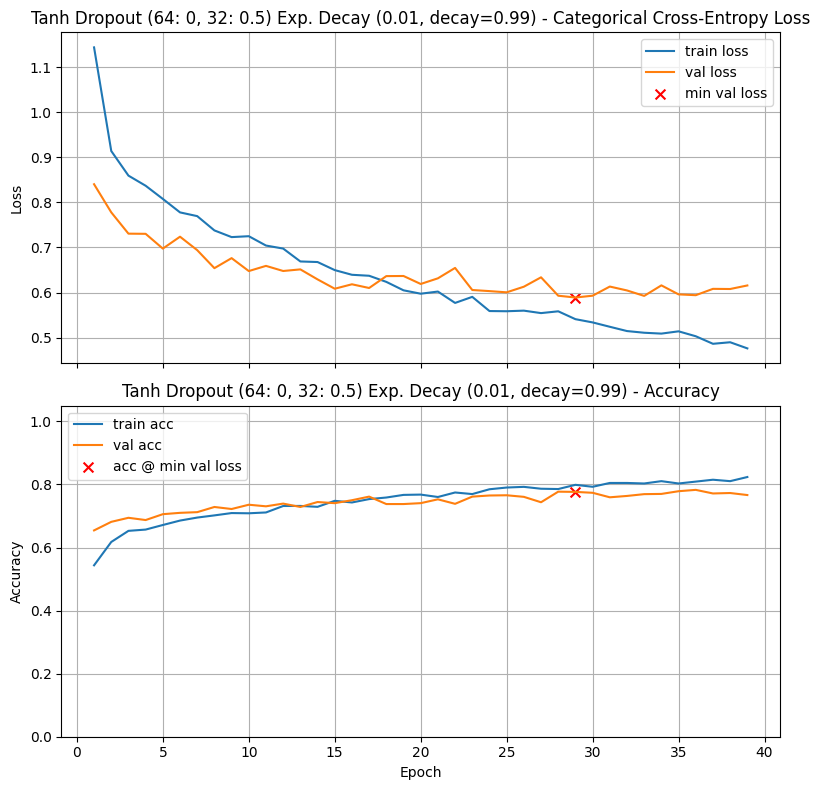

Final Training Loss:            0.4764
Final Training Accuracy:        0.8236
Final Validation Loss:          0.6159
Final Validation Accuracy:      0.7664
Minimum Validation Loss:        0.5891 (Epoch 29)
Validation Accuracy @ Min Loss: 0.7764

Test Loss: 0.6343
Test Accuracy: 0.7464

Validation-Test Gap (accuracy): 0.030000

Execution Time: 00:00:05


In [50]:
batch_size = 64
steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
total_steps = 500 * steps_per_epoch
decay_rate = 0.99
initial_learning_rate = 1e-2

exp_decay = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=total_steps,
    decay_rate=decay_rate
)

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 0, 0), (32, 'tanh', 0, 0.5)], n_classes),
               epochs=500,
               lr_schedule=exp_decay,
               optimizer='Adam',
               batch_size=64,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title=f'Tanh Dropout (64: 0, 32: 0.5) Exp. Decay ({initial_learning_rate}, decay={decay_rate})')


Tanh Dropout (64: 0, 32: 0.5) Exp. Decay (0.001, decay=0.95)



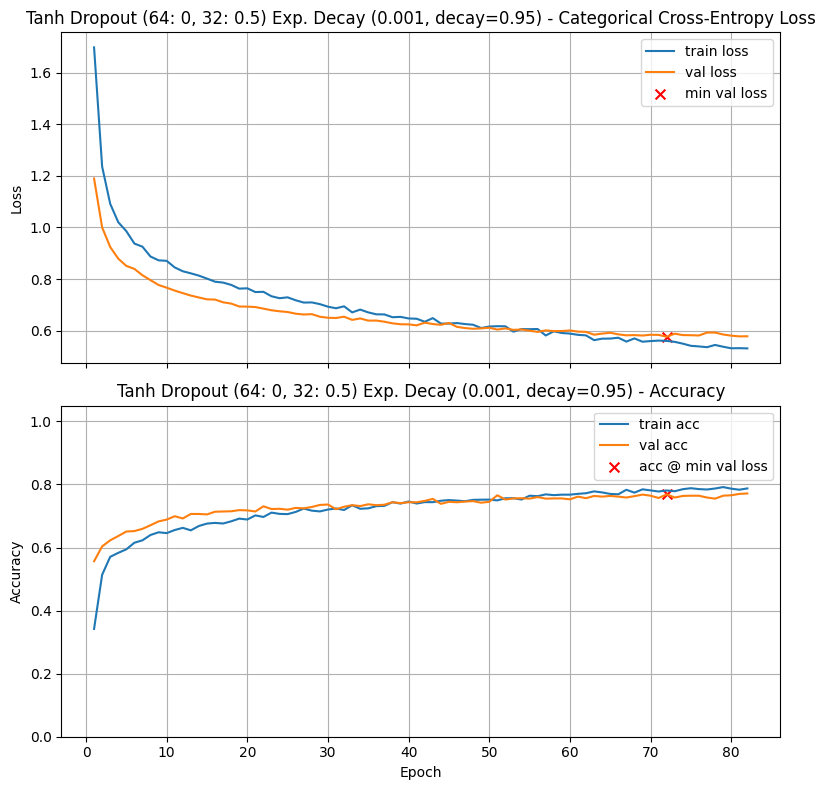

Final Training Loss:            0.5311
Final Training Accuracy:        0.7874
Final Validation Loss:          0.5780
Final Validation Accuracy:      0.7714
Minimum Validation Loss:        0.5762 (Epoch 72)
Validation Accuracy @ Min Loss: 0.7686

Test Loss: 0.6136
Test Accuracy: 0.7557

Validation-Test Gap (accuracy): 0.012857

Execution Time: 00:00:10


In [49]:
batch_size = 64
steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
total_steps = 500 * steps_per_epoch
decay_rate = 0.95
initial_learning_rate = 1e-3

exp_decay = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=total_steps,
    decay_rate=decay_rate
)

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 0, 0), (32, 'tanh', 0, 0.5)], n_classes),
               epochs=500,
               lr_schedule=exp_decay,
               optimizer='Adam',
               batch_size=64,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title=f'Tanh Dropout (64: 0, 32: 0.5) Exp. Decay ({initial_learning_rate}, decay={decay_rate})')


Tanh Dropout (64: 0, 32: 0.5) Exp. Decay (0.001, decay=0.99)



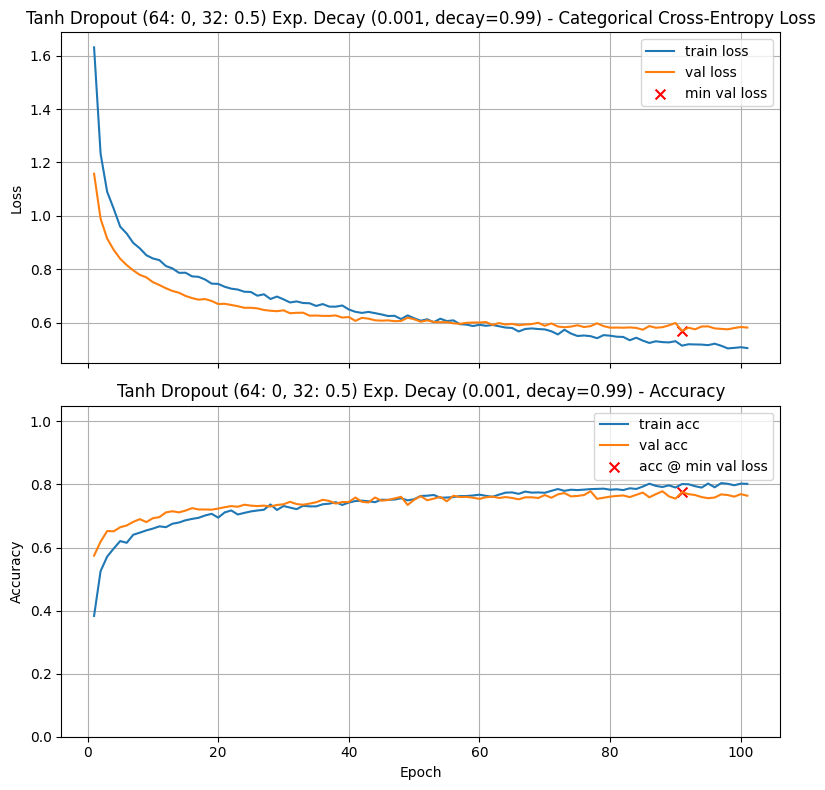

Final Training Loss:            0.5043
Final Training Accuracy:        0.8019
Final Validation Loss:          0.5811
Final Validation Accuracy:      0.7643
Minimum Validation Loss:        0.5688 (Epoch 91)
Validation Accuracy @ Min Loss: 0.7757

Test Loss: 0.6036
Test Accuracy: 0.7600

Validation-Test Gap (accuracy): 0.015714

Execution Time: 00:00:12


In [48]:
batch_size = 64
steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
total_steps = 500 * steps_per_epoch
decay_rate = 0.99
initial_learning_rate = 1e-3

exp_decay = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=total_steps,
    decay_rate=decay_rate
)

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 0, 0), (32, 'tanh', 0, 0.5)], n_classes),
               epochs=500,
               lr_schedule=exp_decay,
               optimizer='Adam',
               batch_size=64,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title=f'Tanh Dropout (64: 0, 32: 0.5) Exp. Decay ({initial_learning_rate}, decay={decay_rate})')


Tanh Dropout (64: 0, 32: 0.5) Exp. Decay (0.001, decay=0.96)



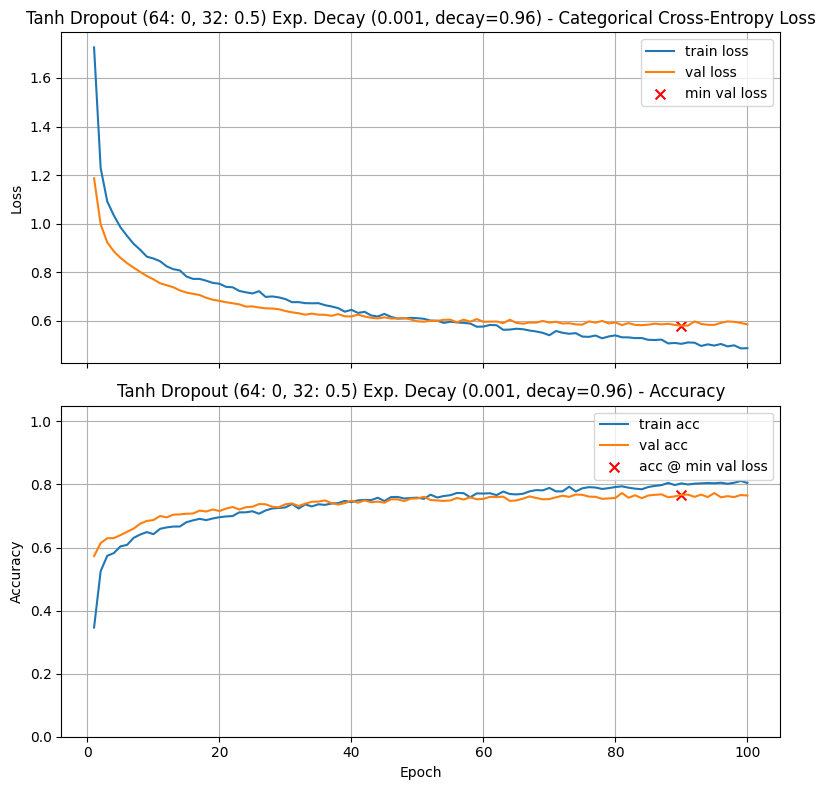

Final Training Loss:            0.4877
Final Training Accuracy:        0.8048
Final Validation Loss:          0.5857
Final Validation Accuracy:      0.7650
Minimum Validation Loss:        0.5804 (Epoch 90)
Validation Accuracy @ Min Loss: 0.7671

Test Loss: 0.6119
Test Accuracy: 0.7621

Validation-Test Gap (accuracy): 0.005000

Execution Time: 00:00:12


In [47]:
batch_size = 64
steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
total_steps = 500 * steps_per_epoch
decay_rate = 0.96
initial_learning_rate = 1e-3

exp_decay = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=total_steps,
    decay_rate=decay_rate
)

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 0, 0), (32, 'tanh', 0, 0.5)], n_classes),
               epochs=500,
               lr_schedule=exp_decay,
               optimizer='Adam',
               batch_size=64,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title=f'Tanh Dropout (64: 0, 32: 0.5) Exp. Decay ({initial_learning_rate}, decay={decay_rate})')


Tanh Dropout (64: 0, 32: 0.5) Cosine Decay (1e-3)



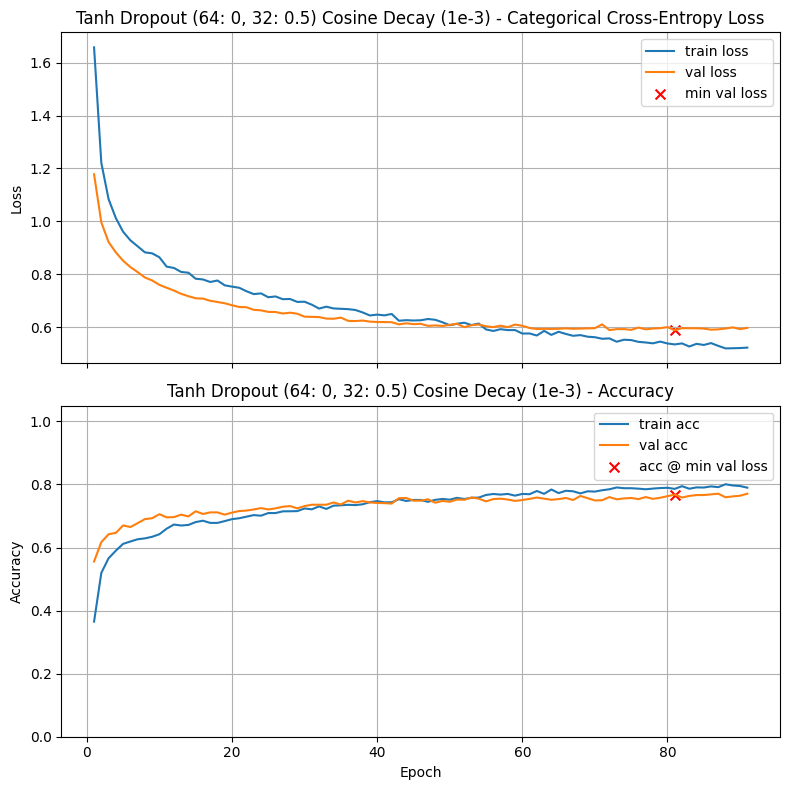

Final Training Loss:            0.5221
Final Training Accuracy:        0.7898
Final Validation Loss:          0.5966
Final Validation Accuracy:      0.7707
Minimum Validation Loss:        0.5875 (Epoch 81)
Validation Accuracy @ Min Loss: 0.7679

Test Loss: 0.6126
Test Accuracy: 0.7536

Validation-Test Gap (accuracy): 0.014286

Execution Time: 00:00:12


In [35]:
batch_size = 64
steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
total_steps = 500 * steps_per_epoch

cosine_decay = CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=total_steps,
    alpha=0.0
)

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 0, 0), (32, 'tanh', 0, 0.5)], n_classes),
               epochs=500,
               lr_schedule=cosine_decay,
               optimizer='Adam',
               batch_size=64,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title='Tanh Dropout (64: 0, 32: 0.5) Cosine Decay (1e-3)')


Tanh Dropout (64: 0, 32: 0.5) Cosine Decay (1e-2)



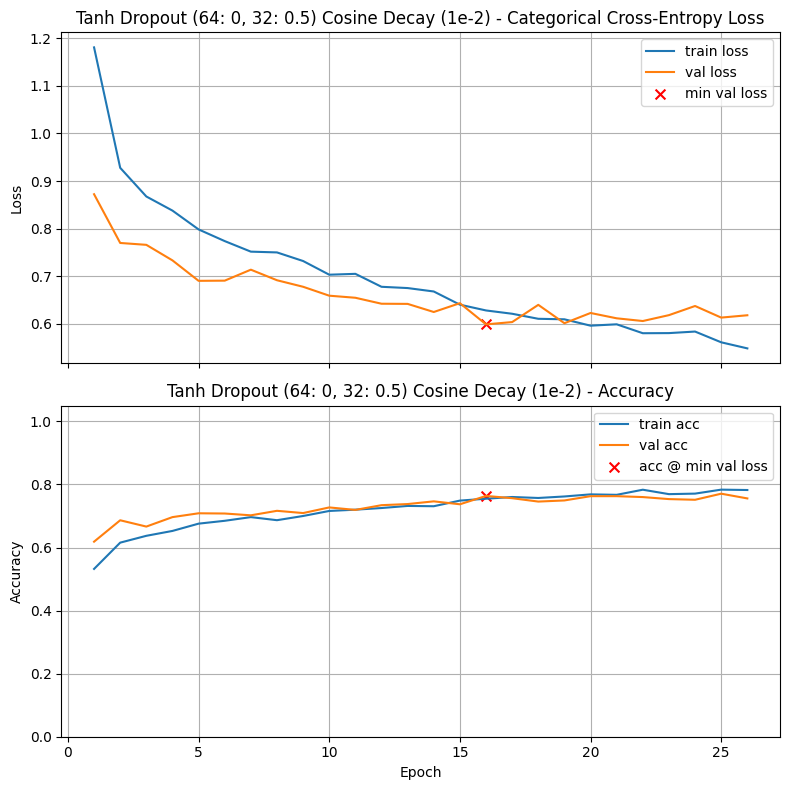

Final Training Loss:            0.5488
Final Training Accuracy:        0.7824
Final Validation Loss:          0.6184
Final Validation Accuracy:      0.7557
Minimum Validation Loss:        0.5992 (Epoch 16)
Validation Accuracy @ Min Loss: 0.7636

Test Loss: 0.6290
Test Accuracy: 0.7464

Validation-Test Gap (accuracy): 0.017143

Execution Time: 00:00:04


In [36]:
batch_size = 64
steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
total_steps = 500 * steps_per_epoch

cosine_decay = CosineDecay(
    initial_learning_rate=1e-2,
    decay_steps=total_steps,
    alpha=0.0
)

train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 0, 0), (32, 'tanh', 0, 0.5)], n_classes),
               epochs=500,
               lr_schedule=cosine_decay,
               optimizer='Adam',
               batch_size=64,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title='Tanh Dropout (64: 0, 32: 0.5) Cosine Decay (1e-2)')


Tanh LR = 1e-3 Dropout (128: 0, 64: 0.1, 32: 0.5)



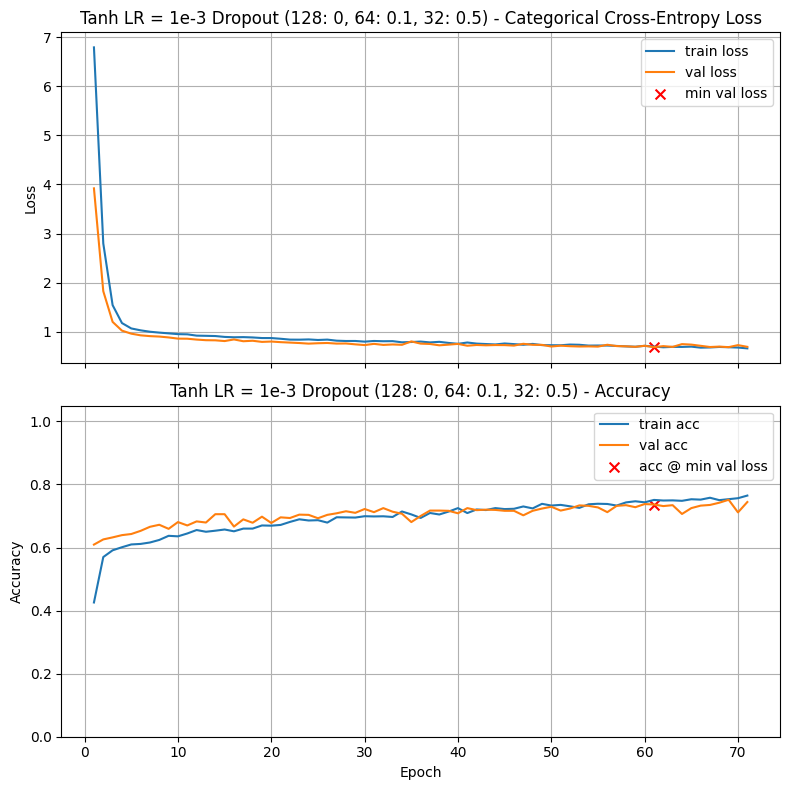

Final Training Loss:            0.6584
Final Training Accuracy:        0.7648
Final Validation Loss:          0.6897
Final Validation Accuracy:      0.7443
Minimum Validation Loss:        0.6830 (Epoch 61)
Validation Accuracy @ Min Loss: 0.7364

Test Loss: 0.7283
Test Accuracy: 0.7143

Validation-Test Gap (accuracy): 0.022143

Execution Time: 00:00:14


In [37]:
train_and_test(model=build_model(X_train.shape[1], [ (128, 'tanh', 0, 0), (64, 'tanh', 0.1, 0), (32, 'tanh', 0, 0.5)], n_classes),
               epochs=500,
               lr_schedule=1e-3,
               optimizer='Adam',
               batch_size=64,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title='Tanh LR = 1e-3 Dropout (128: 0, 64: 0.1, 32: 0.5)')


Tanh LR = 1e-3 Dropout (128: 0, 64: 0.3, 32: 0.5)



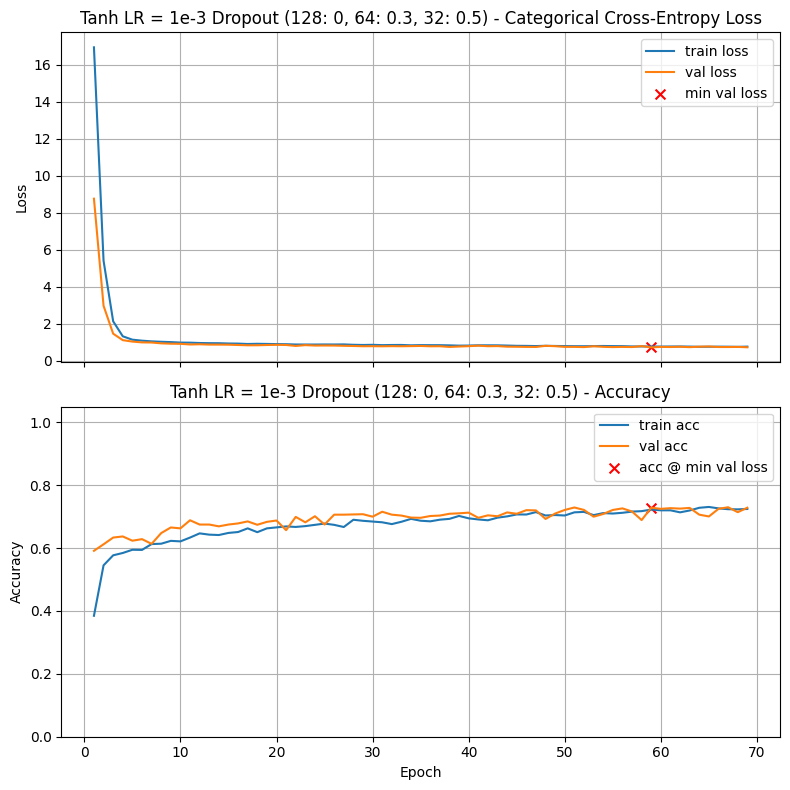

Final Training Loss:            0.7535
Final Training Accuracy:        0.7245
Final Validation Loss:          0.7182
Final Validation Accuracy:      0.7286
Minimum Validation Loss:        0.7123 (Epoch 59)
Validation Accuracy @ Min Loss: 0.7286

Test Loss: 0.7359
Test Accuracy: 0.7264

Validation-Test Gap (accuracy): 0.002143

Execution Time: 00:00:11


In [38]:
train_and_test(model=build_model(X_train.shape[1], [ (128, 'tanh', 0, 0), (64, 'tanh', 0.3, 0), (32, 'tanh', 0, 0.5)], n_classes),
               epochs=500,
               lr_schedule=1e-3,
               optimizer='Adam',
               batch_size=64,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title='Tanh LR = 1e-3 Dropout (128: 0, 64: 0.3, 32: 0.5)')


Tanh LR = 1e-3 Dropout (128: 0, 64: 0, 32: 0.5)



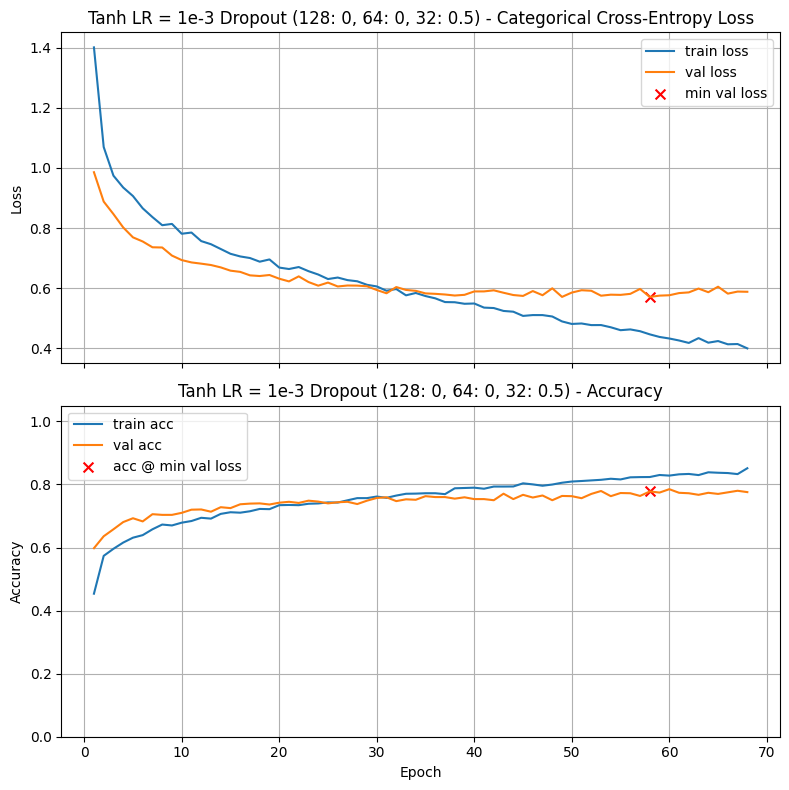

Final Training Loss:            0.4000
Final Training Accuracy:        0.8514
Final Validation Loss:          0.5882
Final Validation Accuracy:      0.7757
Minimum Validation Loss:        0.5710 (Epoch 58)
Validation Accuracy @ Min Loss: 0.7779

Test Loss: 0.5942
Test Accuracy: 0.7671

Validation-Test Gap (accuracy): 0.010714

Execution Time: 00:00:10


In [39]:
train_and_test(model=build_model(X_train.shape[1], [ (128, 'tanh', 0, 0), (64, 'tanh', 0, 0), (32, 'tanh', 0, 0.5)], n_classes),
               epochs=500,
               lr_schedule=1e-3,
               optimizer='Adam',
               batch_size=64,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title='Tanh LR = 1e-3 Dropout (128: 0, 64: 0, 32: 0.5)')


Tanh LR = 1e-3 Dropout (64: 0, 32: 0.5) Batch = 128



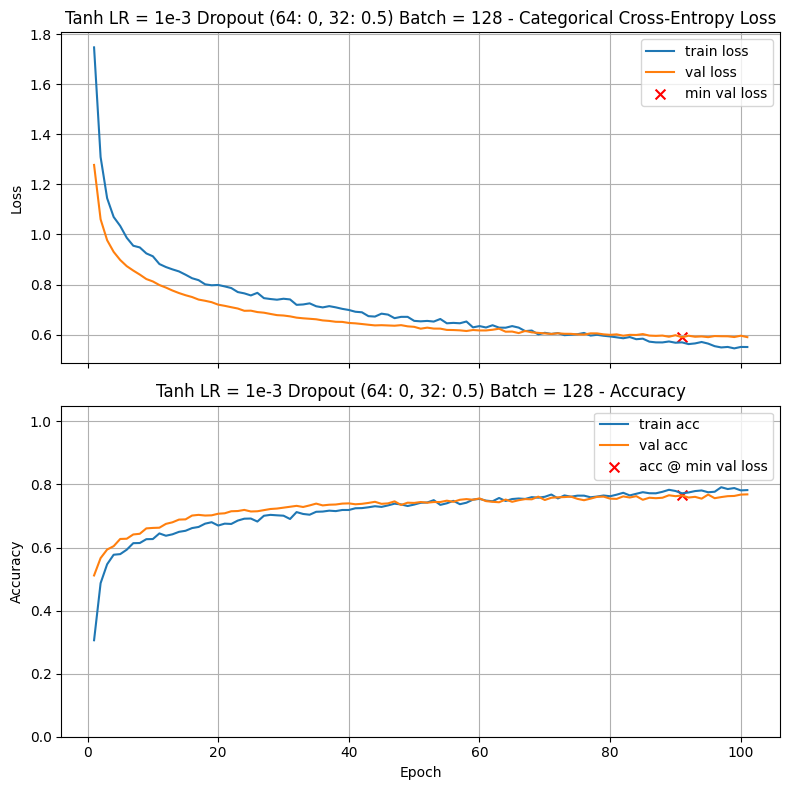

Final Training Loss:            0.5504
Final Training Accuracy:        0.7821
Final Validation Loss:          0.5898
Final Validation Accuracy:      0.7686
Minimum Validation Loss:        0.5895 (Epoch 91)
Validation Accuracy @ Min Loss: 0.7650

Test Loss: 0.6255
Test Accuracy: 0.7450

Validation-Test Gap (accuracy): 0.020000

Execution Time: 00:00:08


In [40]:
train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 0, 0), (32, 'tanh', 0, 0.5)], n_classes),
               epochs=500,
               lr_schedule=1e-3,
               optimizer='Adam',
               batch_size=128,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title='Tanh LR = 1e-3 Dropout (64: 0, 32: 0.5) Batch = 128')


Tanh LR = 1e-3 Dropout (64: 0, 32: 0.5) Batch = 32



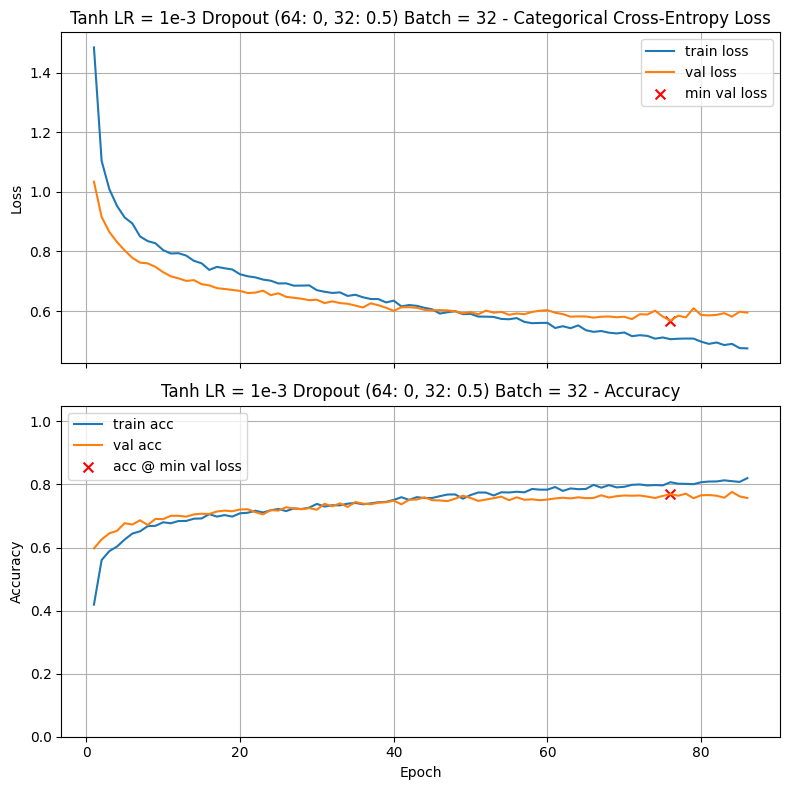

Final Training Loss:            0.4744
Final Training Accuracy:        0.8200
Final Validation Loss:          0.5945
Final Validation Accuracy:      0.7571
Minimum Validation Loss:        0.5675 (Epoch 76)
Validation Accuracy @ Min Loss: 0.7693

Test Loss: 0.5872
Test Accuracy: 0.7650

Validation-Test Gap (accuracy): 0.004286

Execution Time: 00:00:18


In [41]:
train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 0, 0), (32, 'tanh', 0, 0.5)], n_classes),
               epochs=500,
               lr_schedule=1e-3,
               optimizer='Adam',
               batch_size=32,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title='Tanh LR = 1e-3 Dropout (64: 0, 32: 0.5) Batch = 32')


Tanh LR = 1e-3 Dropout (64: 0, 32: 0.5) Batch = 256



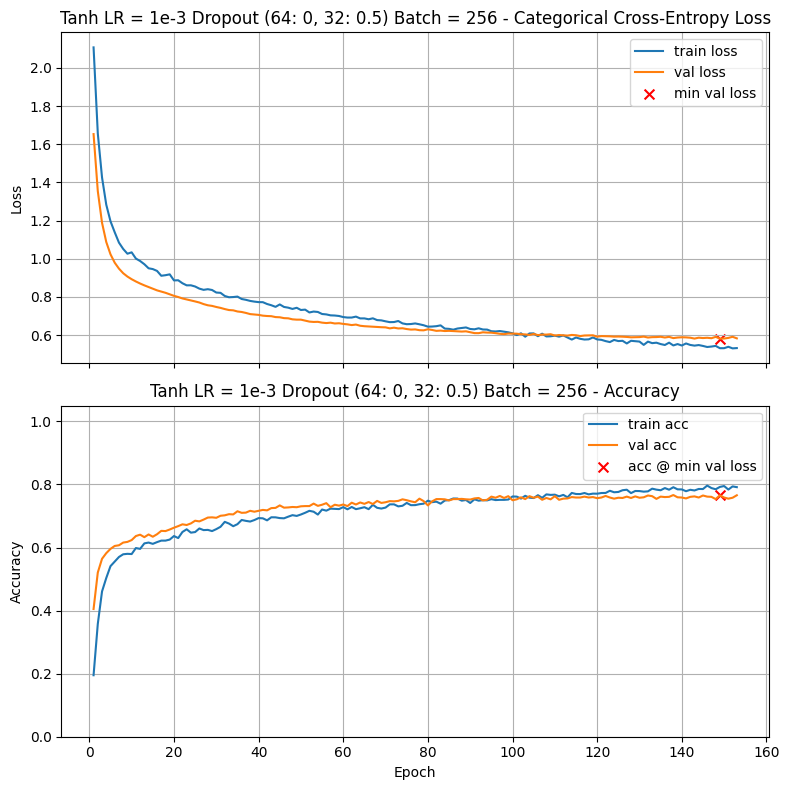

Final Training Loss:            0.5315
Final Training Accuracy:        0.7914
Final Validation Loss:          0.5824
Final Validation Accuracy:      0.7657
Minimum Validation Loss:        0.5812 (Epoch 149)
Validation Accuracy @ Min Loss: 0.7657

Test Loss: 0.6099
Test Accuracy: 0.7400

Validation-Test Gap (accuracy): 0.022143

Execution Time: 00:00:10


In [42]:
train_and_test(model=build_model(X_train.shape[1], [ (64, 'tanh', 0, 0), (32, 'tanh', 0, 0.5)], n_classes),
               epochs=500,
               lr_schedule=1e-3,
               optimizer='Adam',
               batch_size=256,
               use_early_stopping=True,
               patience=10,
               min_delta=0.0001,
               title='Tanh LR = 1e-3 Dropout (64: 0, 32: 0.5) Batch = 256')

In [78]:
# Set a6 to the validation accuracy found by this best model

a6 = results['Tanh Dropout (72: 0.1, 64: 0.1, 32: 0.5) Exp. Decay (0.001, decay=0.99) Batch = 72'][0]             # Replace 0.0 with your answer

In [79]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a6 = {a6:.4f}') 

a6 = 0.8100


### Optional: Print out your results of all experiments

In [77]:
print_results()

Tanh Dropout (72: 0.1, 64: 0.1, 32: 0.5) Exp. Decay (0.001, decay=0.99) Batch = 72	0.8100
Tanh Dropout (128: 0, 72: 0, 64: 0, 32: 0.5) Exp. Decay (0.001, decay=0.99) Batch = 72	0.7957
Tanh Dropout (72: 0.1, 64: 0.1, 32: 0.5) Exp. Decay (0.001, decay=0.99) Batch = 64	0.7907
Tanh LR = 1e-3 L2 = 1e-4                	0.7879
Tanh Baseline                           	0.7857
Tanh LR = 1e-3 L2 = 1e-3                	0.7857
Tanh Dropout (64: 0, 32: 0.5) Exp. Decay (0.001, decay=0.999) Batch = 32	0.7821
Tanh Dropout (72: 0.1, 64: 0.1, 32: 0.4) Exp. Decay (0.001, decay=0.99) Batch = 72	0.7821
Tanh Dropout (72: 0, 64: 0, 32: 0.5) Exp. Decay (0.001, decay=0.99) Batch = 72	0.7800
Tanh Dropout (72: 0.1, 64: 0, 32: 0.5) Exp. Decay (0.001, decay=0.99) Batch = 72	0.7793
Tanh Dropout (72: 0, 64: 0.1, 32: 0.5) Exp. Decay (0.001, decay=0.99) Batch = 64	0.7793
Tanh LR = 1e-3 Dropout (128: 0, 64: 0, 32: 0.5)	0.7779
Tanh Dropout (128: 0, 64: 0, 32: 0.5) Exp. Decay (0.001, decay=0.99) Batch = 72	0.7779
Tanh LR 

## Reflection Questions (ungraded)

It would be a great idea to think through your answers to these questions, then give ChatGPT (or other AI tool) a PDF of your
homework, and **discuss** (not just ask) these. 

1. Activation Functions:

    - Why do you think one activation function worked better than the others for this task?
    
    - How might this choice differ for deeper or wider networks?

2. Learning Rate:

    - Would a much smaller learning rate (with many more epochs) likely produce better accuracy?
    
    - When is it worth training longer with a smaller step size, and when is it unnecessary?

3. Dropout vs. L2:

    - Which form of regularization — dropout or L2 — gave better results in your experiments?
    
    - Why might one method be more effective in this setting?

4. Combining Dropout and L2:

    - Why might the combination of dropout and L2 sometimes perform worse than using one method alone?
    
    - What does this tell you about the balance between bias and variance in regularization?

5. Best Model:

    - When you designed your best model, what trade-offs did you notice between model complexity, training stability, and generalization?
    
    - Did learning rate scheduling (if you tried it) improve results? Why might it help?